# Optiver Data Test - James Cuin

**NOTE: Thank you for such a fun task - I hope the below serves as a platform for an interesting discussion!**

In the following `.ipynb` Notebook, we develop a model, derived from a training dataset provided, that selects a subset of trades to do on a test dataset provided, such that we aim to maximise the total profit of the selected trades. In the interest of clarity, we outline some initial assumptions and decisions based on the project description and `FAQs.pdf` provided.

#### Initial Assumptions
- First, we assume each row to correspond to a potential trade, where the response for the given row is the observed profit, at some unknown time in the future given that we trade. To be clear, we treat the problem in a binary manner, in that we assume the "correct" trade side is always selected.

- We assume that the decision as to whether or not to trade needs to be made at the time of recieving a row, and that rows are recieved in a sequuential manner. To be clear, this means that we do not explore strategies that, say, selects the top $m\%$ of scores from a batch to trade on.

    - Also note that due to the two previous assumptions, it is not valid to compute lagged values of our target, in any capacity, since we do not know at what temporal index $y_{t-k}$ would be observable, for example (as the unknown time in the future could be in the future compared to the temporal index $t$).

- Samples are ordered chronologically, yet sampled with an irregular time delta (similar to updates in many Limit Order Books).

- Features and target are aligned, in that we can trade based on the current features to then obtain the target profit.

- Features mean the same thing throughout the dataset.

#### Approach

Regarding the approach we take, a Table of Contents is provided below.

## Table of Contents
- [Setup](#setup)
- [Imports](#imports)
- [Data Loading](#data-loading)
- [EDA](#data-quality-checks)
- [Feature Important & Selection](#feature-importance-&-selection)
- [Feature Engineering](#feature-engineering)
- [Model Development](#model-development)
- [Model Training Pipeline](#model-training-pipeline)
- [Model Evaluation Pipeline](#model-evaluation-pipeline)
- [Model Training & Evaluation Experiments](#model-training-&-evaluation-experiments)
- [PyTorch Framework](#pytorch-framework)
- [Holdout Test Set Evaluation](#holdout-test-set-evaluation)
- [Assumptions & Limitations](#assumptions-&-limitations)
- [Findings](#findings)
- [Future Work](#future-work)
- [Appendix](#appendix)


# Setup

To begin, we download the data, as outlined in the Hackerrank environment.

#### Notes:
- `wget` needs to be installed, which can be achieved via Homebrew using `brew install wget`.

In [1]:
from IPython import get_ipython

get_ipython().getoutput("wget -O 'Project_train.csv' 'https://hr-projects-assets-prod.s3.amazonaws.com/bkj9j39cpbb/fcf0ec1f3785668db3f2122ed605ebc0/Project_train.csv'")
get_ipython().getoutput("wget -O 'Project_test.csv' 'https://hr-projects-assets-prod.s3.amazonaws.com/bkj9j39cpbb/359662815ce4d41539803bd3dbc34ee3/Project_test.csv'")


['--2025-10-08 14:18:50--  https://hr-projects-assets-prod.s3.amazonaws.com/bkj9j39cpbb/359662815ce4d41539803bd3dbc34ee3/Project_test.csv',
 'Resolving hr-projects-assets-prod.s3.amazonaws.com (hr-projects-assets-prod.s3.amazonaws.com)... 3.5.16.146, 52.217.236.249, 3.5.27.156, ...',
 'Connecting to hr-projects-assets-prod.s3.amazonaws.com (hr-projects-assets-prod.s3.amazonaws.com)|3.5.16.146|:443... connected.',
 'HTTP request sent, awaiting response... 200 OK',
 'Length: 15910859 (15M) [binary/octet-stream]',
 'Saving to: ‘Project_test.csv’',
 '',
 '     0K .......... .......... .......... .......... ..........  0%  602K 26s',
 '    50K .......... .......... .......... .......... ..........  0%  584K 26s',
 '   100K .......... .......... .......... .......... ..........  0%  111M 17s',
 '   150K .......... .......... .......... .......... ..........  1%  603K 19s',
 '   200K .......... .......... .......... .......... ..........  1% 16.8M 16s',
 '   250K .......... .......... .......

# Imports

Please run `pip install -r requirements.txt` before executing the below.

In [2]:
import numpy as np
import pandas as pd

import math

from statsmodels.tsa.stattools import adfuller
from scipy.stats import shapiro

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.base import clone

import xgboost as xgb
import lightgbm as lgb
import catboost as cb

import warnings

from functools import partial

from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

import logging
import joblib

# Data Loading

Indeed, we have $\mathcal{D}_{train,val}$ and $\mathcal{D}_{test}$ saved in the files `Project_train.csv` and `Project_test.csv` respectively.

Recall, we expect to have a collection of features, where some contain historical information, some are a current snapshot, and some aren't time series themselves (e.g. a size to trade against). To be clear, we have not been explicitly told what each feature means. The target, on the other hand is the is the observed profit, at some unknown time in the future given that we trade.

Any initial EDA should be non-informative for model-specific decisions, otherwise we incorporate a form of data leakage. To this end, we focus on $\mathcal{D}_{train,val}$ for now, and load $\mathcal{D}_{test}$ later!

In [3]:
# Load \mathcal{D}_{train,val}
df_train_val = pd.read_csv('Project_train.csv', index_col=0)  # As .csv reads ,0,1,2,..,65,TARGET we utilise `index_col=0`

display(df_train_val)

,0,1,2,3,4,5,6,7,8,9,...,57,58,59,60,61,62,63,64,65,TARGET
0,5874.524387,1072.671848,41440.76212,41440.23732,70.405148,7.392780,70.377281,23229.69262,23229.72655,70.378864,...,23936.99077,21670.192330,71.518948,11.399004,78.006816,26437.161240,23811.09670,141.997532,22.474794,0.013314
1,6124.154099,1072.802927,41440.76212,41442.22458,70.456758,7.356050,70.379576,23229.76020,23230.10472,70.273618,...,22053.23653,14626.733390,48.124991,-99.618253,-115.120518,7705.543821,22665.35143,-377.287072,-73.700375,-0.000448
2,5905.732593,1072.802927,41443.14358,41442.30403,70.422472,7.417794,70.376448,23229.48142,23229.61008,70.474265,...,23430.24573,31251.552920,71.535567,53.482719,106.179152,37586.677270,23251.62576,261.098973,22.565621,0.000244
3,6029.325221,1072.802927,41440.76212,41442.25682,70.458533,7.366031,70.379221,23230.08433,23229.87971,70.288944,...,23193.67720,15867.015790,70.369496,-12.169114,63.930236,10052.351290,23229.64352,-10.549985,4.656636,-0.000628
4,6142.360146,1072.802927,41443.14358,41442.46480,70.413623,7.411287,70.376788,23229.70975,23229.82255,70.467206,...,23235.86490,31790.064250,120.694068,42.971377,145.572170,37109.895810,24143.94971,188.639704,31.863254,0.003811
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89995,13562.064960,1061.530132,41235.95694,41236.96634,70.431821,7.414020,70.378048,23229.76548,23229.77954,70.373676,...,23229.78574,39758.670430,83.705397,49.839589,142.047009,46105.233810,23471.93603,201.796950,30.612585,0.001185
89996,12711.732070,1061.530132,41238.33840,41236.82293,70.459676,7.363988,70.376757,23229.77584,23229.79672,70.371404,...,23229.76853,6954.309894,54.541862,-27.220096,15.887586,1140.962941,22942.09020,-36.604255,-10.266799,-0.000382
89997,11857.854050,1061.530132,41235.95694,41236.73441,70.419055,7.413537,70.377374,23229.81430,23229.80621,70.385575,...,23229.77154,38616.193510,67.017408,24.129616,78.160954,43959.347940,23168.74708,122.113939,9.911516,-0.000313
89998,11803.230780,1061.530132,41238.33840,41236.77811,70.462143,7.367474,70.376032,23229.79226,23229.77640,70.369925,...,23229.77098,8902.378045,70.193250,-1.683851,65.910681,3996.930482,23226.44608,42.344493,5.942085,0.001793


# EDA $(\text{on }  \mathcal{D}_{train, val})$

We carry out our EDA on $\mathcal{D}_{train,val}$ below. 

To begin, we investigate any potential data quality issues, and then move on to exploring the dataset. Specifically, we focus on understand the distribution of the target, potential regime shifts, as well as characteristics of the predictors.

In [4]:
# Global variables to quickly access X & y
TARGET_COL = 'TARGET'
FEATURE_COLS = df_train_val.columns.drop(TARGET_COL)

## Data Quality Checks

In [5]:
# Check shape is as expected (i.e. 90,000 X 67) (T, 66+1)
print(f"{df_train_val.shape=}")

# Verify no missing values, for any feature
print(f"\nMissing Values Exist: {(df_train_val.isnull().sum() > 0).any()}")

# Check for duplicate rows
print(f"\nDuplicate Row Count: {df_train_val.duplicated().sum()}")

# Check data types of all columns
print(f"\nData Type Count: {df_train_val.dtypes.value_counts().to_string()}")

df_train_val.shape=(90000, 67)

Missing Values Exist: False

Duplicate Row Count: 0

Data Type Count: float64    67


**Learnings:**
- We have 66 predictors and 90,000 samples in $\mathcal{D}_{train,val}$.
- No missing values, meaning there is no need for data imputations, extrapolation or removal at this stage.
- No duplication of rows has occured.
- All predictors are float64 type, meaning there is no need to perform data encoding. 

## Initial EDA

In [6]:
pd.set_option('display.max_rows', 10) # Set 10 -> None to see all columns

print("\nDescriptive Statistics of \mathcal{D}_{train,val}:")
display(df_train_val.describe().T)

print(f"\nNumber of Unique Values per Column:\n {df_train_val.nunique()}")


Descriptive Statistics of \mathcal{D}_{train,val}:


,count,mean,std,min,25%,50%,75%,max
0,90000.0,13365.474816,4877.338110,1360.676509,9863.794843,12623.982775,15934.225878,118430.888400
1,90000.0,1071.217275,6.590974,1055.893735,1065.855739,1072.278611,1076.997455,1083.289247
2,90000.0,41413.144569,119.751346,41133.554350,41314.544980,41431.236300,41519.350160,41631.278570
3,90000.0,41413.140081,119.750603,41135.249380,41315.368445,41432.297400,41518.194795,41632.688790
4,90000.0,70.441719,0.026711,70.376360,70.421158,70.441679,70.462306,70.507341
...,...,...,...,...,...,...,...,...
62,90000.0,23264.552056,55733.137929,-784846.949600,-3231.274488,23185.725210,49820.993022,782554.338600
63,90000.0,23219.576197,5429.353037,-179886.020000,22535.747703,23229.687545,23924.867363,135436.826300
64,90000.0,71.549145,807.900381,-18469.018900,-179.316365,70.828300,325.392806,17814.491820
65,90000.0,7.525900,177.209302,-5282.912546,-34.347827,7.358205,49.962365,2823.471082



Number of Unique Values per Column:
 0         89998
1           213
2           210
3         89849
4         88777
          ...  
62        90000
63        89981
64        90000
65        90000
TARGET    86462
Length: 67, dtype: int64


*Note: We have checked that no column is constant in value.*

The number of unique values per column is particularly insightful when combined with our subsequent plots. For continuous data, we would expect, in the general case, a number of unique values close to that of `len(df_train_df)`, unless precision was a limiting factor. For example, the minimum resolution of bid and ask prices are fixed, and consequently we would expect such features to take on repeat values. Similarly, features that encapsulate relative changes, such as the $\frac{\text{mid price}_{t+k} - \text{mid price}_{t}}{\text{Tick Resolution}}$, take on distinct values that mean we expect a significantly reduced number of distinct values.

Even in the above (truncated summary statistics), one can observe cases where features posses very similar statistics between columns, most notably in the case of Feature 2 and 3. In light of the above (brief) discussion, we deem this to warrant further exploration.

Also, due to multiple columns having exactly $90,000$ unique values, we are also skeptical of these features having been derived, and then augmented in some manner, such as with random noise.

In any case, due to the absence of explicit information pertaining to this, we remain skeptical of the data, and place less emphasis on interpretability.

### Analysing the Target

To begin, we analyse the target (`'TARGET'`) distribution, since this ultimately drives model-specific decisions. 

In particular, we visualise the `'TARGET'` timeseries, histogram, and Q-Q Plot.

Negative Values Proportion: 0.4993444444444444
Zero Values Proportion: 2.2222222222222223e-05
Positive Values Proportion: 0.5006333333333334


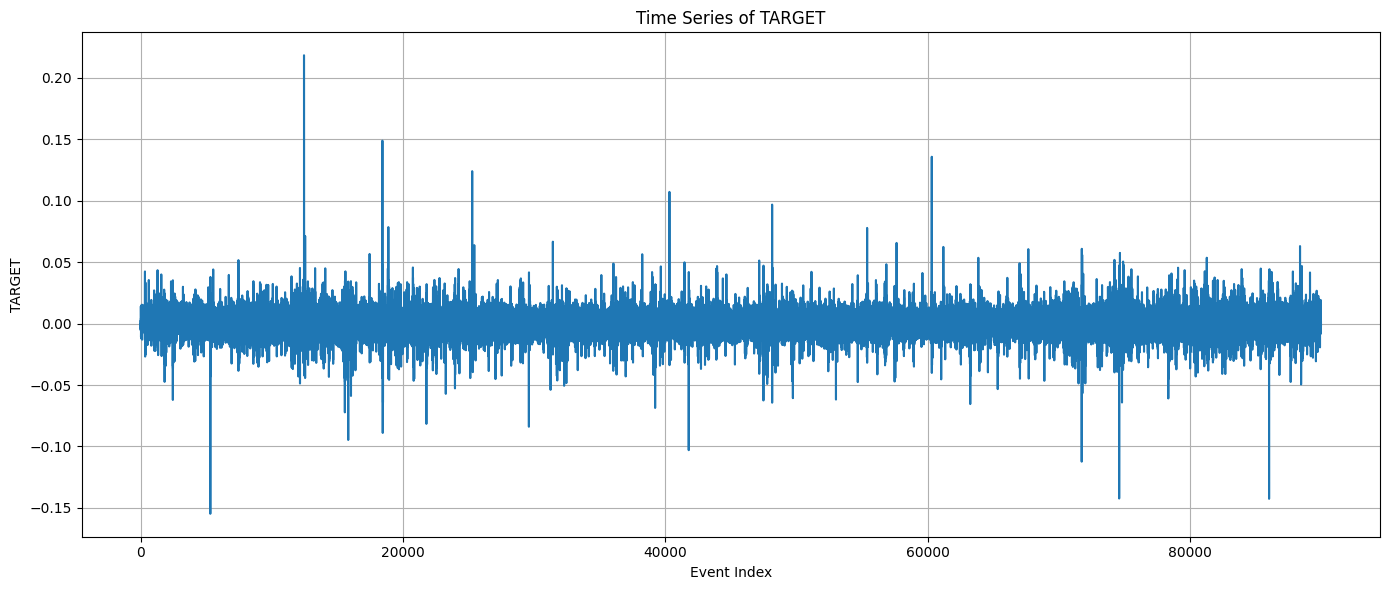

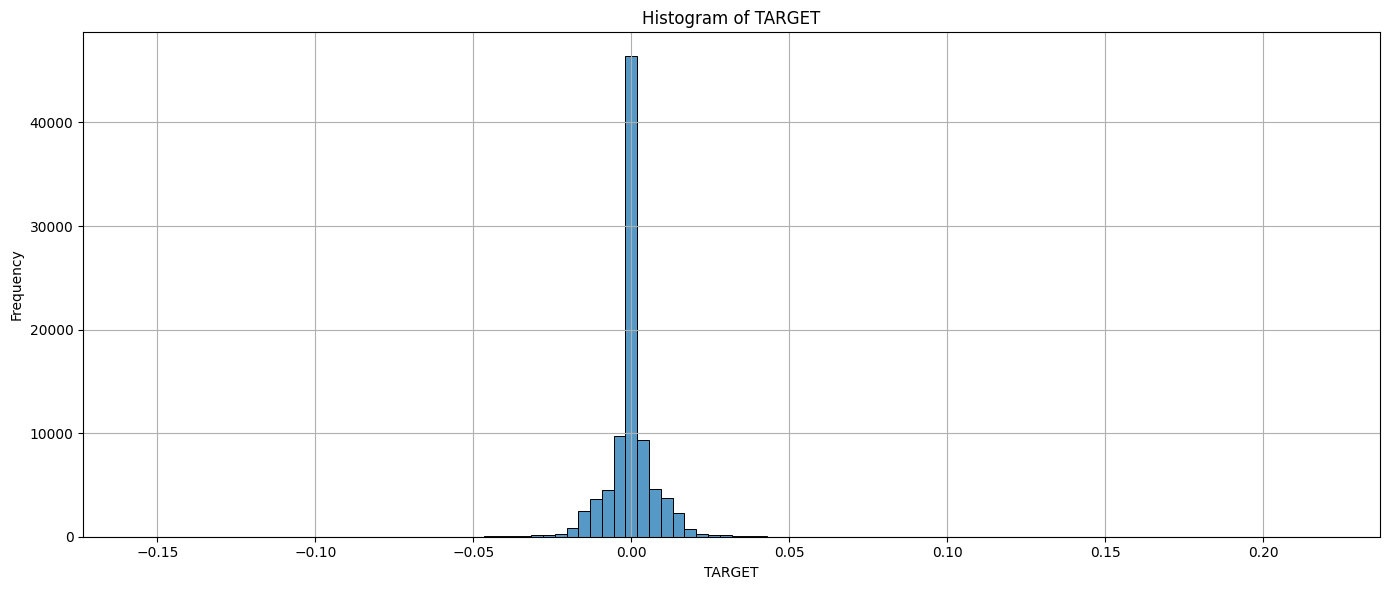

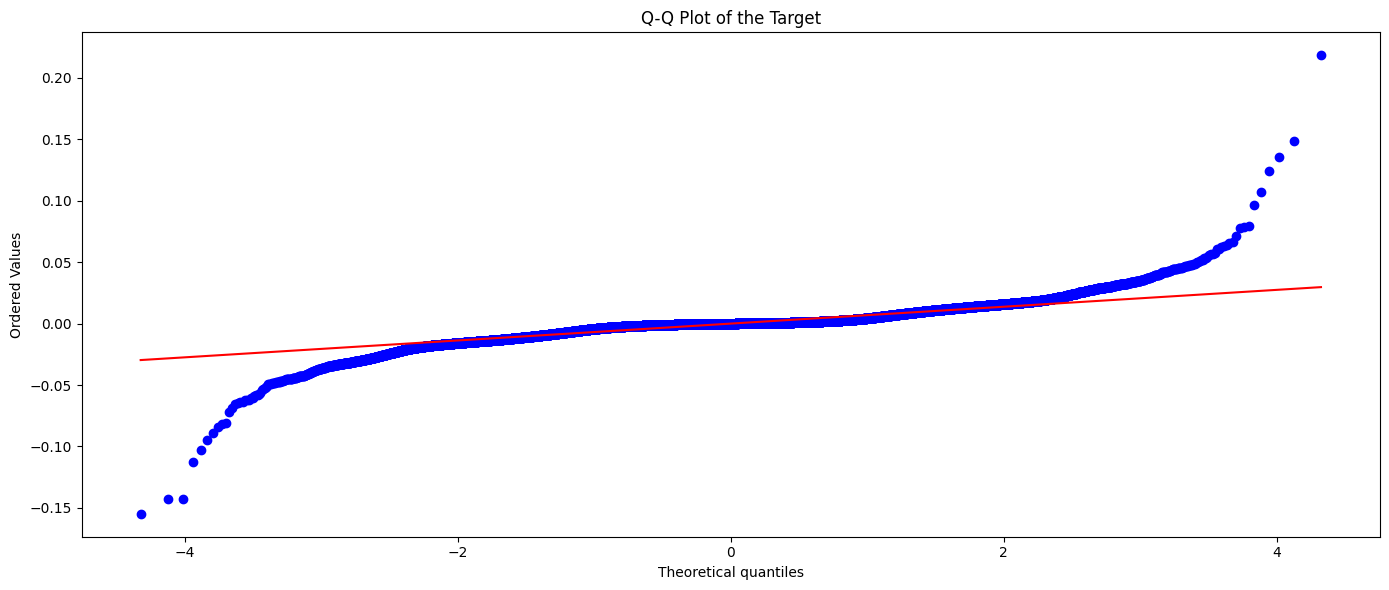

In [7]:
### High Level Stats of TARGET ###

print("Negative Values Proportion:", (df_train_val[TARGET_COL] < 0).sum() / len(df_train_val))
print("Zero Values Proportion:", (df_train_val[TARGET_COL] == 0).sum() / len(df_train_val))
print("Positive Values Proportion:", (df_train_val[TARGET_COL] > 0).sum() / len(df_train_val))


### Time Series of TARGET ###

plt.figure(figsize=(14, 6))

plt.plot(df_train_val[TARGET_COL])

plt.title('Time Series of TARGET')
plt.xlabel('Event Index')
plt.ylabel('TARGET')
plt.grid(True)
plt.tight_layout()
plt.show()


### Histogram of TARGET ###

plt.figure(figsize=(14, 6))

sns.histplot(df_train_val[TARGET_COL], bins=100)

plt.title('Histogram of TARGET')
plt.xlabel('TARGET')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()


### Q-Q Plot of TARGET ###

plt.figure(figsize=(14, 6))

stats.probplot(df_train_val[TARGET_COL].dropna(), plot=plt)

plt.title('Q-Q Plot of the Target')
plt.tight_layout()
plt.show()

**Learnings:**
- The target is an approximately symmetric, zero-centered distribution of leptokurtic shape, that is one with heavy tails and a sharp peak. Indeed, as verified below via the Shapiro-Wilk test, the target is not normally distributed.
- From the time-series plot, the series appears stationary in mean and variance. The former of these is verified using the ADF test below.
- The Q-Q Plot visually confirms the target is not normally distributed and posseses heavy tails.

In [8]:
### ADF Test ###

adf_stat, adf_p_val, _, _, adf_critical_values, _ = adfuller(df_train_val['TARGET'])
print(f"ADF Statistic: {adf_stat}")
print(f"p-value: {adf_p_val}")
print(f"Critical Values: {adf_critical_values}")

if adf_p_val < 0.05:
    print("Reject H0: Series is stationary!")
else:
    print("Fail to reject H0: Series is non-stationary!")


### Shapiro-Wilk Test ###

stat, p = shapiro(df_train_val['TARGET'].sample(5000))
print(f"\nShapiro–Wilk Statistic: {stat}")
print(f"p-value: {p}")

if p < 0.05:
    print("Reject H0: Data is NOT normally distributed!")
else:
    print("Fail to reject H0: Data is normally distributed!")

ADF Statistic: -53.73839267018629
p-value: 0.0
Critical Values: {'1%': -3.4304226843825347, '5%': -2.861572125318876, '10%': -2.566787099189974}
Reject H0: Series is stationary!

Shapiro–Wilk Statistic: 0.8654294013977051
p-value: 0.0
Reject H0: Data is NOT normally distributed!


Next, we are interested in any potential regime shifts w.r.t our target. To this end, we visualise the cumulative sum of the `'TARGET'` over time, as well as rolling statistics in a later plot.

If there were significant regime shifts, we would have clear motivation to utilise a continual model refitting approach. 

In fact, we could also explore flipping input and target values, in a manner such that our dataset size is doubled, and the model is agnostic to "bullish" and "bearish" regimes. We omit this exploration due to the fact that such an approach is predicated on explicit understanding of the input features (and their nuances).

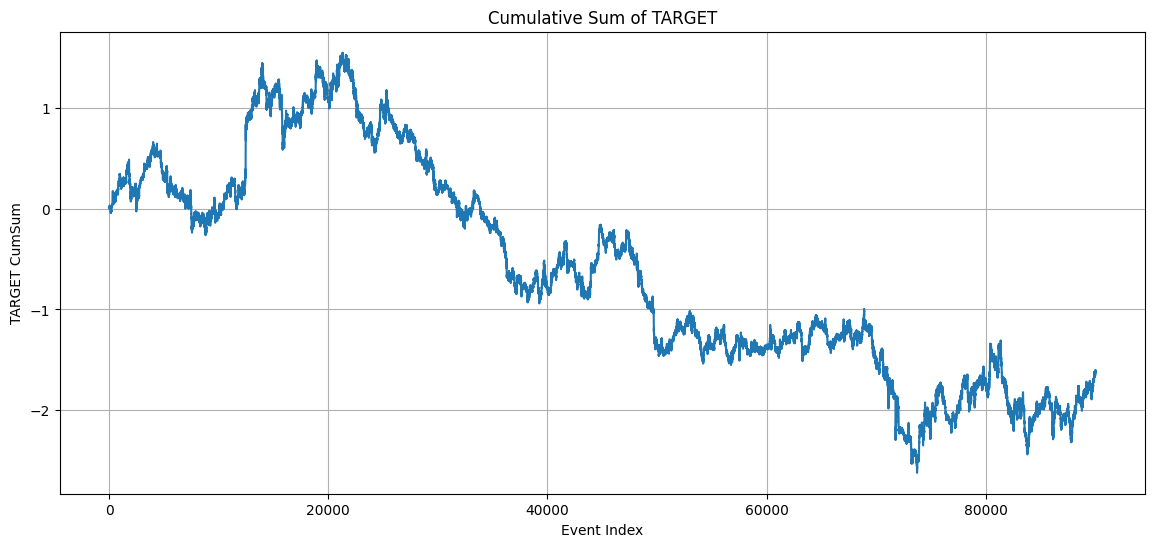

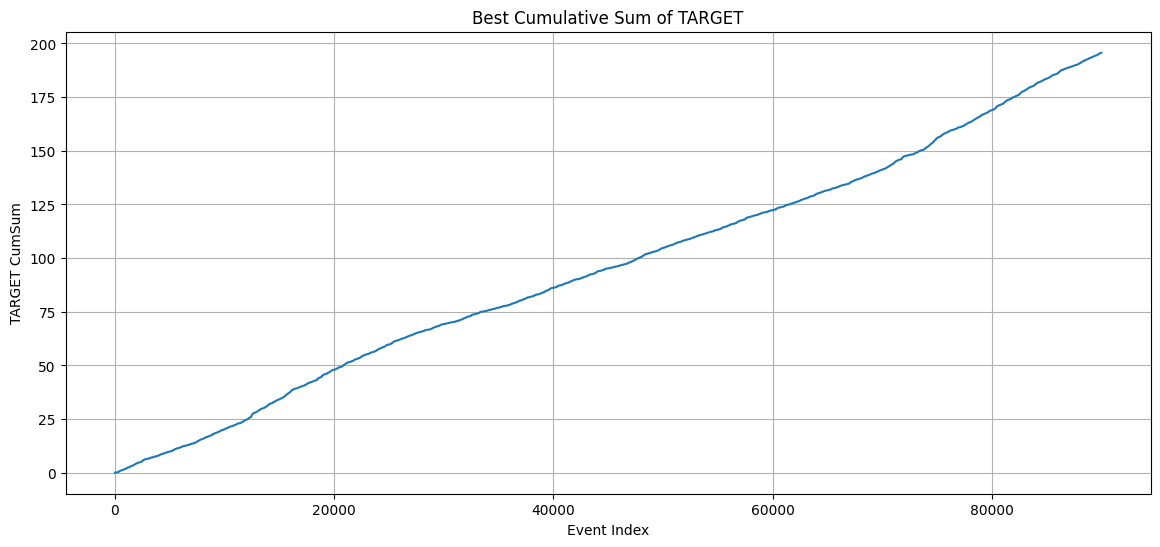

In [9]:
### Cumulative Sum of TARGET ###

target_cumsum = df_train_val[TARGET_COL].cumsum()

plt.figure(figsize=(14, 6))

plt.plot(target_cumsum)

plt.title('Cumulative Sum of TARGET')
plt.xlabel('Event Index')
plt.ylabel('TARGET CumSum')
plt.grid(True)
plt.show()

### Best Possible Cumulative Sum (i.e. Select all +ve TARGET values) ###

best_possible_target_cumsum = df_train_val[TARGET_COL].where(df_train_val[TARGET_COL] > 0, 0).cumsum()

plt.figure(figsize=(14, 6))

plt.plot(best_possible_target_cumsum)

plt.title('Best Cumulative Sum of TARGET')
plt.xlabel('Event Index')
plt.ylabel('TARGET CumSum')
plt.grid(True)
plt.show()

**Learnings:**
- The naive strategy of trading every event results in -ve PnL.
- A small number of trades are not responsible for a significant amount of the profits (since the latter plot is ~ a straight line). This is corroborated by the target historgram!
- The upper bound of any model on $\mathcal{D}_{train,val}$ is 195.69 (2 s.f.).

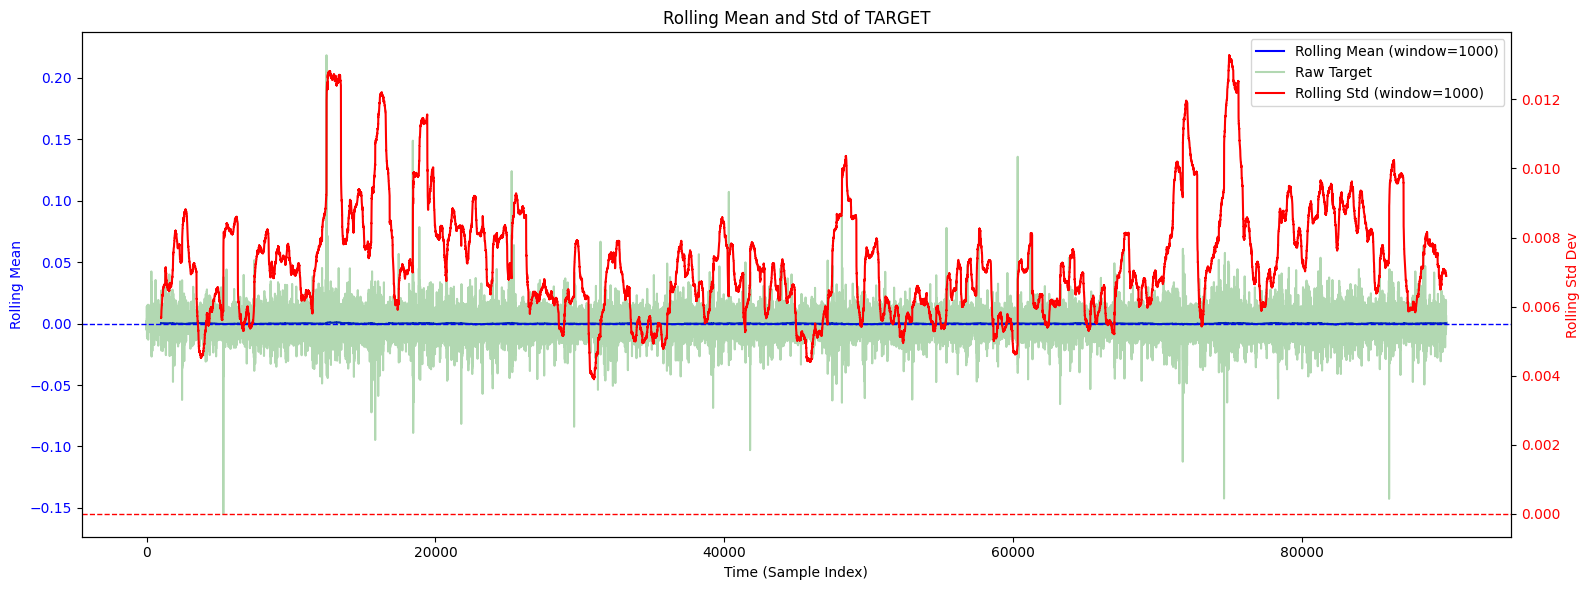

In [10]:
window_size = 1000

rolling_stats = df_train_val[['TARGET']].rolling(window=window_size)

rolling_mean = rolling_stats.mean()
rolling_std = rolling_stats.std()

fig, ax1 = plt.subplots(figsize=(16, 6))

ax1.plot(rolling_mean, color='blue', label=f'Rolling Mean (window={window_size})')
ax1.plot(df_train_val['TARGET'], color='green', alpha=0.3, label='Raw Target')

ax1.set_xlabel('Time (Sample Index)')
ax1.set_ylabel('Rolling Mean', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create a second y-axis for rolling std
ax2 = ax1.twinx()

ax2.plot(rolling_std, color='red', label=f'Rolling Std (window={window_size})')

ax2.set_ylabel('Rolling Std Dev', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Baselines
ax1.axhline(0, color='blue', linestyle='--', linewidth=1)
ax2.axhline(0, color='red', linestyle='--', linewidth=1)

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='best')

plt.title('Rolling Mean and Std of TARGET')

fig.tight_layout()
plt.show()

**Learnings:**
- The target appears to be stationary with mean zero.
- The target appears to exhibit volatility clustering. In this sense, there are different regimes to be aware of.

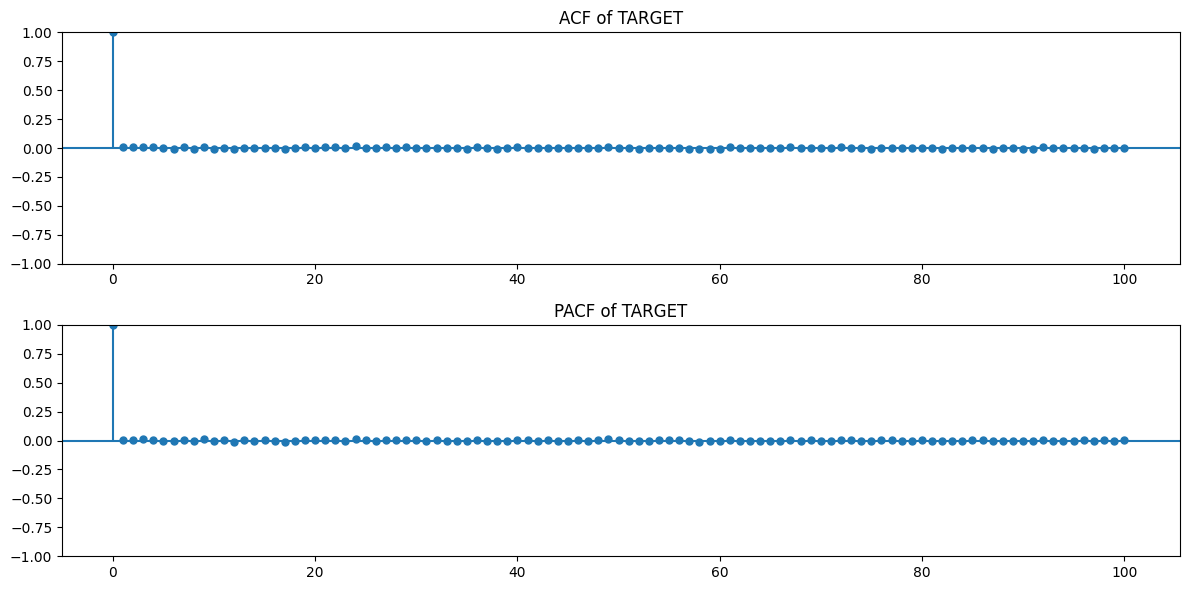

In [11]:
plt.figure(figsize=(12, 6))

ax1 = plt.subplot(211)
plot_acf(df_train_val[TARGET_COL], lags=100, ax=ax1, alpha=0.05, title='ACF of TARGET')
plt.tight_layout()

ax2 = plt.subplot(212)
plot_pacf(df_train_val[TARGET_COL], lags=100, ax=ax2, alpha=0.05, title='PACF of TARGET')

plt.tight_layout()
plt.show()

**Learnings:**
-  Target values appear uncorrelated with each other (as expected), and so we cannot leverage any autoregressive properties.

#### Things to Consider

**Q: Do we want to clip target?**
-  This is nuanced and depends on downstream application. Question of potential reduction of overfitting with introduction of bias and impacting model interpretation. We leave this for now.

### Analysing the Predictors

Having analysed the `TARGET` in isolation, we now turn to our predictors.

To begin, we visualise the time series of our predictors, follwed by the distributions of the predictors, and finally the scatterplot of the predictor with the target. A discussion of these plots then follows.

In [12]:
df_train_val.shape

(90000, 67)

In [13]:
def generate_time_series_grid(df: pd.DataFrame, ncols: int = 6, figsize=(20, 25)):
    """
    TODO
    """
    num_plots = len(df.columns)

    nrows = math.ceil(num_plots / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)

    axes = axes.flatten() 

    for i, col_name in enumerate(df.columns):
        df[col_name].plot(ax=axes[i], title=col_name, grid=True)

    for j in range(num_plots, len(axes)):
        axes[j].axis('off')

    fig.suptitle('Time Series', fontsize=20, y=1.01)

    plt.tight_layout()
    plt.show()

def generate_distributions_grid(df: pd.DataFrame, ncols: int = 6, figsize=(20, 25)):
    """
    TODO
    """
    num_plots = len(df.columns)

    nrows = math.ceil(num_plots / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)

    axes_flat = axes.flatten()

    for i, feature in enumerate(df.columns):
        ax = axes_flat[i]
        
        sns.histplot(
            data=df,
            x=feature,
            kde=False,
            ax=ax,
            bins=100,
        )
        
        ax.set_title(f'Distribution of {feature}', fontsize=9)
        ax.set_xlabel('')
        ax.set_ylabel('')

    for j in range(len(FEATURE_COLS), len(axes_flat)):
        axes_flat[j].axis('off')

    fig.suptitle('Feature Distributions', fontsize=20, y=1.01)

    plt.tight_layout()
    plt.show()

def generate_features_vs_target_grid(df: pd.DataFrame, ncols: int = 6, figsize=(20, 25)):
    """
    TODO
    """
    num_plots = len(df.columns)

    nrows = math.ceil(num_plots / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)

    axes_flat = axes.flatten()

    for i, feature in enumerate(FEATURE_COLS):
        ax = axes_flat[i]
        
        sns.scatterplot(
            data=df,
            x=feature,
            y=TARGET_COL,
            ax=ax,
            alpha=0.3,
            s=15,
        )
    
        ax.set_title(f'Feature {feature}', fontsize=9)
        ax.set_xlabel('')
        ax.set_ylabel('')

    for i in range(len(FEATURE_COLS), len(axes_flat)):
        axes_flat[i].axis('off')

    fig.suptitle('Features vs TARGET', fontsize=20, y=1.01)

    plt.tight_layout()
    plt.show()

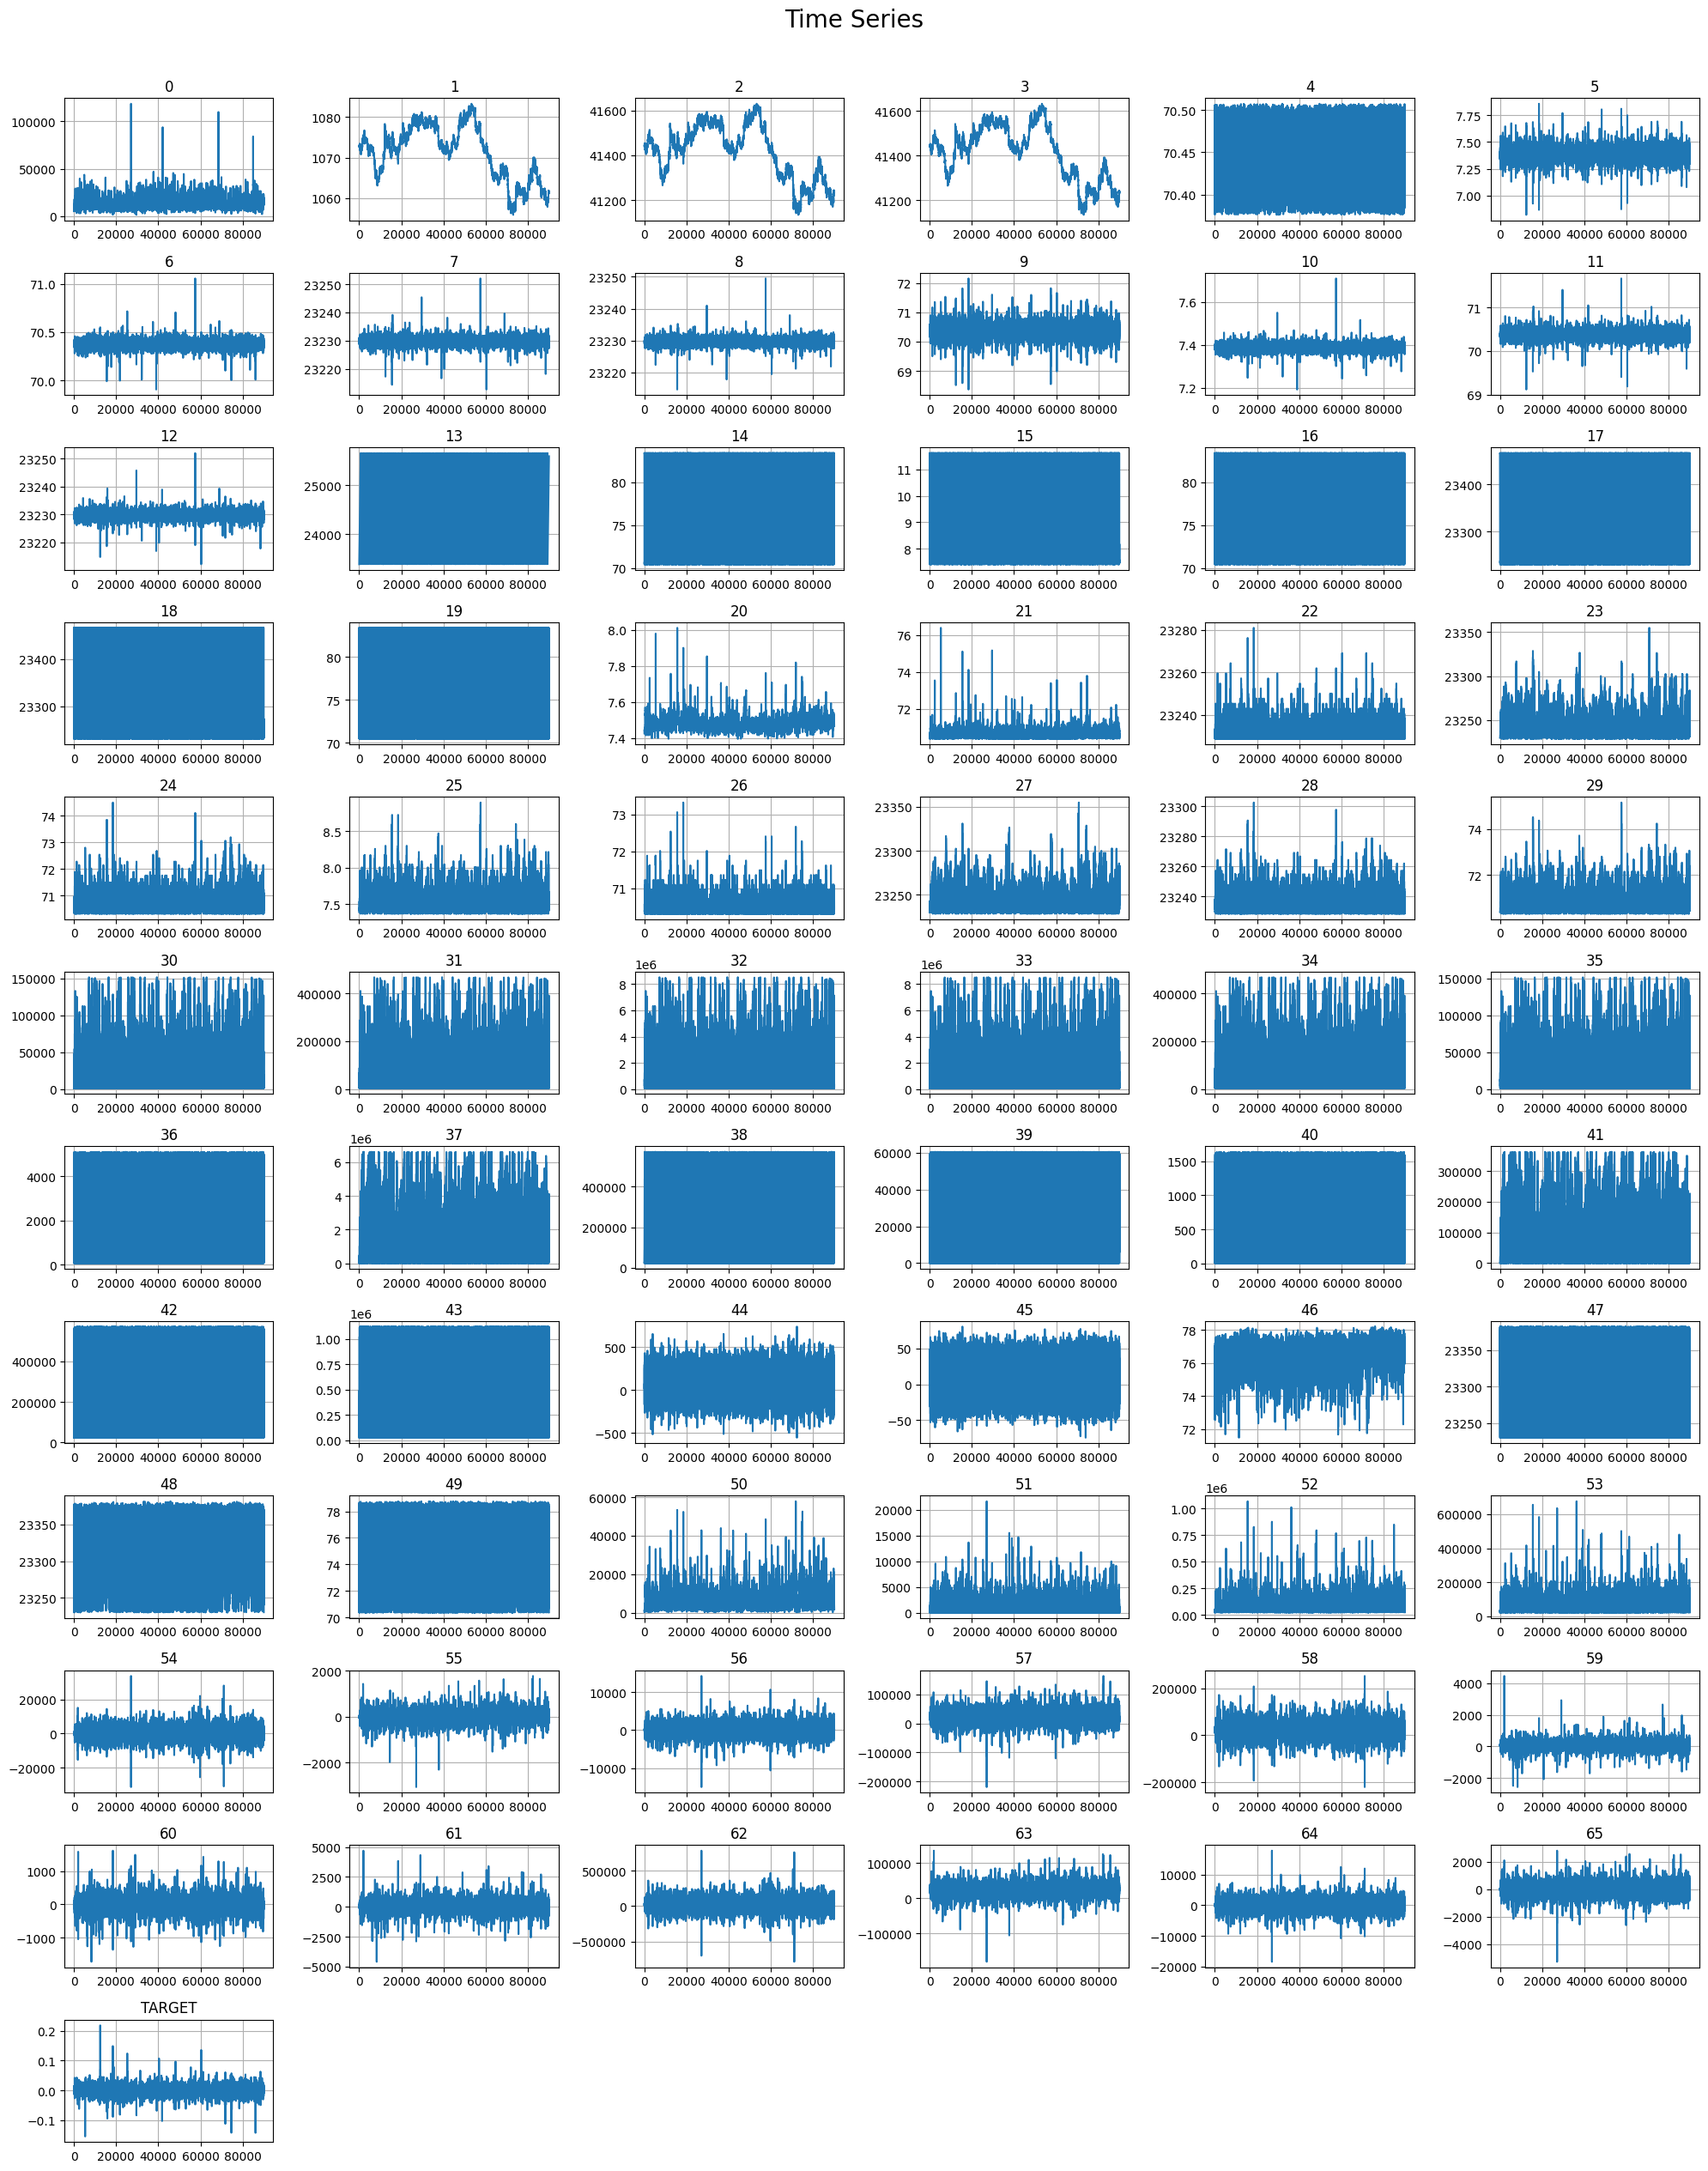

In [14]:
generate_time_series_grid(df_train_val)

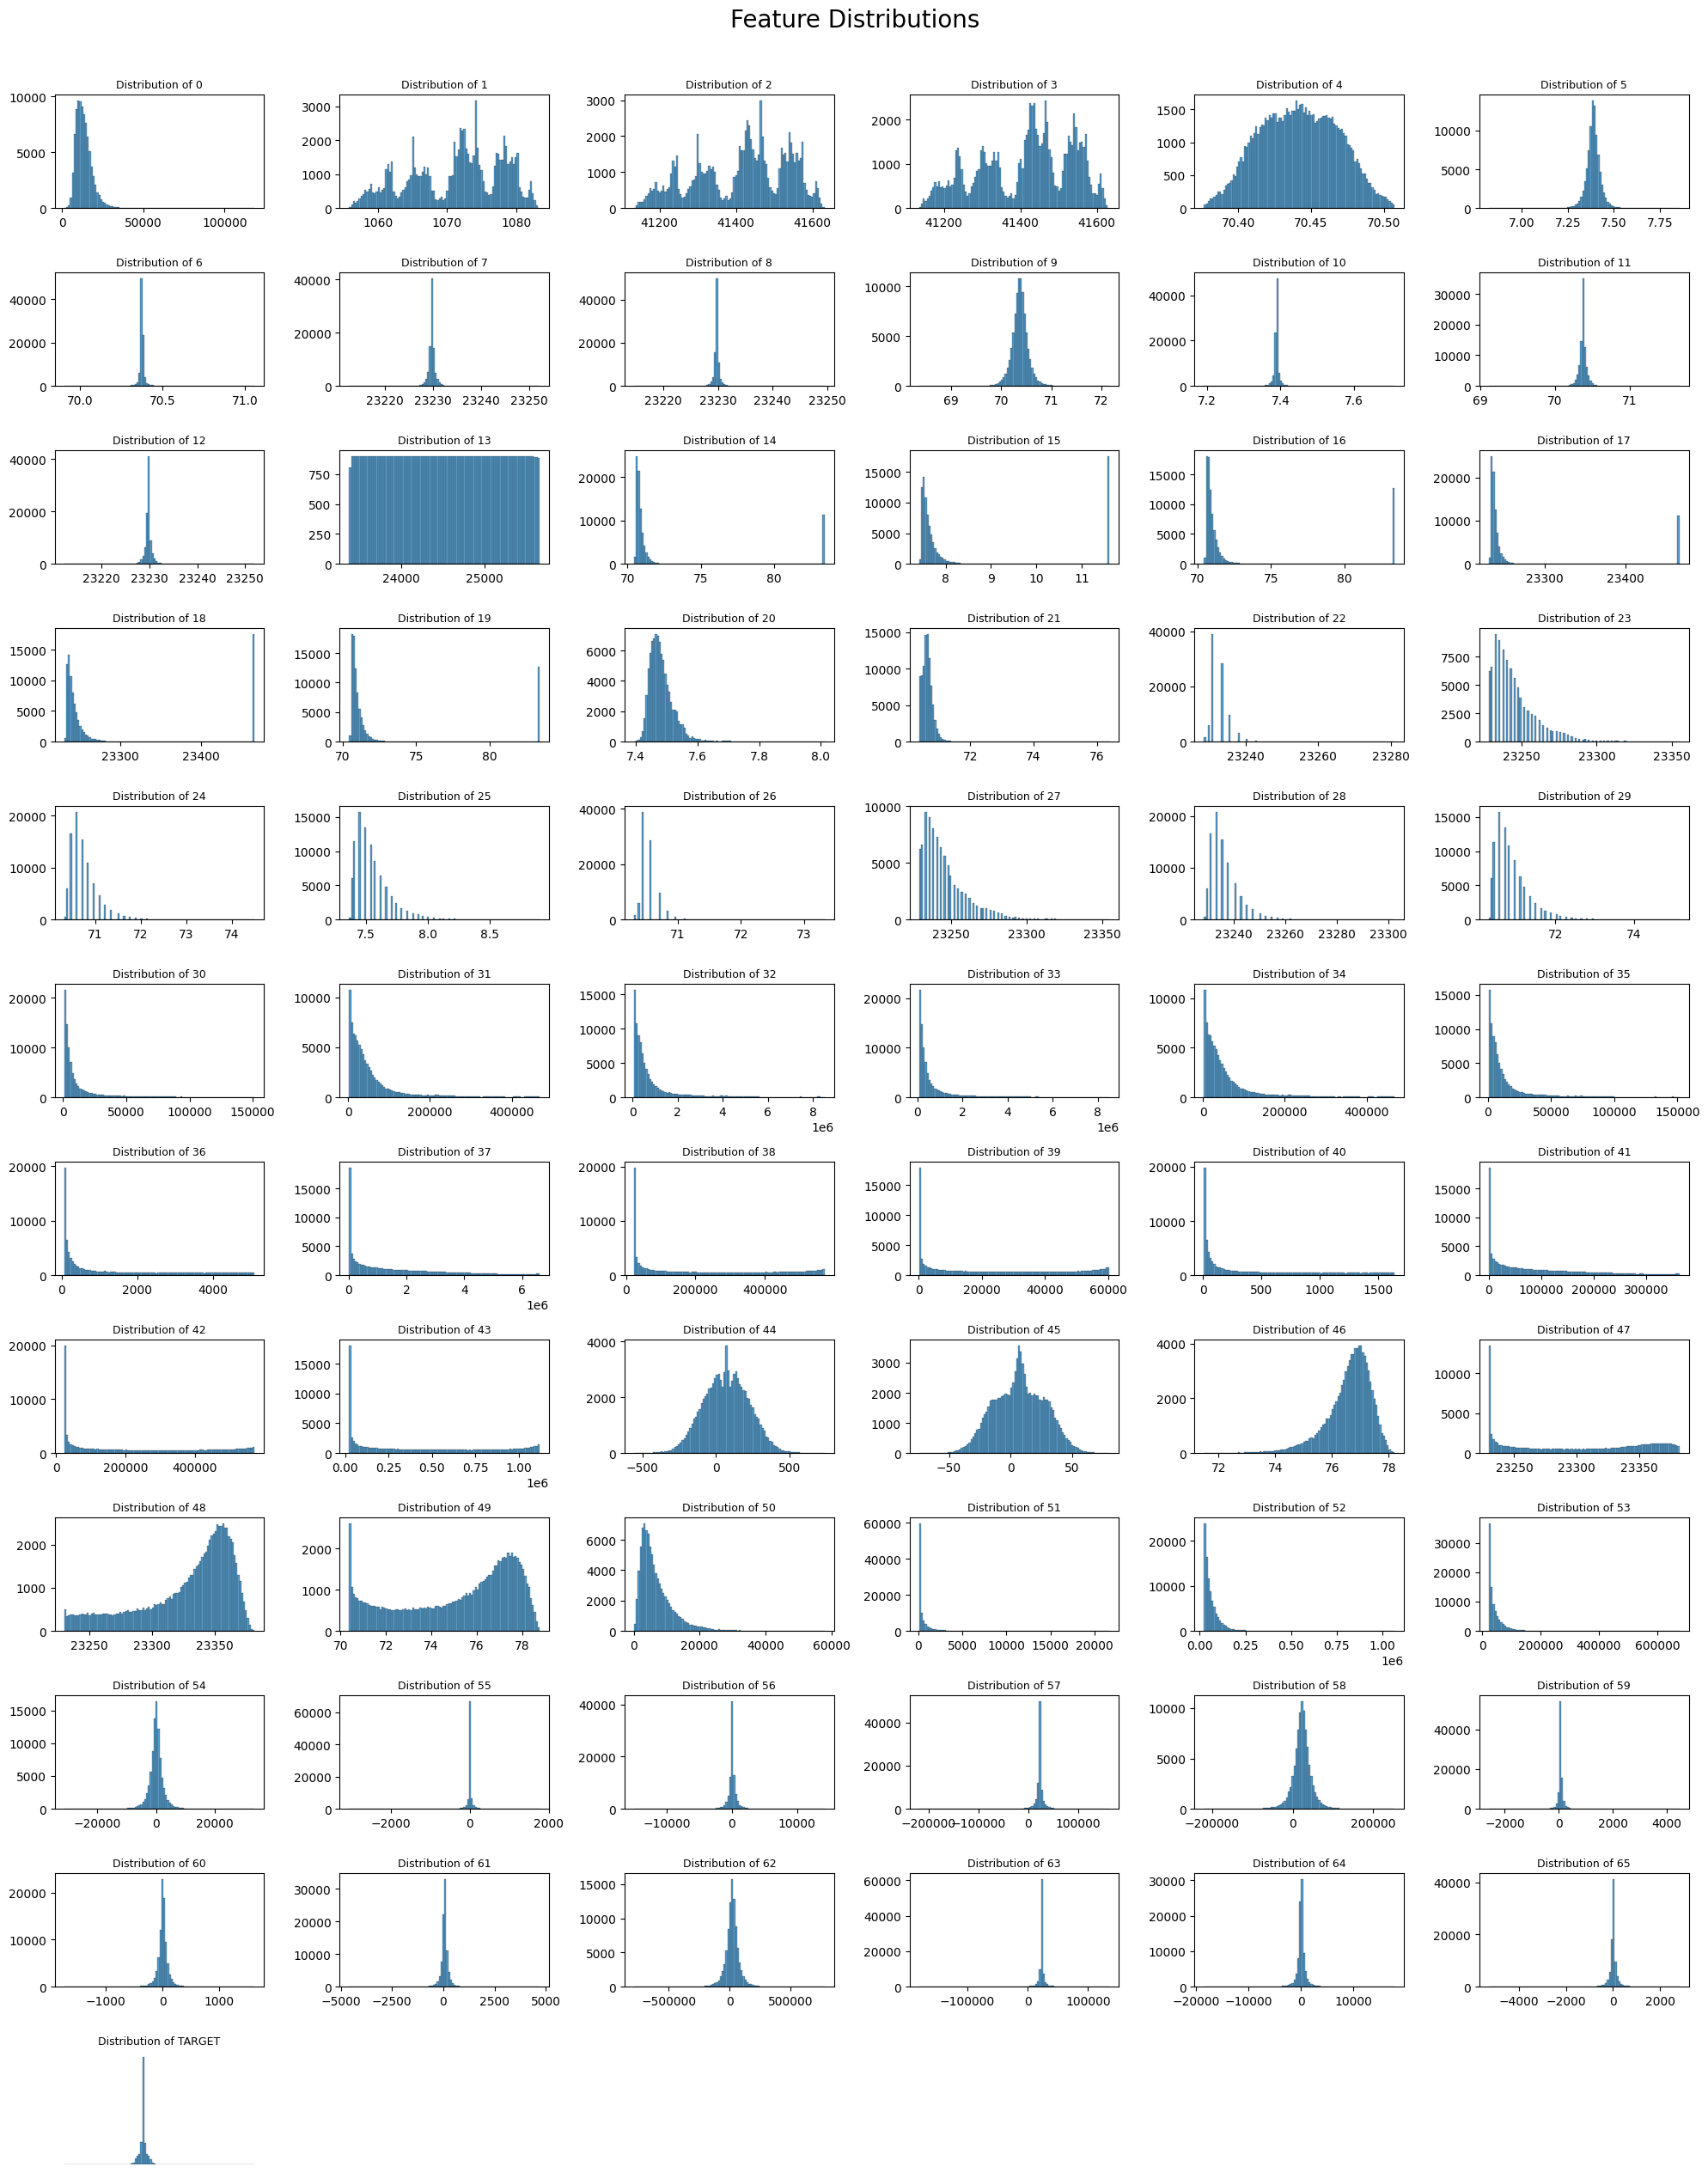

In [15]:
generate_distributions_grid(df_train_val)

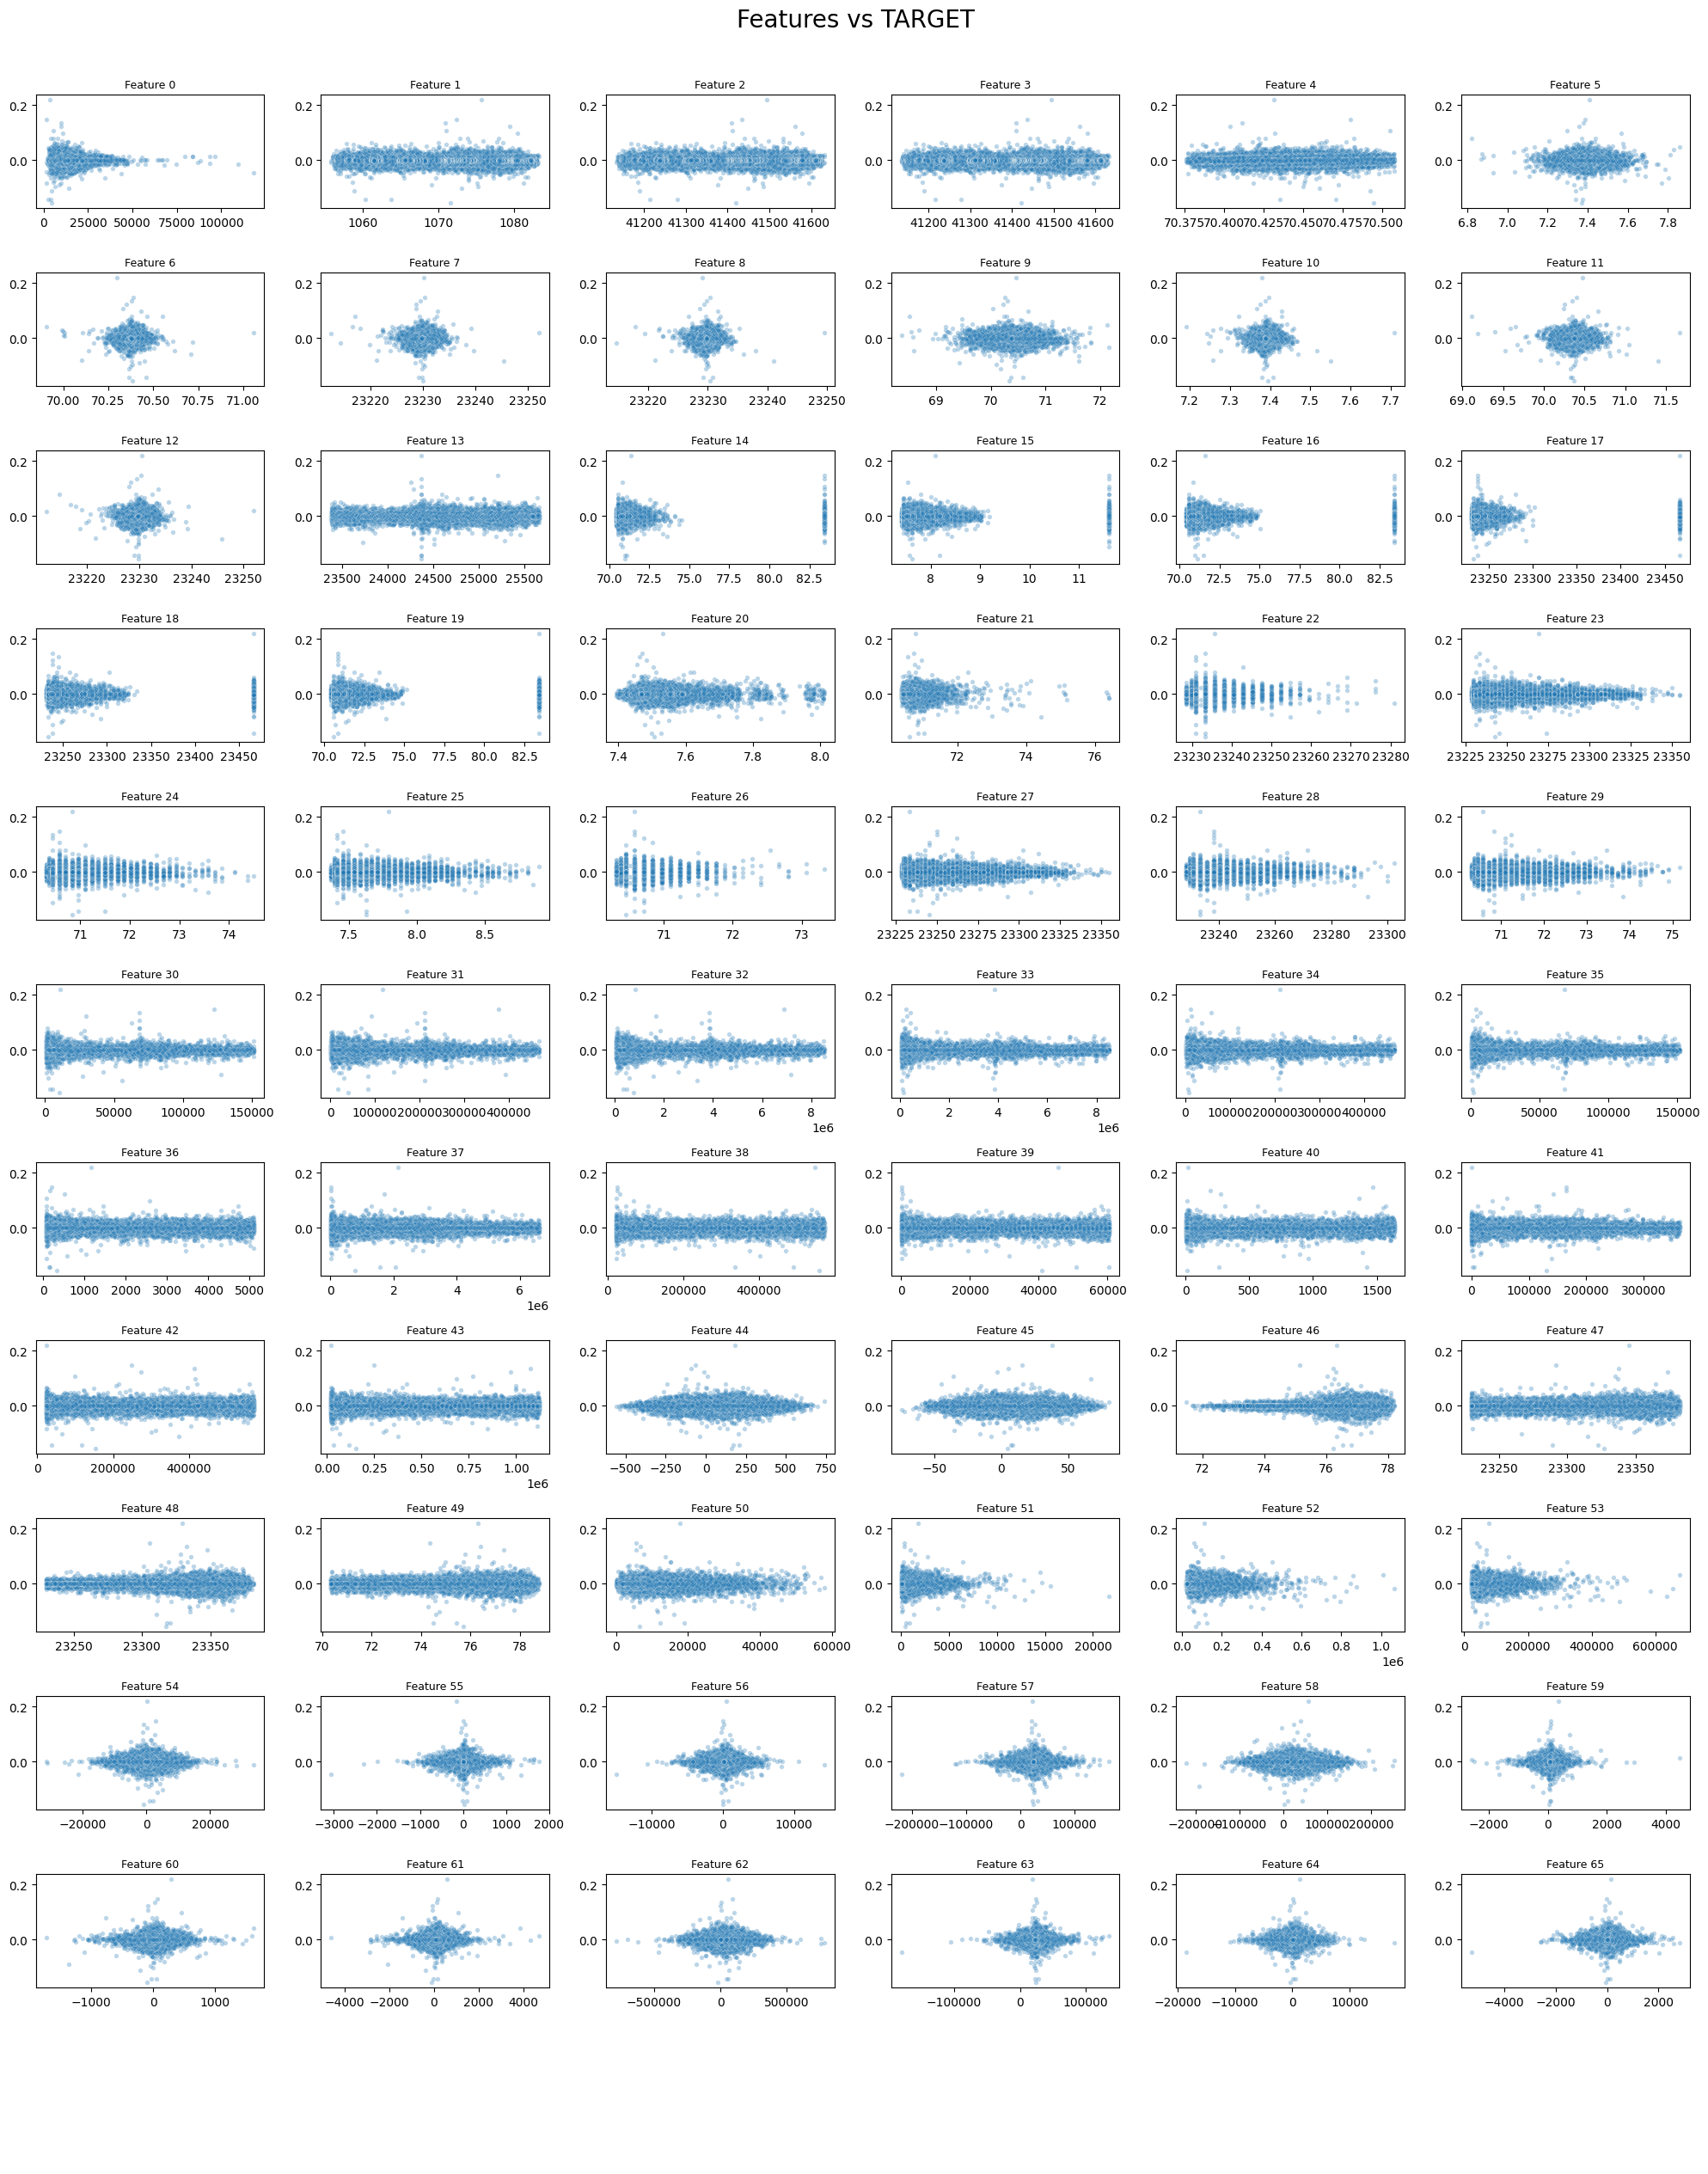

In [16]:
generate_features_vs_target_grid(df_train_val)

**Learnings:**

To begin, let us focus on the Time Series plots...

Here, we observe many feautres to be non-stationary due to changing mean (e.g. Feature 1,..,3) and also variance (e.g. Feature 9, 34). Indeed, features have significantly different scales and time series profiles, however, even with limited domain knowledge, one can make educated guesses as to what these represent. 

From the perspective of making trades (on some financial instrument), we expect to be dealing with Limit Order Book (LOB) data in some capacity. In this context, one immediately thinks of features such as (but not limited to): ask price (across levels), bid price (across levels), ask volume (across levels), bid volume (across levels), the spread, the imbalance, the micro price, etc. 

Of course, confidently assigning the Features in the time series in this manner to such statistics is difficult without explicit knowledge of the financial instrument being traded, as well as insight as to how the data is obtained, however we can make some intial educated guess:
- Features 2 and 3 look indicative of (potentially scaled) (top of book) bid & ask prices. Feature 1 is then possibly the spread, agian scaled/augmented in some way.

- In regards to the temproal differences between samples, it is hard to say, however the number of samples per day appears comparable of that to a days worth of data of CME 6E futures (https://www.cmegroup.com/markets/fx/g10/euro-fx.html), which is similarly event driven, with time deltas ranging from single microseconds to single seconds.

- Additionally, we would expect that some of the features here belong to the (top of book) volumes, although this is not obviously identifiable due to the fact no feature drops to zero and then takes on reasonable positive value. Upon further inspection, one could imagine features 30 - 32 to represent the volumes of the top three levels (scaled in some manner) on one side of the book, and features 35 - 33 to do so on the other. Indeed we expect such values on each side of the book to be comparable in magnitude (and symmetric in aggregation), since imbalance in the LOB is a clear signal of the markets view of the true fair value of the underlying asset.

(**We limit our iscussion of these features for now, but of course we could go into more detail with more time!**)

Now looking at the Feature Distribution plots...
- Varying distributions, from Gaussian like to heavy tailed distributions.
- Certain features appear to have clear outliers (see Features 14 to 19).

Features have significantly different scales and distributions. 

- Certain features are more "categorical" in nature.
- No clear predictive power from any feature.

In light of the above discussion, we spend some time investiggating Features 1, 2, and 3 below. Our prior is that Feature 1 is a function of the spread, whereas Features 2 and 3 represent functions of the bid and ask (or vice versa).

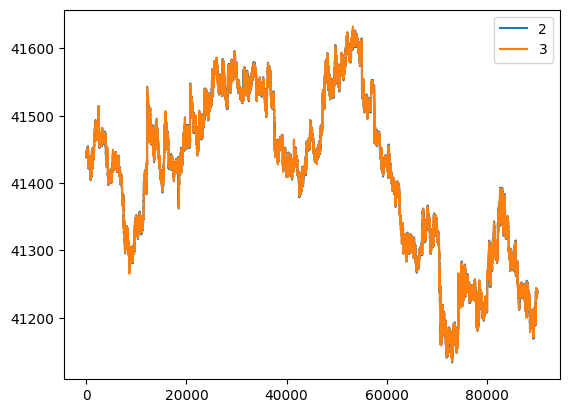

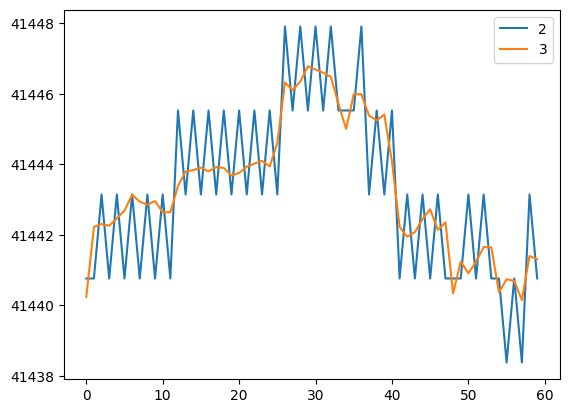

In [17]:
# Plot entire time series
df_train_val[['2', '3']].plot()
plt.show()

# Plot subset of time series
df_train_val[['2', '3']].iloc[0:60].plot()
plt.show()

Indeed, Feature 2 appears to be the top of book quote, for each sample, alternating between the bid and the ask. Feature 3 on the other hand appears to be a mid-type price, perhaps that of the micro price.

In fact, this is consistent with the number of unique values observed for these features, as a micro price is defined as a function of the prices and volumes in a non linear manner, and so we would expect significantly more unique values than that of the (top of book) prices for example.

In fact, based on this assumption, we can reconstruct a proxy of the top of book bid and asks, and consequently the mid price, and thus check how this compares to Feature 3. We achieve this with the code below, and note how Feature 3 always lies between the (last known) bid and ask. In fact, note that we can leevrage this fact to note that the (unobservable) bid must have fallen from index 44 to 45 (so that the microprice is > bid).

 Also note how it falls either side of the mid price, unless $V_{a} = V_{b}$, importantly reflecting pressure in the LOB.

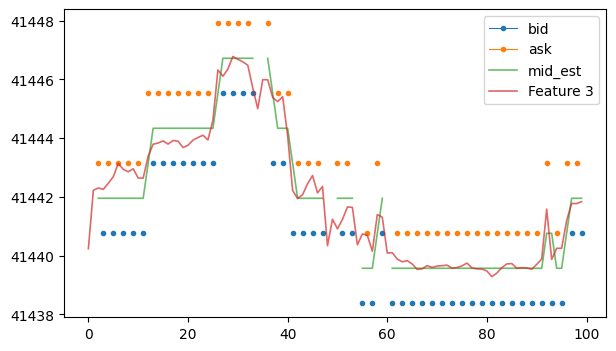

In [ ]:
s2 = pd.to_numeric(df_train_val['2'], errors='coerce').reset_index(drop=True)

hi = s2.rolling(2).max()
lo = s2.rolling(2).min()
sum2 = hi + lo
other = sum2 - s2
spread = hi - lo

# keep only times where the 2-pt window is valid (not NaN, positive spread)
valid = spread.notna() & (spread > 0)

# classify and build bid/ask series (NaN when not valid)
bid = s2.where(valid & (s2 <= other))
ask = s2.where(valid & (s2 >  other))
mid_est = (sum2 / 2).where(valid)


plt.figure(figsize=(7,4))
ax = bid.iloc[:100].plot(style='o-', lw=0.8, markersize=3, label='bid')
ask.iloc[:100].plot(ax=ax, style='o-', lw=0.8, markersize=3, label='ask')
mid_est.iloc[:100].plot(ax=ax, style='-', lw=1.2, alpha=0.7, label='mid_est')
pd.to_numeric(df_train_val['3'], errors='coerce').reset_index(drop=True).iloc[:100].plot(ax=ax, style='-', lw=1.2, alpha=0.7, label='Feature 3')

ax.legend()
plt.show()

Similar investigations into other features could be made, however we are unfortuantely limited by time!

Now, we look to understand the correlations between predictors and the target.

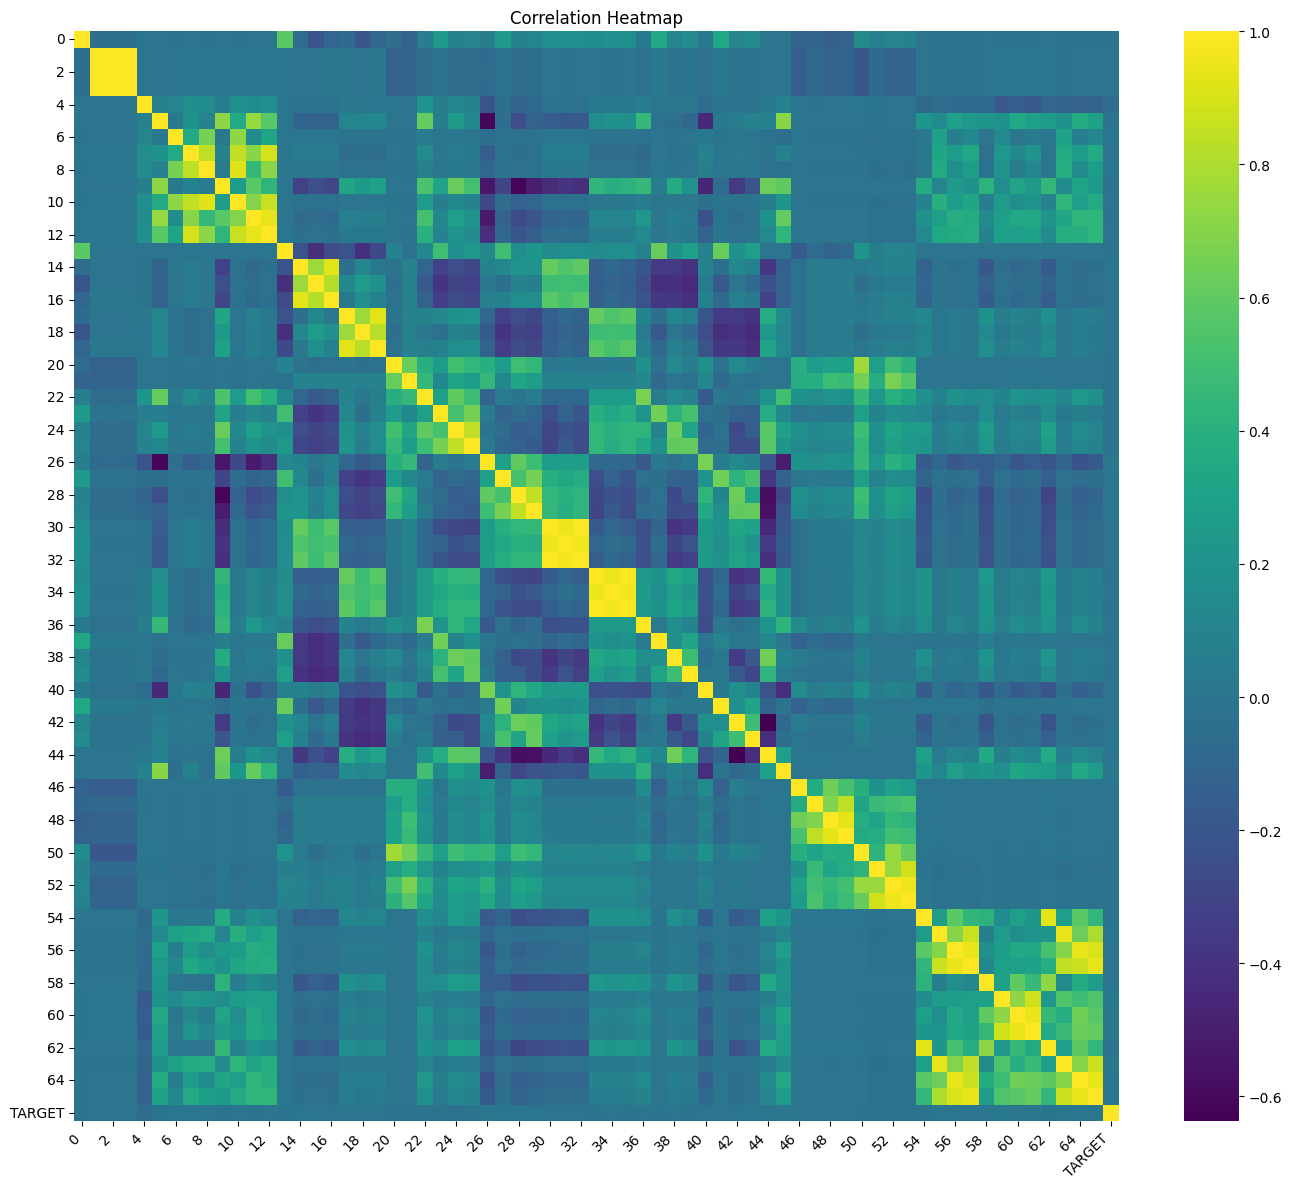

In [20]:
### Correlations between predictors (and TARGET) ###

corr_matrix = df_train_val.corr(method='pearson')

plt.figure(figsize=(14, 12))

sns.heatmap(corr_matrix, cmap='viridis', annot=False)

plt.title('Correlation Heatmap')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# plt.savefig('corr_heatmap.png')
plt.show()

**Learnings:**
- Blocks of high multi-collinearity exist, likely due to the respective features being derived from similar (if not the same) information (e.g. rolling statistics of very similar window sizes). This also indicates we may have redundant information.

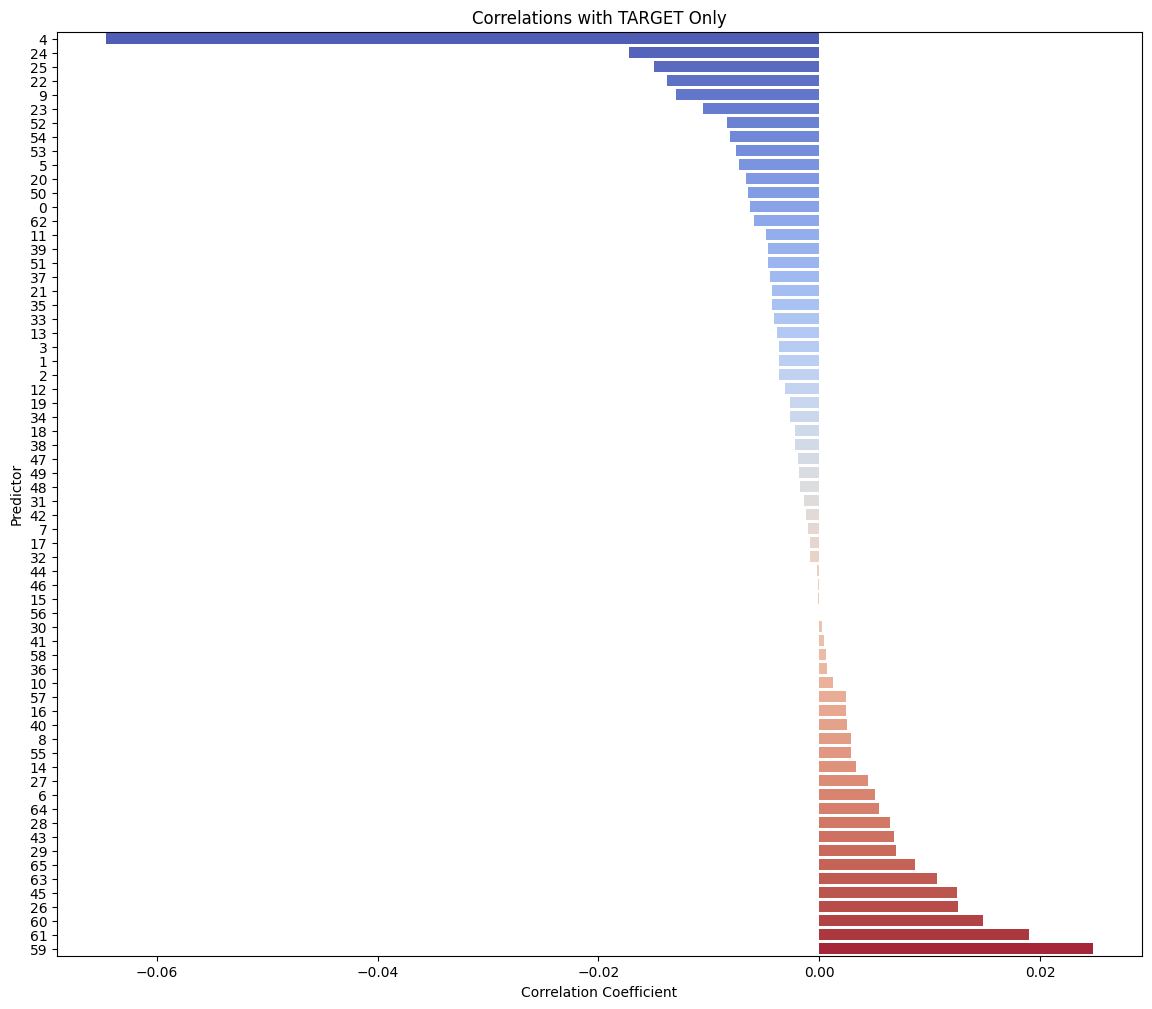

In [21]:
### Correlations between predictors AND TARGET only ###

# Calculate correlations with the target
correlations = df_train_val.corr(numeric_only=True)[TARGET_COL].dropna().sort_values()
# Remove redundant target with target correlation
correlations = correlations.drop(TARGET_COL)

plt.figure(figsize=(14, 12))

sns.barplot(x=correlations.values, y=correlations.index, palette='coolwarm', hue=correlations.index, legend=False)

plt.title(f'Correlations with TARGET Only')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Predictor')
plt.show()

**Learnings:**
- Very low correlations with target, indicating that predictive signals, if they exist, are hidden in non-linear patterns.

As a result, and as a quick check, we have that the best $R^{2}$ that can be achieved via a univariate regression model is $\sim (-0.06)^{2} \sim 0.004$, where specifically we would utilise feature `"4"`. This should be kept in mind as a baseline for when we perform model training and evaluation later.

We note that this is far worse than say the Imbalance in a HFT setting (at least for the FX asset class, which from experience can give low single digit $R^{2}$).

There is of course the nuance as to whether the $R^{2}$ metric, and more importantly its application, is fair in this context! Specifically, we have that our target is crudely the returns, and so we have that
$$
    R^{2} = 1 - \frac{\sum_{i=1}^{n} (y_{i} - \hat{y}_{i})^{2}}{\sum_{i=1}^{n} (y_{i} - \bar{y})^{2}},
$$
where notably the denominator can be thought of as the error of a simple baseline that always predicts the average return. Indeed note that in our case, the returns are simply $y_{t} = p_{t+k} - p_{t}$, and so we have that, in the case that $k=1$:
$$
    \frac{\bar{y} = \sum_{t=1}^{n} (p_{t+1} - p_{t})}{n} = \frac{(p_{n+1} - p_{1})}{n},
$$
that is we compare to a model that knows the final price of the given split, and is thus utilising information from the future for a given sample!

In [ ]:
from sklearn.linear_model import LinearRegression

correlation_matrix = np.corrcoef(df_train_val['4'].to_numpy(), df_train_val[TARGET_COL].to_numpy())
correlation_coefficient = correlation_matrix[0, 1]
r_squared_from_corr = correlation_coefficient ** 2

print(f"Pearson Correlation Coefficient (r): {correlation_coefficient:.4f}")
print(f"Max R^2 (from correlation squared): {r_squared_from_corr:.4f}")
print("-" * 30)

model = LinearRegression()
model.fit(df_train_val['4'].to_numpy().reshape(-1, 1), df_train_val[TARGET_COL].to_numpy())
r_squared_from_model = model.score(df_train_val['4'].to_numpy().reshape(-1, 1), df_train_val[TARGET_COL].to_numpy())

print(f"R^2 from univariate regression: {r_squared_from_model:.4f}")

# The results are identical
assert np.isclose(r_squared_from_corr, r_squared_from_model)

Pearson Correlation Coefficient (r): -0.0646
Max R^2 (from correlation squared): 0.0042
------------------------------
R^2 from univariate regression: 0.0042


## Feature Importance & Selection

In light of the above, one could perform feature selection to reduce dimensionality, in order to 
- Address concerns of multicollinearity from the perspective of interpretability
- Ovoid overfitting/improve generalisation
- Reduce computational cost

One such approach is that of Principal Component Analysis (PCA). Although this could effectively be treated as a hyperparameter in our subsequent `sklearn` training pipeline, we expect this to perform poorly in this setting due to the fact that:
- Low signal to noise ratio -> PCA optimises for maximum variance, not necessarily the features/directions most relevant to the downstream task. This is an issue when we have a subtle pattern hidden behind dominant noise!
- Outliers can heavily influnce the principal components (consistent with MSE (and variance basd methods) being very sensitive to outliers).
- PCA captures directions of maxiumum variance under the assumption that the linear projections are meaningful, which is an issue if data is inherently non-linear.
- In the context of trading, the lack of interpretability pertaining to the principal components may be problematic (particularly when something goes wrong)!

In any case, we quickly perform PCA to verify that any potential signal is not concentrated in a few of our features.

X_train_val.shape=(90000, 66)
y_train_val.shape=(90000,)


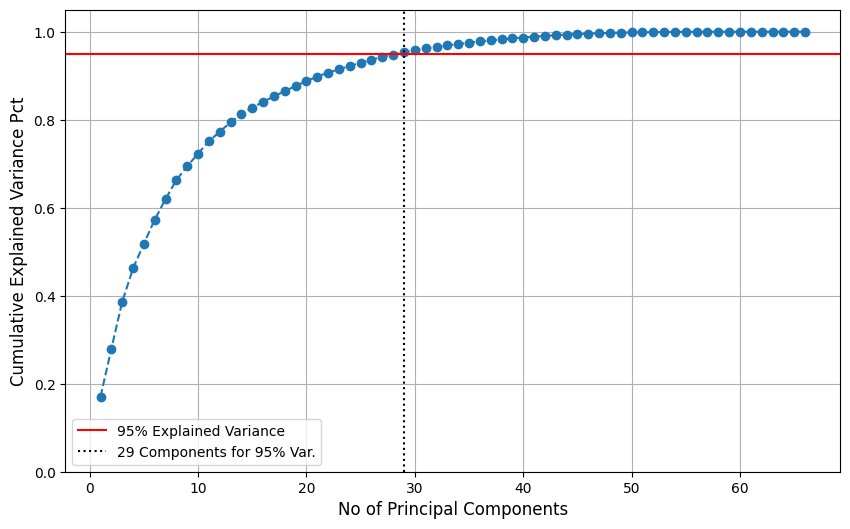

Number of components to explain 95% of variance: 29


In [ ]:
X_train_val = df_train_val[FEATURE_COLS].copy().to_numpy()
y_train_val = df_train_val[TARGET_COL].copy().to_numpy()

print(f"{X_train_val.shape=}")
print(f"{y_train_val.shape=}")

# Critical to scale the data prior to PCA
scaler = StandardScaler()
X_train_val_scaled = scaler.fit_transform(X_train_val)

pca = PCA()
pca.fit(X_train_val_scaled)

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# No. Components needed for 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
ax.axhline(y=0.95, color='r', linestyle='-', label='95% Explained Variance')
ax.axvline(x=n_components_95, color='k', linestyle=':', label=f'{n_components_95} Components for 95% Var.')
ax.set_xlabel('No of Principal Components', fontsize=12)
ax.set_ylabel('Cumulative Explained Variance Pct', fontsize=12)
ax.set_ylim(0, 1.05)
ax.legend()
plt.grid(True)
plt.show()

print(f"Number of components to explain 95% of variance: {n_components_95}")


If we wanted to incorporate PCA into our subsequent model training pipeline, we could simply include the below.

In [24]:
### Hyperparameter Tuning (With PCA) ###

class PCAVariance(BaseEstimator, TransformerMixin):
    def __init__(self, variance_threshold=0.95):
        self.variance_threshold = variance_threshold
        self.n_components_ = None

    def fit(self, X, y=None):
        pca = PCA().fit(X)
        cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
        self.n_components_ = np.argmax(cumulative_variance >= self.variance_threshold) + 1
        return self

    def transform(self, X, y=None):
        pca = PCA(n_components=self.n_components_)
        return pca.fit_transform(X)

"""
We would then define models in a manner similar to the below:
```
models_pca = {
    "Elastic Net": Pipeline([
        <previous_steps>,
        ('scaler', StandardScaler()),
        ('pca', PCAVariance()),
        ('regressor', ElasticNet(random_state=42, max_iter=2000)),
    ]),
```
"""


'\nWe would then define models in a manner similar to the below:\n```\nmodels_pca = {\n    "Elastic Net": Pipeline([\n        <previous_steps>,\n        (\'scaler\', StandardScaler()),\n        (\'pca\', PCAVariance()),\n        (\'regressor\', ElasticNet(random_state=42, max_iter=2000)),\n    ]),\n```\n'

Alternative methods which could be utilised to perform feature selection include:
- VIF
- Correlation de-duplication
- Permutation Importance

The models we choose to focus on (see below) are robust to multicollinearity, and so in the abscence of stability and speed concerns, we choose to perform feature selection in a pruning manner having trained with all features.

As a crude initial check, we compute the feature importances for LightGBM model fitted on the entirety of $\mathcal{D}_{train,val}$.

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004719 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13673
[LightGBM] [Info] Number of data points in the train set: 90000, number of used features: 66
[LightGBM] [Info] Start training from score -0.000018


/var/folders/p7/j8d1ct3n6r5b879xs9vhfkfh0000gn/T/ipykernel_102/2382172315.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=importances_df.head(20), palette='viridis', ax=ax)  # Top 20 most important


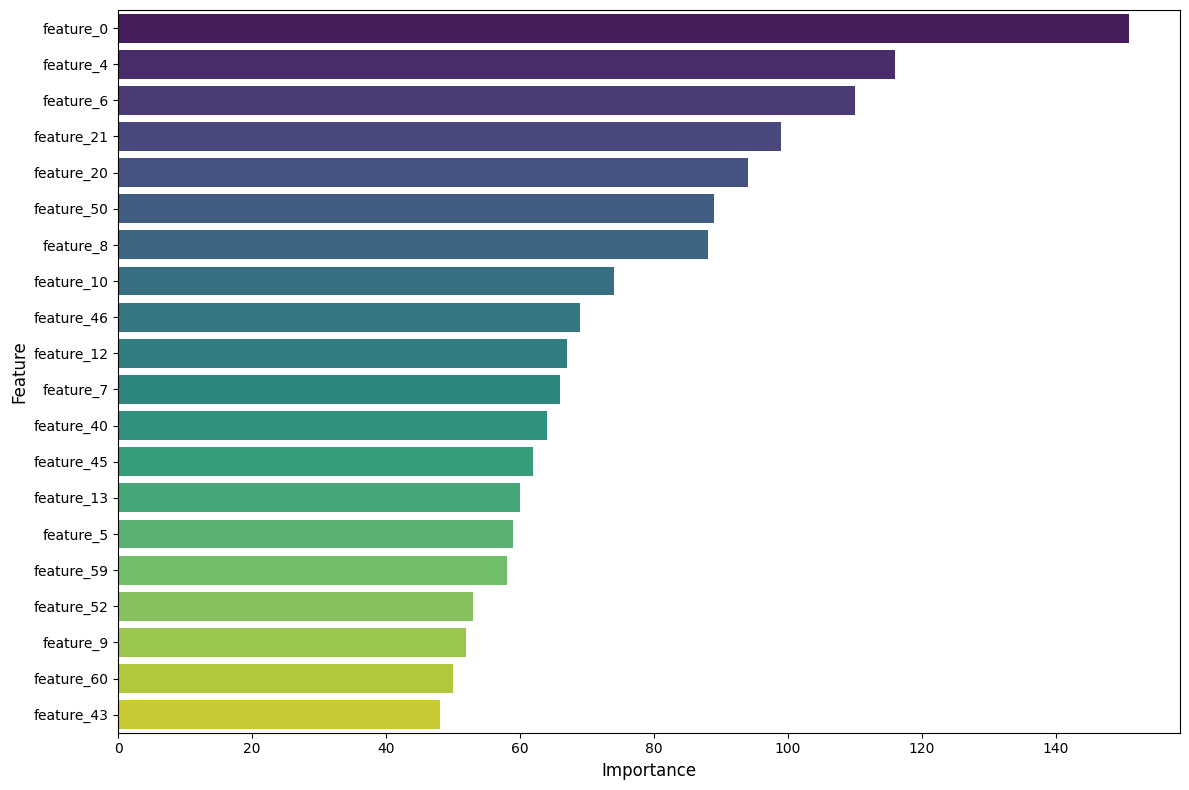


Features ranked by importance in crude model:
   feature  importance
 feature_0         151
 feature_4         116
 feature_6         110
feature_21          99
feature_20          94
feature_50          89
 feature_8          88
feature_10          74
feature_46          69
feature_12          67
 feature_7          66
feature_40          64
feature_45          62
feature_13          60
 feature_5          59
feature_59          58
feature_52          53
 feature_9          52
feature_60          50
feature_43          48
feature_61          48
feature_58          46
feature_62          46
feature_53          45
feature_54          44
feature_51          44
feature_26          44
feature_48          44
feature_30          44
 feature_1          44
feature_11          42
feature_64          42
feature_56          39
feature_39          39
feature_36          38
feature_33          38
feature_27          38
feature_63          37
feature_55          36
feature_22          36
feature_41

In [25]:
# Don't require scaled data!
lgbm = lgb.LGBMRegressor(random_state=42)
lgbm.fit(X_train_val, y_train_val)

feature_names = [f'feature_{i}' for i in range(X_train_val.shape[1])]

importances_df = pd.DataFrame({
    'feature': feature_names,
    'importance': lgbm.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=importances_df.head(20), palette='viridis', ax=ax)  # Top 20 most important
ax.set_xlabel('Importance', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

print("\nFeatures ranked by importance in crude model:")
print(importances_df.head(66).to_string(index=False))

Interestingly, note how Feature 2 and Feature 3 rank low here.

## Feature Engineering

Feature engineering, that is the creation of new features based upon those that exist, should be driven from the perspective of satisfying modelling assumptions and uncovering 'alpha'. 

- Although difficult to encapsulate all the apporaches possible, in light of the Feature Distribution plots seen above, logarithmic and Yeo-Johnson transformations look promising to address non-normality. 

- Furthermore, outliers could be detected via a robust Z-score (i.e. utilise median and MAD instead of mean and s.d.), and subsequently dealt with using trimming, winsorisation, or imputation. In any case this should be done in a transparent, systematic and reproducible manner.

- Handcrafted features, leveraging understanding of the market microstructure, or even general domain knowledge, can be fruitful. For example, in the case of the latter we can point to a univariate Imbalance regression model, refitted every `n` days, being a competitive baseline.

- Features can be engineered to capture different regimes through rolling statistics and lagged values.

In the abscence of domain expertise, explicit understanding of the features, and since we utilise models without strict modelling assumptions, we skip the process of Feature Engineering, however provide the capability to do so in our pipeline. Note, we have taken care to ensure that the Feature Engineering is performed within the respective fold so that no data leakage occurs!

In [26]:
"""
Example of how to incorporate feature engineering into pipeline
-> Differencing of `diff_cols`
-> Rolling volatility windows for `vol_cols`, motivated by the "Rolling Mean and STD of TARGET" plot

Simply utilise something like:
```
fe = FeatureEngineer(
    original_features=FEATURES_TO_USE,
    diff_cols=COLS_TO_DIFF,
    vol_cols=COLS_TO_CALCULATE_VOL_WINDOWS,
    vol_windows=VOL_WINDOWS,
)
X_train_val_fe  = fe.transform(X_train_val).astype(np.float32, copy=False)
```
instead of X_train_val.
"""

class FeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(
            self, 
            original_features: list[str], 
            diff_cols: list[str],
            vol_cols: list[str], 
            vol_windows: list[int],
        ):
        self.original_features = original_features
        self.diff_cols = diff_cols
        self.vol_cols = vol_cols
        self.vol_windows = vol_windows
        self.feature_names_ = None

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df = pd.DataFrame(X, columns=self.original_features)

        new_cols = {}

        # diffs
        for col in self.diff_cols:
            s = df[col].diff()
            new_cols[f'{col}_diff'] = s

        # rolling stds
        for col in self.vol_cols:
            s = df[col]
            for window in self.vol_windows:
                new_cols[f'{col}_vol_{window}'] = (
                    s.rolling(window=window, min_periods=1).std() # Expanding window at start (fo fold)
                )

        if new_cols:
            df = pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)

        # Set NaNs from diff/rolling to 0
        df = df.fillna(0)

        self.feature_names_ = df.columns.tolist()
        return df.to_numpy()
    

# Model Development

#### Problem Formulation
Indeed, the modelling problem we are faced with is filled with nuance, and as such we must be both considerate and purposeful with all decisions we make.

To begin, note that the problem could be framed from the perspective of either classification or regression. We opt for the latter, since 
- The goal is to be not only profitable, but maximally profitable. 
- A regression formalism allows us to naturally specify custom loss functions that are explicitly tied to our goal, which is particularly powerful in a `PyTorch` setup.

*Indeed, one could utilise classification formalism, in which we weight samples by the magnitude of the respective returns, however leave this for further work.*

In such a set up, it is thus natural to leverage a threshold upon which we decide whether or not to trade, so that 
$$
    P = \sum_{i \in T} y_{i}, \quad \text{where} \quad T = \left\{ i \ \vert \ \hat{y}_{i} > 0 \right\},
$$
that is our total profit is given by the sum of profits for trades where our regression model predicts a return larger than zero.

Ideally any regression model we train would not possess bias, in the sense that predictions above $0$ correspond to a profitable trade, however due to the possibility of models being uncertain/performing inconsistently near this decision boundary we include an additional hyperparameter, $\tau$, in the tuning of our models, so that $T = \left\{ i \ \vert \ \hat{y}_{i} > \tau \right\}$.

- This threshold can be understood as a filter for conviction.
- Higher $\tau$ could lead to fewer, higher-conviction (and more profitable) trades, whereas lower $\tau$ leads to more trades.


#### Models Considered

The universe of models one could consider here is significant, ranging from classical statistical models to more recent deep learning models. 

In light of having:
- A significant number of (mostly) unknown features,
- Features that do not satisfy the assumptions of linear regression (at least in their untransformed form) (see Appendix for explicit verification),
- No interaction terms

it is natural to consider tree-based models, as these are crucially free of restrictive assumptions pertaining to the distribution of errors and the realtionship between the features and response. Furthermore, such models naturally handle interaction effects as well as implicitly performing feature prioritisation, which can be valuable from a dimensionality reduction and interetability standpoint.

To this end, we consider `LightGBM`, `XGBoost` and `CatBoost` models for this task. 

These models, however, do not natually exploit any temporal patterns within the dataset, since by default they will utilise only a single row of data per sample. An alternative approach is to instead, for a given sample which we refer to as a snapshot, build up a "snapshot sequence", where we aim to exploit recent values and changes in the sequence. For example, for a snapshot at temporal index $i$, denoted $x_{i}$, we would build our $X$ utilising $(x_{i-K}, \dots, x_{i})$, where $K$ is the sequence length. For a nice example of this, see the **DeepLOB** paper. Indeed the aforementioned model, or even simply an `LSTM` model would be worthy of investigation in such a setting, and we focus on the latter due to the time constraint.

- Due to the size of the data, implementation of the model, potential data preprocessing logic, and potential parallelisation, this is best handled in a deep learning framework. Specifically, we leverage `pytorch_lightning` due to its simplicity.

#### High Level Summary
- We frame the problem as one of regression.
- We choose to explore `LightGBM`, `XGBoost` and `CatBoost` models in a `sklearn` training framework.
- We also briefly explore an `LSTM` model in a `pytorch_lightning` training framework.


# Model Training Pipeline

At a high level, our model training pipeline, which acts on $\mathcal{D}_{train,val}$, is controlled by `run_training_pipeline_sklearn`, which does the following:

- Takes in a collection of models, respective hyperparameter grids, and evaluation metric to choose hyperparameters.

- For each (model, hyperparameter grid, evaluation metric) combo, we perfrom walk forward cross validation. Crucially, this respects the temporal dependency of the data, preventing look ahead biad by **ensuring we do not** train on future data and evaluate in the past.
\
\
*To be clear, we perform hyperparameter tuning using the dataset $\mathcal{D}_{\text{train,val}}$ by implementing a repeated walk-forward $K$-Fold cross-validation scheme with $K=3$. In this framework, $\mathcal{D}_{\text{train,val}}$ is partitioned into $K$ subsets, referred to as folds. Importantly, in walk-forward cross-validation, the size of the training set $\mathcal{D}_{\text{train}}$ increases with each split. Specifically, in the first iteration, $\mathcal{D}_{\text{train}}$ consists of the first fold, while $\mathcal{D}_{\text{val}}$ corresponds to the second fold. In subsequent iterations, $\mathcal{D}_{\text{train}}$ is extended to include all folds up to (but excluding) the current validation fold, while $\mathcal{D}_{\text{val}}$ corresponds to the next fold. This process continues until the final iteration, where the last fold serves as $\mathcal{D}_{\text{val}}$, ensuring that all folds are used for validation exactly once.*

- Additional metrics, such as the Sortino ratio, MAE, and tuning times are also calculated and reported, to provide a comprehensive overview of model performance.

- The custom metric `'PROFIT'` is used to select hyperparameter configurations that result in the maximal average total profit across validation folds.

- $\tau$ is also a hyperparameter we tune.

Note: The model weight updates and tree bulding are currently done via minimising an internal training objective, distinct to the `'PROFIT'`, and a clear improvement would be to implement a custom metric explicitly tied to this goal.

- We perform tuning of hyperparameters over a relatively small grid in the below -> A clear improvement to our process would be to leverage more automated hyperparameter approaches, which can be achieved via `Optuna`. 
- We would also ideally log experiments via either `TensorBoard` or `MLflow`.

In [27]:
class SelectionHyperparams(BaseEstimator, TransformerMixin):
    """
    TODO
    """
    def __init__(self, tau=0.0):
        self.tau = tau

    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        return X
    
def create_pipeline_scorer(metric_func):
    """
    TODO
    """
    def scorer(estimator, X, y_true):

        y_pred = estimator.predict(X)
        
        try:
            tau = estimator.named_steps['selector'].tau
        except (KeyError, AttributeError):
            print('Warning: No tau found!')
            tau = 0.0
            
        return metric_func(y_true, y_pred, tau=tau)
        
    return scorer

def total_profit_metric(y_true, y_pred, tau):
    """
    TODO
    """
    # Mask to select trades where the model predicts profit above \tau
    mask = y_pred > tau

    return np.sum(y_true[mask])

def sortino_ratio_metric(y_true, y_pred, tau, rf=0.0, eps=1e-12):
    """
    TODO
    """
    mask = y_pred > tau

    if not np.any(mask):
        return 0.0
    
    r = np.asarray(y_true)[mask] - rf
    mean_r = np.mean(r)
    downside = r[r < 0]
    dd = np.sqrt(np.mean(np.square(downside))) if downside.size > 0 else 0.0
    sortino = mean_r / (dd + eps)
    
    return sortino


SCORES = {
    'PROFIT': create_pipeline_scorer(total_profit_metric),
    'SORTINO': create_pipeline_scorer(partial(sortino_ratio_metric, rf=0.0)),
    'MSE': 'neg_mean_squared_error',
    'MAE': 'neg_mean_absolute_error',
    'R2': 'r2'
}

def run_training_pipeline_sklearn(
        X_train_val: np.ndarray, 
        y_train_val: np.ndarray, 
        models: dict, 
        param_grids: dict, 
        score_to_use: str = 'PROFIT',
        n_splits: int = 3,
        ):


    best_estimators = {}
    results_summary = []

    # Walk-Forward Cross Validation
    tscv = TimeSeriesSplit(n_splits=n_splits)

    print("Commencing model training and hyperparameter tuning...\n")

    for name, model in models.items():
        print(f"Performing hyperparameter tuning for model: {name}")
        
        grid_search = GridSearchCV(
            estimator=model,
            param_grid=param_grids[name],
            scoring=SCORES,
            refit=score_to_use,  # Best model parameters based on our custom score - note `refit` does not actually refit, but specifies preferred metric
            cv=tscv,
            n_jobs=-1,
            verbose=1
        )
        
        grid_search.fit(X_train_val, y_train_val)
        
        best_estimators[name] = grid_search.best_estimator_

        # Store results for later comparison
        best_score = grid_search.best_score_
        best_index = grid_search.best_index_
        
        # Collating results
        summary_row = {
            "model": name,
        }
        for score_name, scorer_obj in SCORES.items():

            mean_key = f'mean_test_{score_name}'
            std_key = f'std_test_{score_name}'
            
            mean_value = grid_search.cv_results_[mean_key][best_index]
            std_value = grid_search.cv_results_[std_key][best_index]
            
            summary_row[f"mean_{score_name}"] = mean_value
            summary_row[f"std_{score_name}"] = std_value
        
        summary_row["best_params"] = grid_search.best_params_
        summary_row["mean_fit_time_secs"] = np.mean(grid_search.cv_results_['mean_fit_time'])

        results_summary.append(summary_row)


        
        print(f"Finished tuning for {name}.")
        print(f"Best CV {score_to_use} Score: {best_score:.4f}")
        print(f"Best Parameters: {grid_search.best_params_}\n")

    print("\nHyperparameter Tuning Complete!")
    print(f"Summary of results based on maximising {score_to_use}:\n")

    results_df = pd.DataFrame(results_summary)
    results_df = results_df.sort_values(by=f'mean_{score_to_use}', ascending=False).reset_index(drop=True)

    print(results_df.to_string())

    # Best model by PROFIT is first one in the sorted dataframe
    best_overall_model_name = results_df.loc[0, 'model']
    best_overall_model = best_estimators[best_overall_model_name]

    print(f"\nBest Overall Model: {best_overall_model_name}")
    print(f"Achieved an average {score_to_use} of {results_df.loc[0, f'mean_{score_to_use}']:.4f} across the validation folds.")

    return {
        'results_df': results_df,
        'best_overall_model_name': best_overall_model_name,
        'best_overall_model': best_overall_model,
    }

# Model Evaluation Pipeline

At a high level, our model evaluation pipeline, which is designed to act on $\mathcal{D}_{train,val}$, is controlled by `generate_oof_predictions`, which does the following:

- Takes in a model, with chosen hyperparameters.
- Recreates the walk-forward train-validation splits, fitting the model on $\mathcal{D}_{train}$ and generating predictions for $\mathcal{D}_{val}$, for each fold.
- Returns all out of fold predictions, ready for visualisations etc.

**Note: As a result, we do not generate predictions for the first $\mathcal{D}_{train}$, recreating a production environment.**

We then have a collection of functions for visualising the predictions.


In [ ]:
def generate_oof_predictions(model, X, y, cv) -> np.ndarray:
    """
    TODO
    """
    print("Generating Out-of-Fold predictions...")
    oof_preds = np.full(y.shape, np.nan)
    
    for train_index, val_index in cv.split(X):
        X_train_fold, X_val_fold = X[train_index], X[val_index]
        y_train_fold = y[train_index]
        
        # Clone the model get unfitted instance
        model_clone = clone(model)
        model_clone.fit(X_train_fold, y_train_fold)
        
        val_preds = model_clone.predict(X_val_fold)
        oof_preds[val_index] = val_preds
        
    print("OOF predictions generated successfully.")
    return oof_preds

def plot_return_histogram(y_true, y_pred, tau, title="Histogram of Strategy Returns"):
    """
    TODO
    """
    mask = y_pred > tau

    strategy_returns = y_true[mask]

    if strategy_returns.size == 0:
        print("No trades were selected by the model! Cannot plot histogram.")
        return

    plt.figure(figsize=(12, 7))
    sns.histplot(strategy_returns, kde=True, bins=100)
    
    mean_return = strategy_returns.mean()
    plt.axvline(mean_return, color='red', linestyle='--', lw=2, label=f'Mean Return: {mean_return:.4f}')
    
    plt.axvline(0, color='black', linestyle='-', lw=1)
    
    plt.title(title, fontsize=16)
    plt.xlabel('Profit / Loss')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def plot_cumulative_profit(y_true, y_pred, tau, title="Cumulative Profit"):
    """
    TODO
    """
    results_df = pd.DataFrame({'y_true': y_true, 'y_pred': y_pred})
    
    results_df['selected'] = results_df['y_pred'] > tau
    results_df['profit'] = np.where(results_df['selected'], results_df['y_true'], 0.0)
    results_df['cumulative_profit'] = results_df['profit'].cumsum()

    results_df['buy_and_hold'] = results_df['y_true'].cumsum()

    # Find first non-NaN prediction index
    valid_mask = ~pd.isna(results_df['y_pred'])
    if not valid_mask.any():
        raise ValueError("y_pred has no valid (non-NaN) predictions.")
    start_idx = np.flatnonzero(valid_mask)[0]

    # Align trade all to model prediction start
    prev_cum = results_df['buy_and_hold'].iloc[start_idx-1] if start_idx > 0 else 0.0
    results_df['buy_and_hold_aligned'] = results_df['buy_and_hold'] - prev_cum
    results_df.loc[:start_idx-1, 'buy_and_hold_aligned'] = np.nan

    plt.figure(figsize=(12, 7))

    results_df['cumulative_profit'].plot(label='Model Strategy', lw=2)
    results_df['buy_and_hold'].plot(label='Trade All', linestyle='--', color='lightgray')
    results_df['buy_and_hold_aligned'].plot(label='Trade All (Aligned to Model Start)', linestyle='--', color='gray')

    plt.axvline(x=start_idx, linestyle=':', alpha=0.6)
    plt.title(title, fontsize=16)
    plt.xlabel('Trade Opportunity (Time)')
    plt.ylabel('Cumulative Profit')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def plot_predicted_vs_actual(y_true, y_pred, tau, title="Predicted vs. Actual Profit", show_y_equals_x: bool = True):
    """
    TODO
    """
    plt.figure(figsize=(10, 8))
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.5, label='Trades')

    if show_y_equals_x:
        max_val = max(y_true.max(), y_pred.max())
        min_val = min(y_true.min(), y_pred.min())
        plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', lw=2, label='Perfect Prediction')

    plt.axhline(tau, color='green', linestyle=':', lw=2, label=f'Decision Threshold (tau={tau:.4f})')
    plt.axvline(0, color='black', linestyle='-', lw=1.5)

    plt.title(title, fontsize=16)
    plt.xlabel('Actual Profit')
    plt.ylabel('Predicted Profit')
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_residuals(y_true, y_pred, title="Residuals vs. Predicted Profit"):
    """
    TODO
    """
    
    residuals = y_true - y_pred
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=y_pred, y=residuals, alpha=0.5)
    plt.axhline(0, color='red', linestyle='--')
    plt.title(title, fontsize=16)
    plt.xlabel('Predicted Profit')
    plt.ylabel('Prediction Error (Actual - Predicted)')
    plt.grid(True)
    plt.show()

### Classification Perspective ###

def plot_confusion_matrix(metrics, ax):
    """
    TODO
    """
    TP, FP, FN, TN = metrics["TP"], metrics["FP"], metrics["FN"], metrics["TN"]
    cm = np.array([[TP, FP], [FN, TN]], dtype=float)

    sns.heatmap(cm, annot=True, fmt='g', ax=ax, cmap="Blues", cbar_kws={'label': 'Count'})

    ax.set_xticks([0.5, 1.5])
    ax.set_xticklabels(["Trade", "Skip"], rotation=0)
    ax.set_yticks([0.5, 1.5])
    ax.set_yticklabels(["Profitable", "Not Profitable"], rotation=90, va="center")
    
    ax.set_title("Trade Decision Confusion Matrix", fontsize=16, pad=15)
    ax.set_xlabel("Decision", fontsize=12)
    ax.set_ylabel("Actual Outcome", fontsize=12)

def plot_pnl_bars(pnl_vals, ax):
    """
    TODO
    """
    bucket_names = ["TP: Taken\nProfitable", "FN: Avoided\nProfitable", "FP: Taken\nUnprofitable", "TN: Avoided\nUnprofitable"]
    
    totals = [v.sum() for v in pnl_vals]
    colors = ['green', 'grey', 'red', 'lightgrey']

    bars = ax.bar(bucket_names, totals, color=colors)
    
    ax.set_title("Total PnL by Outcome Bucket", fontsize=16, pad=15)
    ax.set_ylabel("Total PnL", fontsize=12)
    ax.grid(axis="y", linestyle="--", alpha=0.6)
    
    for b, v in zip(bars, totals):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{v:,.2f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=10, weight='bold')

def plot_pnl_distributions(pnl_vals, axes):
    """
    TODO
    """
    TP_vals, FN_vals, FP_vals, TN_vals = pnl_vals

    sns.kdeplot(TP_vals, fill=True, color="green", label="TP (Taken Profitable)", ax=axes[0])
    sns.kdeplot(FP_vals, fill=True, color="red", label="FP (Taken Unprofitable)", ax=axes[0])
    axes[0].set_title("PnL Distribution: Traded Outcomes", fontsize=14)
    axes[0].set_xlabel("PnL (Profit / Loss)", fontsize=12)
    axes[0].set_ylabel("Density", fontsize=12)
    axes[0].legend(title="Outcome Bucket")
    axes[0].grid(True, linestyle="--", alpha=0.6)

    sns.kdeplot(FN_vals, fill=True, color="grey", label="FN (Avoided Profitable)", ax=axes[1])
    sns.kdeplot(TN_vals, fill=True, color="lightgrey", label="TN (Avoided Unprofitable)", ax=axes[1])
    axes[1].set_title("PnL Distribution: Skipped Outcomes", fontsize=14)
    axes[1].set_xlabel("PnL (Profit / Loss)", fontsize=12)
    axes[1].set_ylabel("Density", fontsize=12)
    axes[1].legend(title="Outcome Bucket")
    axes[1].grid(True, linestyle="--", alpha=0.6)


def plot_trade_decision_quality(y_true, y_pred, tau):
    """
    TODO
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    trade = y_pred > tau
    profitable = y_true > 0

    TP_vals = y_true[trade & profitable]
    FN_vals = y_true[~trade & profitable]
    FP_vals = y_true[trade & ~profitable]
    TN_vals = y_true[~trade & ~profitable]
    pnl_vals = [TP_vals, FN_vals, FP_vals, TN_vals]
    
    TP, FN, FP, TN = TP_vals.size, FN_vals.size, FP_vals.size, TN_vals.size
    N = TP + FP + FN + TN if (TP + FP + FN + TN) > 0 else 1

    metrics = {
        "N": N,
        "Accuracy": (TP + TN) / N,
        "Precision (hit-rate)": TP / (TP + FP) if (TP + FP) > 0 else np.nan,
        "Recall (capture profitable)": TP / (TP + FN) if (TP + FN) > 0 else np.nan,
        "F1": (2 * TP / (TP + FP) * TP / (TP + FN) / (TP / (TP + FP) + TP / (TP + FN))) if (TP + FP) > 0 and (TP + FN) > 0 else np.nan,
        "Trade rate": (TP + FP) / N,
        "τ": float(tau),
        "TP": TP, "FP": FP, "FN": FN, "TN": TN
    }

    fig, ax1 = plt.subplots(figsize=(8, 6))
    plot_confusion_matrix(metrics, ax1)
    plt.tight_layout()
    plt.show()

    fig, ax2 = plt.subplots(figsize=(10, 6))
    plot_pnl_bars(pnl_vals, ax2)
    plt.tight_layout()
    plt.show()

    fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(16, 7))
    plot_pnl_distributions(pnl_vals, (ax3, ax4))
    plt.tight_layout()
    plt.show()

    return metrics

### Baseline

We begin by implementing our baseline model, that is a univariate regression model, fitted on the entirety of $\mathcal{D}_{train}$, where we specifically utilise the feature `'4'`, since this has the greatest correlation with our target.

The idea here is to simply test our training and evaluation pipelimes, and to serve as a crude baseline against subsequently trained models.

In [28]:
warnings.filterwarnings('ignore')

FEATURES_TO_USE = ['4']
                           
MODELS = {
    "Elastic Net": Pipeline([
        ('selector', SelectionHyperparams()),
        ('scaler', StandardScaler()), 
        ('regressor', ElasticNet(random_state=42, max_iter=2000))
    ]),
}

TAU_GRID = [0] + list(np.logspace(-5, -3, 3))

PARAM_GRIDS = {
    "Elastic Net": {
        'selector__tau': TAU_GRID,
        'regressor__alpha': np.logspace(-4, 1, 6),             # Lambda (regularization strength)
        'regressor__l1_ratio': [0.1, 0.5, 0.7, 0.9, 0.95, 1.0] # Mix between L1 and L2
    },
}

X_train_val = df_train_val[FEATURES_TO_USE].copy().to_numpy()
y_train_val = df_train_val[TARGET_COL].copy().to_numpy()

print(f"{X_train_val.shape=}")
print(f"{y_train_val.shape=}")

training_results_baseline = run_training_pipeline_sklearn(
    X_train_val=X_train_val,
    y_train_val=y_train_val,
    models=MODELS,
    param_grids=PARAM_GRIDS,
    score_to_use='PROFIT',
    n_splits=3,
)

X_train_val.shape=(90000, 1)
y_train_val.shape=(90000,)
Commencing model training and hyperparameter tuning...

Performing hyperparameter tuning for model: Elastic Net
Fitting 3 folds for each of 144 candidates, totalling 432 fits
Finished tuning for Elastic Net.
Best CV PROFIT Score: 4.4953
Best Parameters: {'regressor__alpha': 0.0001, 'regressor__l1_ratio': 1.0, 'selector__tau': 0.0001}


Hyperparameter Tuning Complete!
Summary of results based on maximising PROFIT:

         model  mean_PROFIT  std_PROFIT  mean_SORTINO  std_SORTINO  mean_MSE   std_MSE  mean_MAE   std_MAE  mean_R2    std_R2                                                                        best_params  mean_fit_time_secs
0  Elastic Net     4.495271    0.172363      0.074203     0.008763 -0.000052  0.000012 -0.004281  0.000751  0.00445  0.000722  {'regressor__alpha': 0.0001, 'regressor__l1_ratio': 1.0, 'selector__tau': 0.0001}            0.001341

Best Overall Model: Elastic Net
Achieved an average PROFIT of 4.495

Generating Out-of-Fold predictions...
OOF predictions generated successfully.


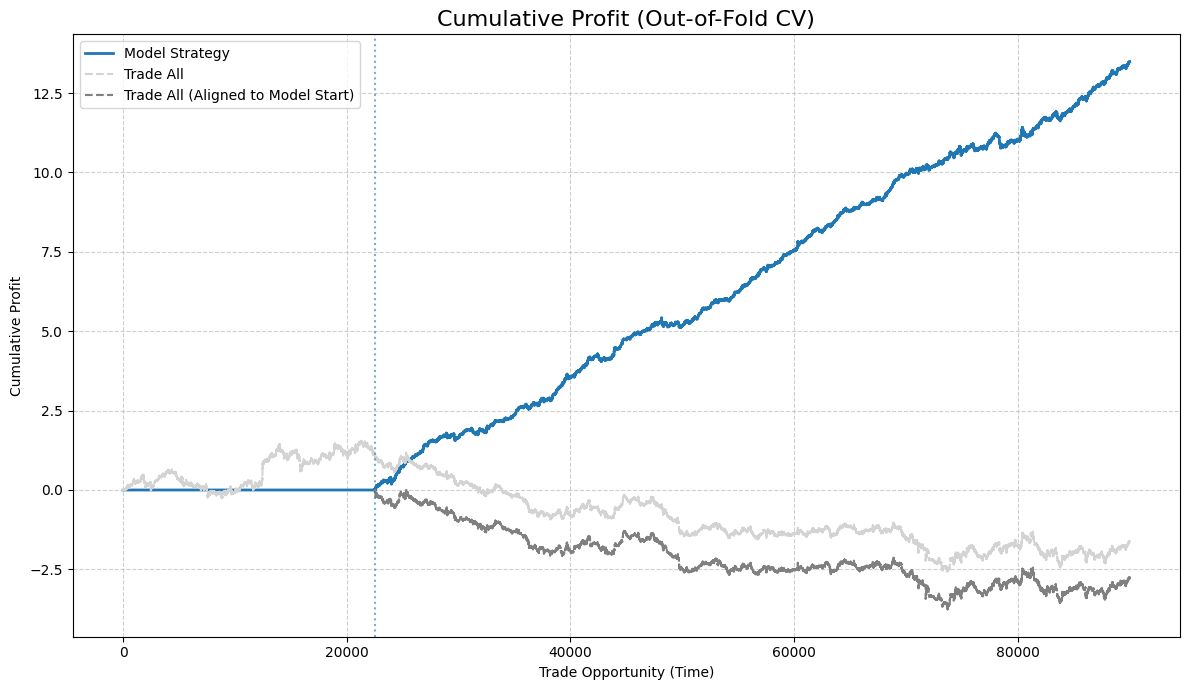

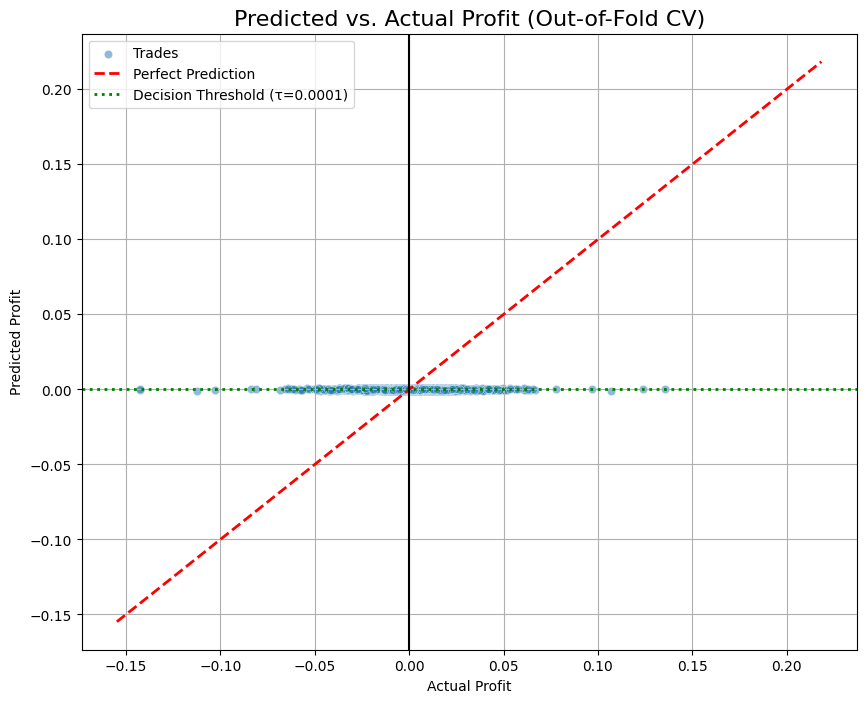

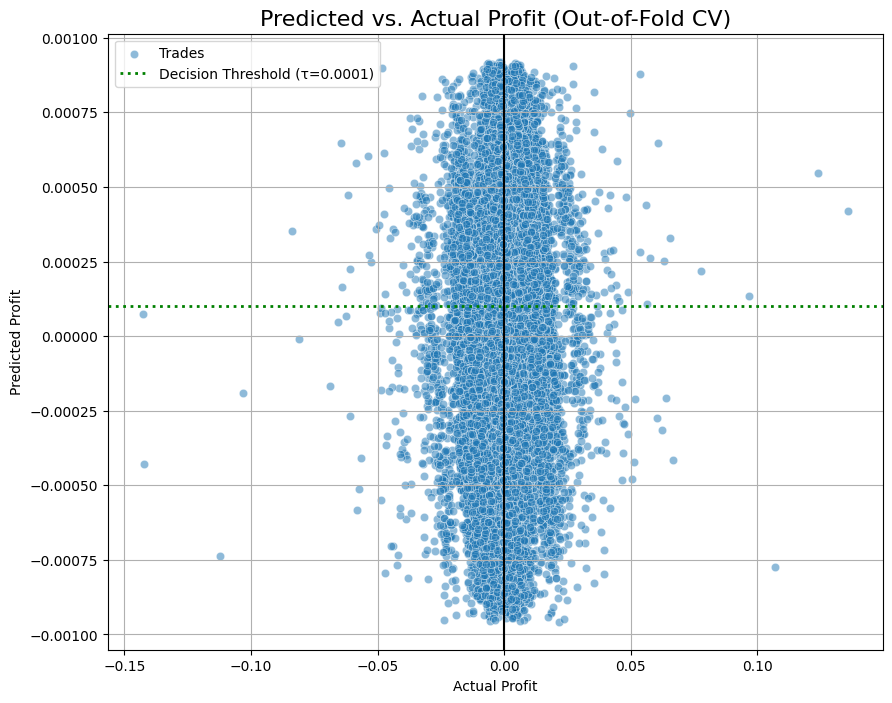

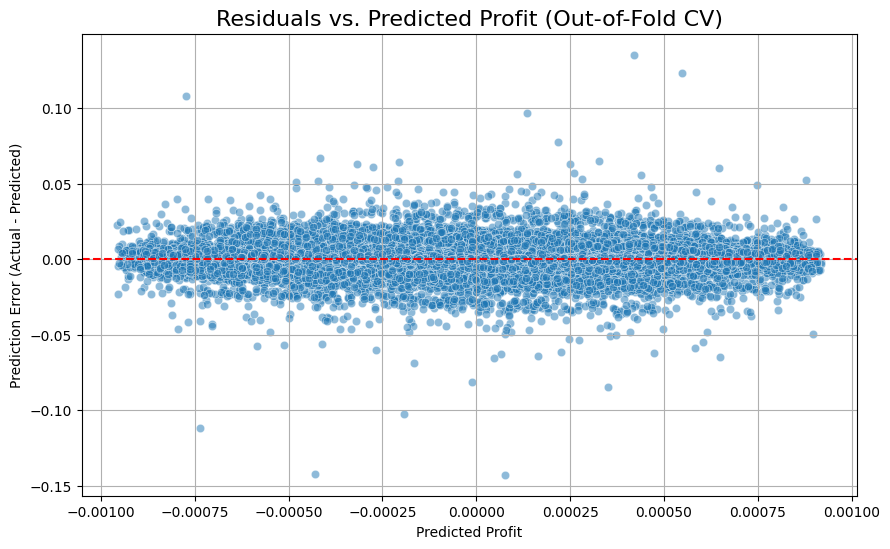

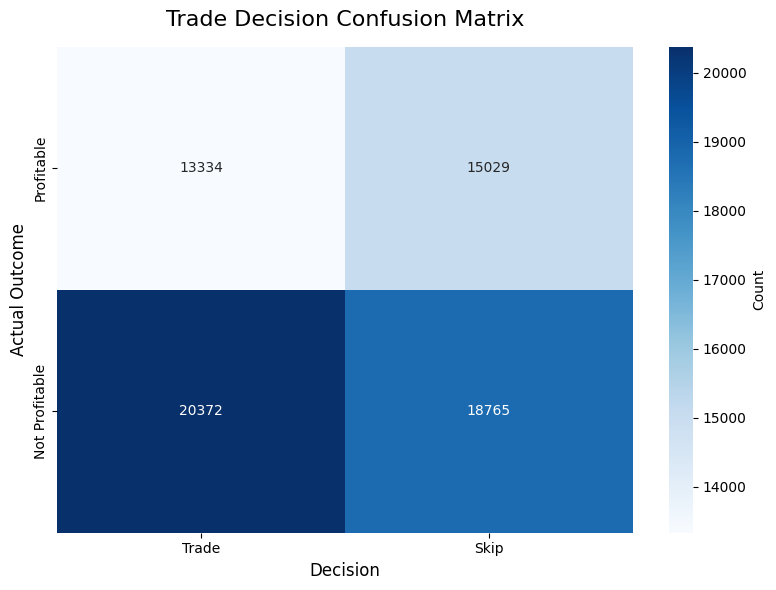

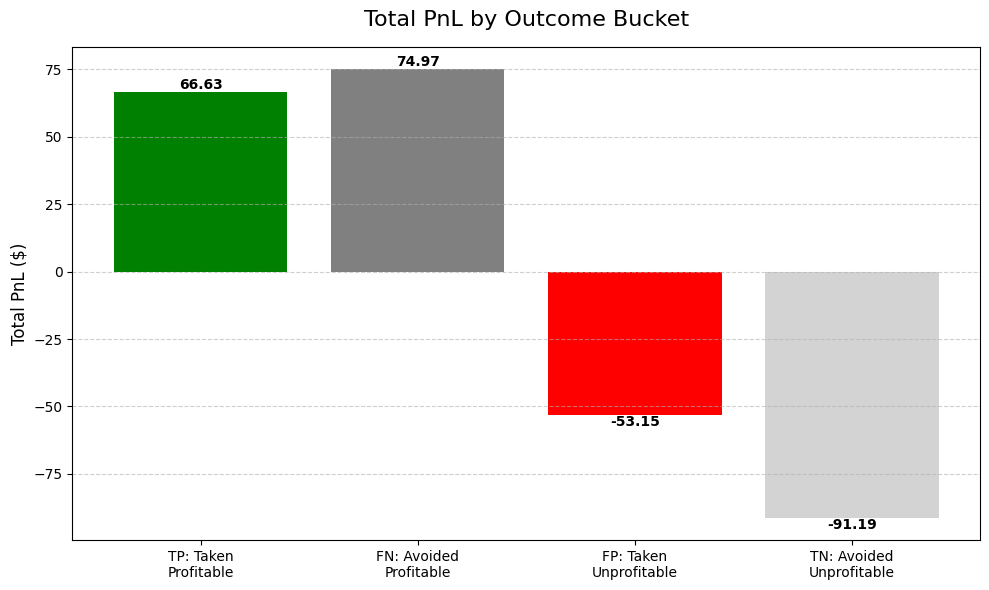

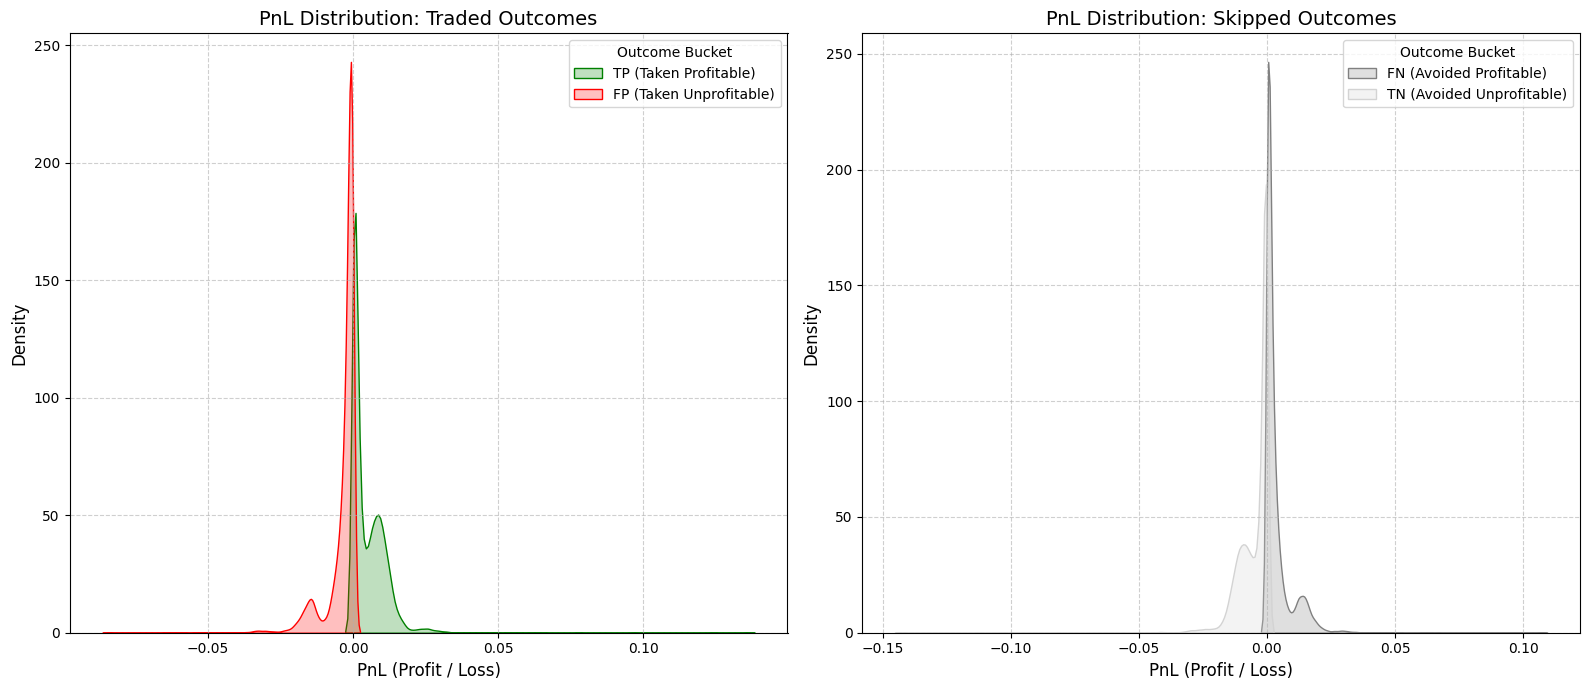

{'N': 67500,
 'Accuracy': 0.47554074074074076,
 'Precision (hit-rate)': 0.4701195219123506,
 'Recall (capture profitable)': 0.3955972230463419,
 'F1': 0.429650872416182,
 'Trade rate': 0.4201925925925926,
 'τ': 0.0001,
 'TP': 13334,
 'FP': 15029,
 'FN': 20372,
 'TN': 18765}

In [30]:
y_pred_train_val_tscv = generate_oof_predictions(training_results_baseline['best_overall_model'], X_train_val, y_train_val, TimeSeriesSplit(n_splits=3))

tau = training_results_baseline['best_overall_model'].named_steps.get('selector').tau

plot_cumulative_profit(y_train_val, y_pred_train_val_tscv, tau, title=f"Cumulative Profit (Out-of-Fold CV)")
plot_predicted_vs_actual(y_train_val, y_pred_train_val_tscv, tau, title=f"Predicted vs. Actual Profit (Out-of-Fold CV)", show_y_equals_x=True)
plot_predicted_vs_actual(y_train_val, y_pred_train_val_tscv, tau, title=f"Predicted vs. Actual Profit (Out-of-Fold CV)", show_y_equals_x=False)
plot_residuals(y_train_val, y_pred_train_val_tscv, title=f"Residuals vs. Predicted Profit (Out-of-Fold CV)")
plot_trade_decision_quality(y_train_val, y_pred_train_val_tscv, tau)

In [ ]:
joblib.dump(training_results_baseline, "training_results_baseline.pkl") # Save model and results

Note: The total profit achieved in the validation folds is (66.63 - 53.15) = 13.48.

# Model Training & Evaluation Experiments

Having verified our model training and evaluation pipeline works as expected, we now move onto our aforementioned tree-based models.

- To begin we consider all features.

In [ ]:
warnings.filterwarnings('ignore')

FEATURES_TO_USE = FEATURE_COLS
                           
MODELS = {
    "Elastic Net": Pipeline([
        ('selector', SelectionHyperparams()),
        ('scaler', StandardScaler()), 
        ('regressor', ElasticNet(random_state=42, max_iter=2000))
    ]),
    "LightGBM": Pipeline([
        ('selector', SelectionHyperparams()),
        ('scaler', StandardScaler()),
        ('regressor', lgb.LGBMRegressor(random_state=42, n_jobs=-1))
    ]),
    "XGBoost": Pipeline([
        ('selector', SelectionHyperparams()),
        ('scaler', StandardScaler()),
        ('regressor', xgb.XGBRegressor(random_state=42, n_jobs=-1))
    ]),
    "CatBoost": Pipeline([
        ('selector', SelectionHyperparams()),
        ('scaler', StandardScaler()),
        ('regressor', cb.CatBoostRegressor(random_state=42, verbose=0))
    ]),
}

TAU_GRID = [0, 1e-4, 1e-3]

PARAM_GRIDS = {
    "Elastic Net": {
        'selector__tau': TAU_GRID,
        'regressor__alpha': np.logspace(-4, 1, 6),  # Lambda (regularization strength)
        'regressor__l1_ratio': [0.1, 0.5, 0.7, 0.9, 0.95, 1.0] # Mix between L1 and L2
    },
    "Decision Tree": {
        'selector__tau': TAU_GRID,
        'regressor__max_depth': [5, 10, 15], 
        'regressor__min_samples_leaf': [10, 20, 30], 
        'regressor__min_samples_split': [i for i in range(2, 10+1, 2)]
    },
    "Random Forest": {
        'selector__tau': TAU_GRID,
        'regressor__n_estimators': [100, 300],
        'regressor__max_depth': [5, 10, 15],
        'regressor__min_samples_leaf': [10, 20]
    },
    "LightGBM": {
        'selector__tau': TAU_GRID,
        'regressor__n_estimators': [100, 300],
        'regressor__learning_rate': [0.01, 0.05, 0.1],
        'regressor__num_leaves': [20, 31, 40],
        'regressor__subsample': [0.7, 0.9, 1.0],
        'regressor__colsample_bytree': [0.7, 0.9] # Feature fraction
    },
    "XGBoost": {
        'selector__tau': TAU_GRID,
        'regressor__n_estimators': [100, 300],
        'regressor__learning_rate': [0.01, 0.05, 0.1],
        'regressor__max_depth': [3, 5, 7],
        'regressor__subsample': [0.7, 0.9, 1.0],      # Subsample ratio of the training instance
        'regressor__colsample_bytree': [0.7, 0.9]
    },
    "CatBoost": {
        'selector__tau': TAU_GRID,
        'regressor__iterations': [100, 300],  # CatBoost uses 'iterations' instead of 'n_estimators'
        'regressor__learning_rate': [0.01, 0.05, 0.1],
        'regressor__depth': [3, 5, 7],  # CatBoost uses 'depth' instead of 'max_depth'
        'regressor__colsample_bylevel': [0.7, 0.9],
        'regressor__l2_leaf_reg': [1, 3, 5],

    },
}

X_train_val = df_train_val[FEATURES_TO_USE].copy().to_numpy()
y_train_val = df_train_val[TARGET_COL].copy().to_numpy()

print(f"{X_train_val.shape=}")
print(f"{y_train_val.shape=}")

training_results_all_features = run_training_pipeline_sklearn(
    X_train_val=X_train_val,
    y_train_val=y_train_val,
    models=MODELS,
    param_grids=PARAM_GRIDS,
    score_to_use='PROFIT',
    n_splits=3,  # (432 * n_jobs) fits for tree boosting models
)

X_train_val.shape=(90000, 66)
y_train_val.shape=(90000,)
Commencing model training and hyperparameter tuning...

Performing hyperparameter tuning for model: Elastic Net
Fitting 3 folds for each of 108 candidates, totalling 324 fits
Finished tuning for Elastic Net.
Best CV PROFIT Score: 4.7734
Best Parameters: {'regressor__alpha': 0.0001, 'regressor__l1_ratio': 0.5, 'selector__tau': 0}

Performing hyperparameter tuning for model: LightGBM
Fitting 3 folds for each of 324 candidates, totalling 972 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005331 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13427
[LightGBM] [Info] Number of data points in the train set: 22500, number of used features: 66
[LightGBM] [Info] Start training from score 0.000051
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004692 seconds.
You can set `force_col_wise=true` to remove the 

- The "optimal" model is actually slightly unclear here, due to the size of the stds across the folds, as well as possible consideration related to fitting times. In any case, in the interest of time, we crudely take the `LightGBM` model as "optimal" here, although I would with more time give this more consideration.

Generating Out-of-Fold predictions...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006544 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13427
[LightGBM] [Info] Number of data points in the train set: 22500, number of used features: 66
[LightGBM] [Info] Start training from score 0.000051
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003188 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13492
[LightGBM] [Info] Number of data points in the train set: 45000, number of used features: 66
[LightGBM] [Info] Start training from score -0.000006
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004020 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13543
[LightGBM] [Info] Number of data points in the train set: 67500, number of use

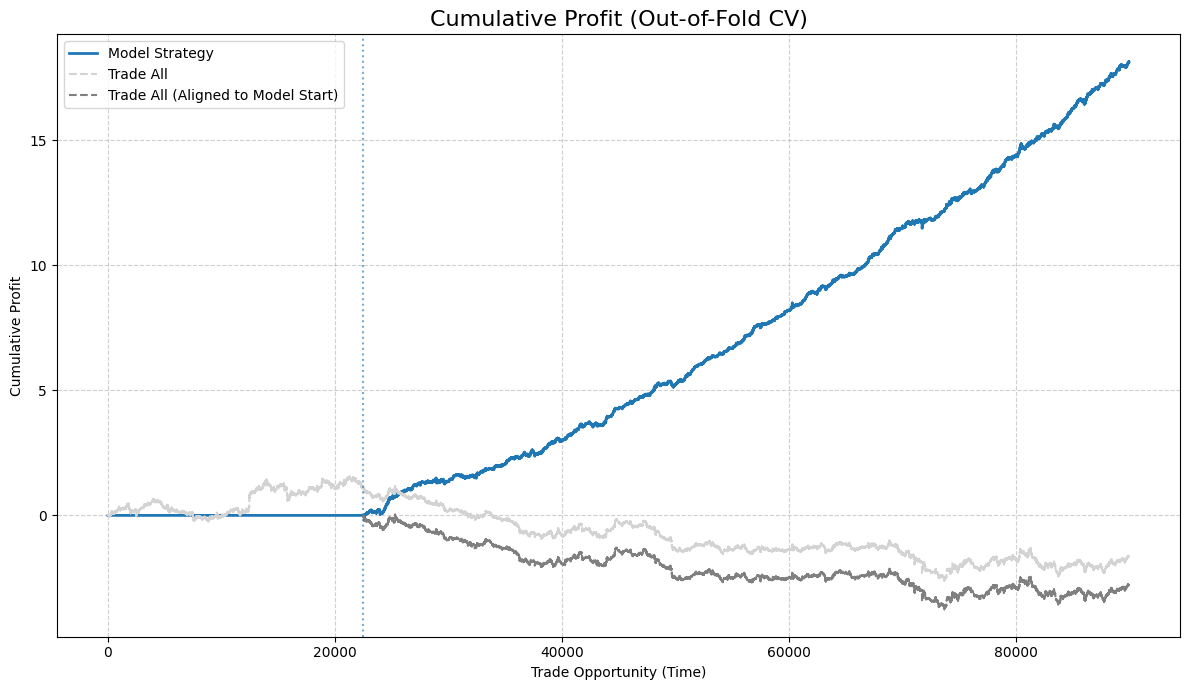

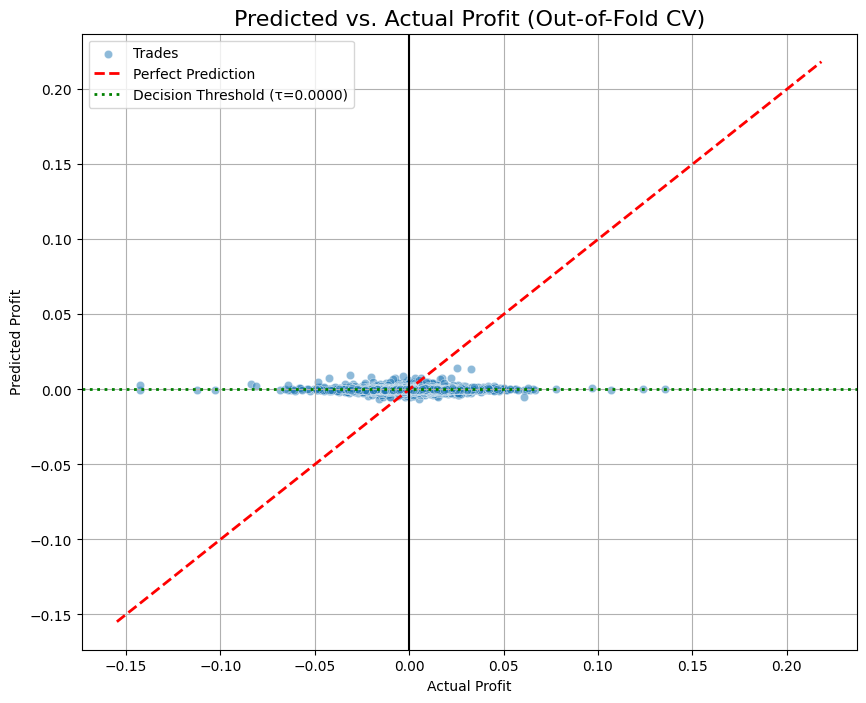

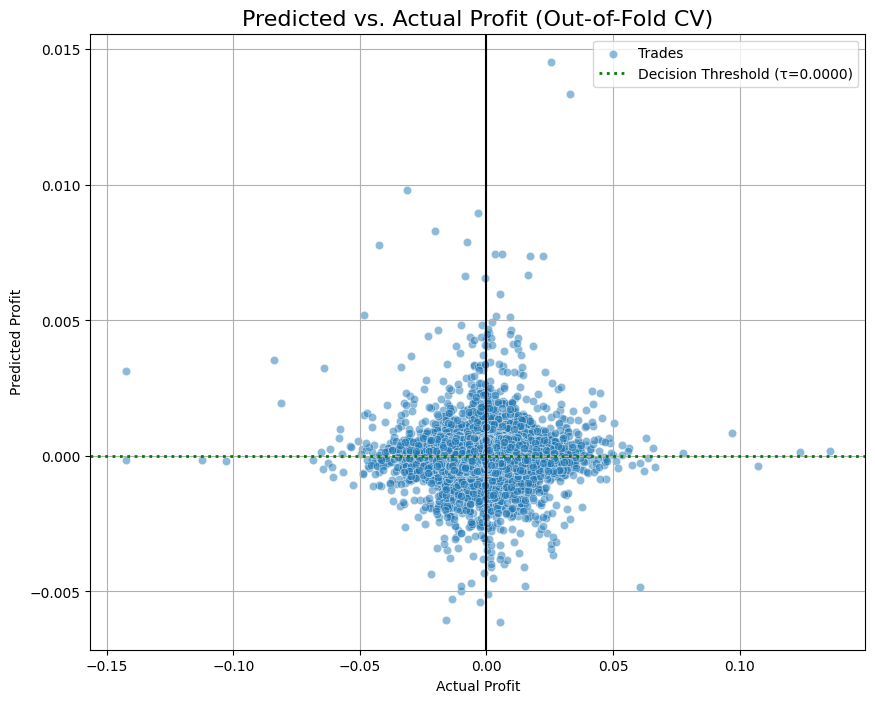

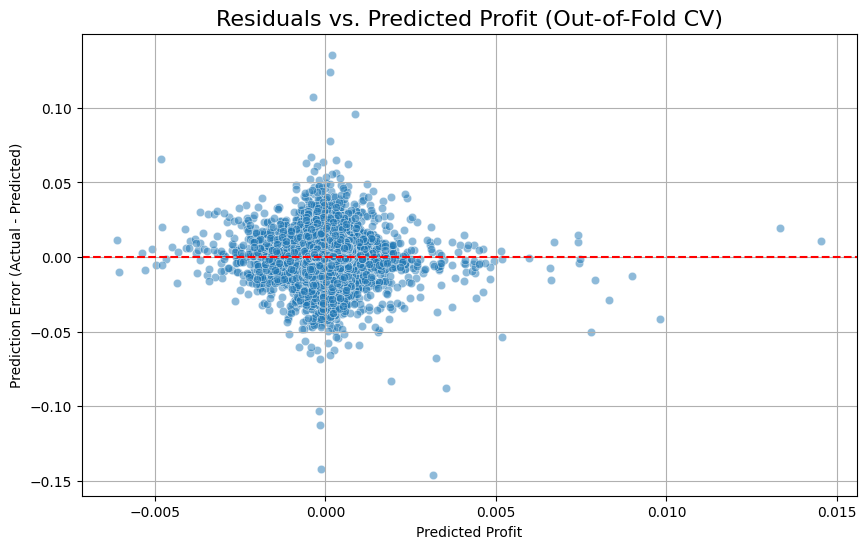

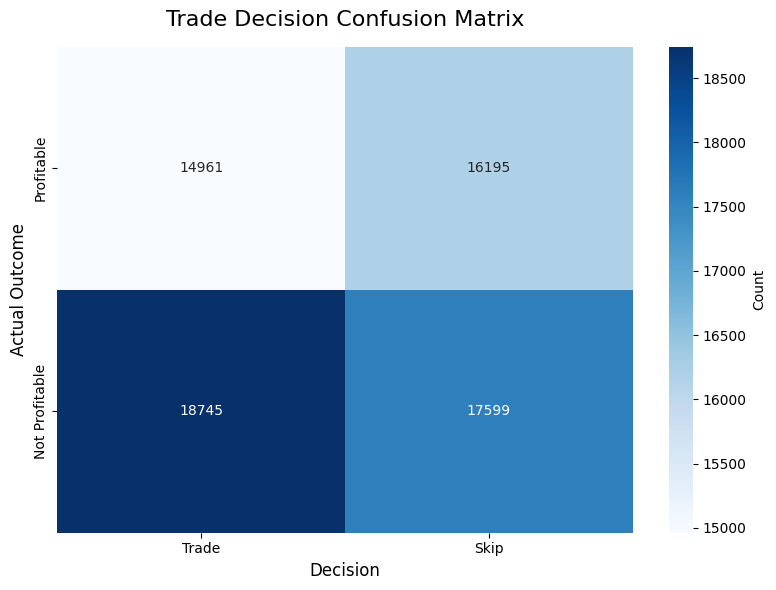

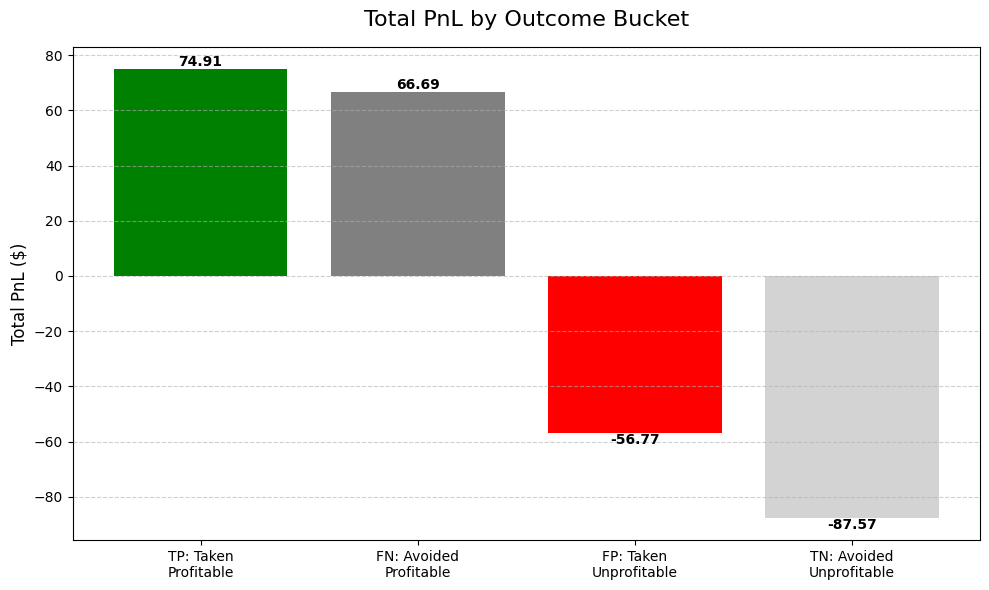

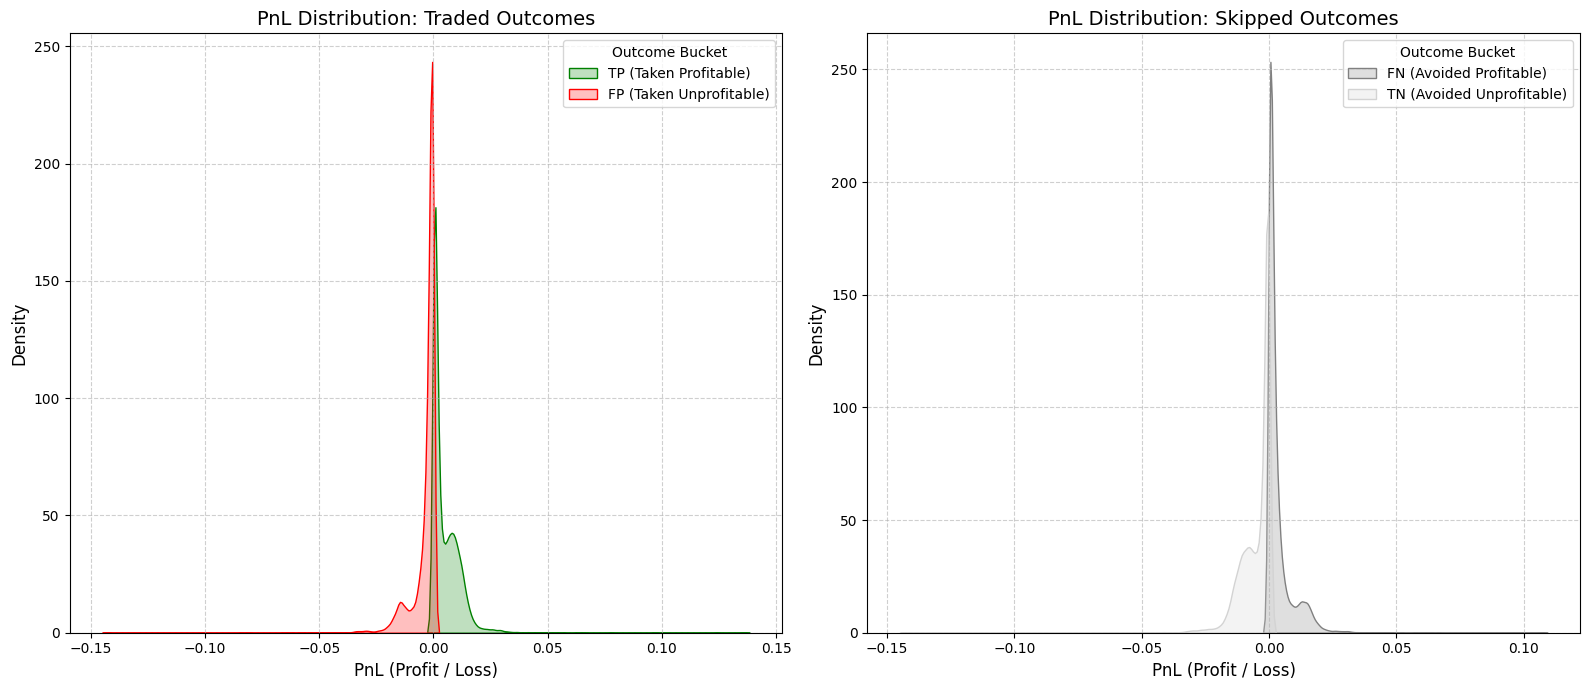

{'N': 67500,
 'Accuracy': 0.4823703703703704,
 'Precision (hit-rate)': 0.480196430864039,
 'Recall (capture profitable)': 0.4438675606716905,
 'F1': 0.4613178748728069,
 'Trade rate': 0.46157037037037035,
 'τ': 0.0,
 'TP': 14961,
 'FP': 16195,
 'FN': 18745,
 'TN': 17599}

In [33]:
y_pred_train_val_tscv = generate_oof_predictions(training_results_all_features['best_overall_model'], X_train_val, y_train_val, TimeSeriesSplit(n_splits=3))

tau = training_results_all_features['best_overall_model'].named_steps.get('selector').tau

plot_cumulative_profit(y_train_val, y_pred_train_val_tscv, tau, title=f"Cumulative Profit (Out-of-Fold CV)")
plot_predicted_vs_actual(y_train_val, y_pred_train_val_tscv, tau, title=f"Predicted vs. Actual Profit (Out-of-Fold CV)", show_y_equals_x=True)
plot_predicted_vs_actual(y_train_val, y_pred_train_val_tscv, tau, title=f"Predicted vs. Actual Profit (Out-of-Fold CV)", show_y_equals_x=False)
plot_residuals(y_train_val, y_pred_train_val_tscv, title=f"Residuals vs. Predicted Profit (Out-of-Fold CV)")
plot_trade_decision_quality(y_train_val, y_pred_train_val_tscv, tau)

In [ ]:
joblib.dump(training_results_all_features, "training_results_all_features.pkl") # Save model and results

['training_results_all_features.pkl']

- Note: The total profit achieved in the validation folds is (74.91 - 56.77) = 18.14.

- To explore whether removing redundant features improves model performance, we re-train the tree-based models, with only the top 10 most important features as determined by the `LightGBM` model just trained.

Feature importances based on 'gain':
   feature  importance
4        4         219
6        6         175
10      10         160
0        0         153
12      12         125
..     ...         ...
38      38          11
19      19          10
15      15          10
18      18           9
16      16           5

[66 rows x 2 columns]


<Axes: title={'center': 'LightGBM Feature Importance (Gain)'}, xlabel='Feature importance', ylabel='Features'>

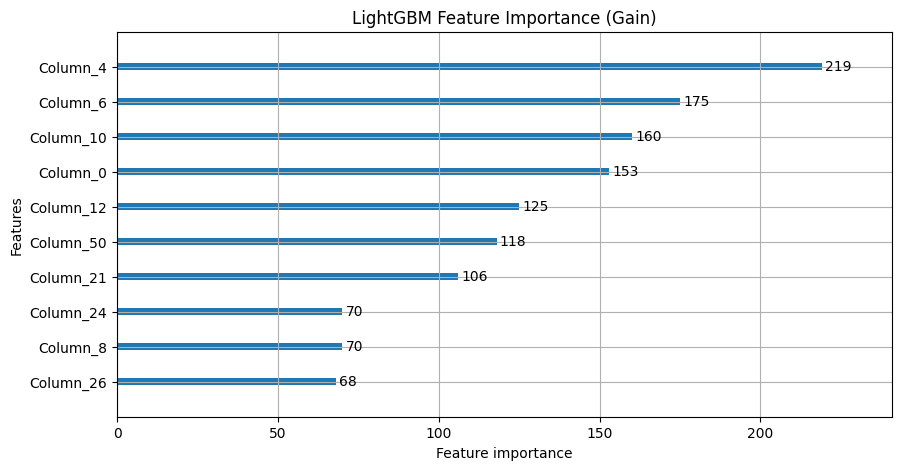

In [37]:
feature_importances = pd.DataFrame({
    'feature': df_train_val[FEATURE_COLS].columns,
    'importance': training_results_all_features['best_overall_model'].named_steps.get('regressor').feature_importances_
}).sort_values('importance', ascending=False)

print("Feature importances based on 'gain':")
print(feature_importances)

lgb.plot_importance(training_results_all_features['best_overall_model'].named_steps.get('regressor'), max_num_features=10, figsize=(10, 5), title='LightGBM Feature Importance (Gain)')

#### Re-running training for best model with Top 10 most important features

In [38]:
warnings.filterwarnings('ignore')

FEATURES_TO_USE = ['4', '6', '10', '0', '12', '50', '21', '24', '8', '26']
                           
MODELS = {
    "LightGBM": Pipeline([
        ('selector', SelectionHyperparams()),
        ('scaler', StandardScaler()),
        ('regressor', lgb.LGBMRegressor(random_state=42, n_jobs=-1))
    ]),
    "XGBoost": Pipeline([
        ('selector', SelectionHyperparams()),
        ('scaler', StandardScaler()),
        ('regressor', xgb.XGBRegressor(random_state=42, n_jobs=-1))
    ]),
    "CatBoost": Pipeline([
        ('selector', SelectionHyperparams()),
        ('scaler', StandardScaler()),
        ('regressor', cb.CatBoostRegressor(random_state=42, verbose=0))
    ]),
}

X_train_val = df_train_val[FEATURES_TO_USE].copy().to_numpy()
y_train_val = df_train_val[TARGET_COL].copy().to_numpy()

print(f"{X_train_val.shape=}")
print(f"{y_train_val.shape=}")

training_results_subset_features = run_training_pipeline_sklearn(
    X_train_val=X_train_val,
    y_train_val=y_train_val,
    models=MODELS,
    param_grids=PARAM_GRIDS,
    score_to_use='PROFIT',
    n_splits=3,  # (432 * n_jobs) fits for tree boosting models
)

X_train_val.shape=(90000, 10)
y_train_val.shape=(90000,)
Commencing model training and hyperparameter tuning...

Performing hyperparameter tuning for model: LightGBM
Fitting 3 folds for each of 324 candidates, totalling 972 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006778 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2090
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011531 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2090
[LightGBM] [Info] Number of data points in the train set: 22500, number of used features: 10[LightGBM] [Info] Number of data points in the train set: 22500, number of used features: 10

[LightGBM] [Info] Start training from score 0.000051
[LightGBM] [Info] Start training from score 0.000051
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0

Generating Out-of-Fold predictions...
OOF predictions generated successfully.


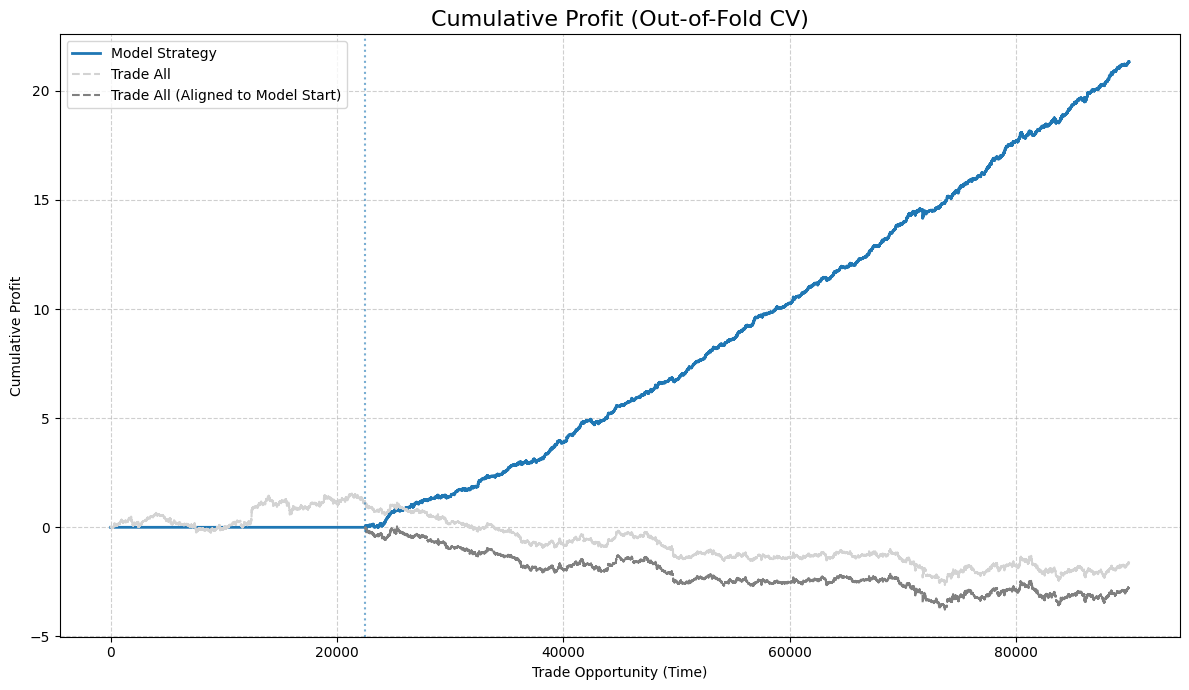

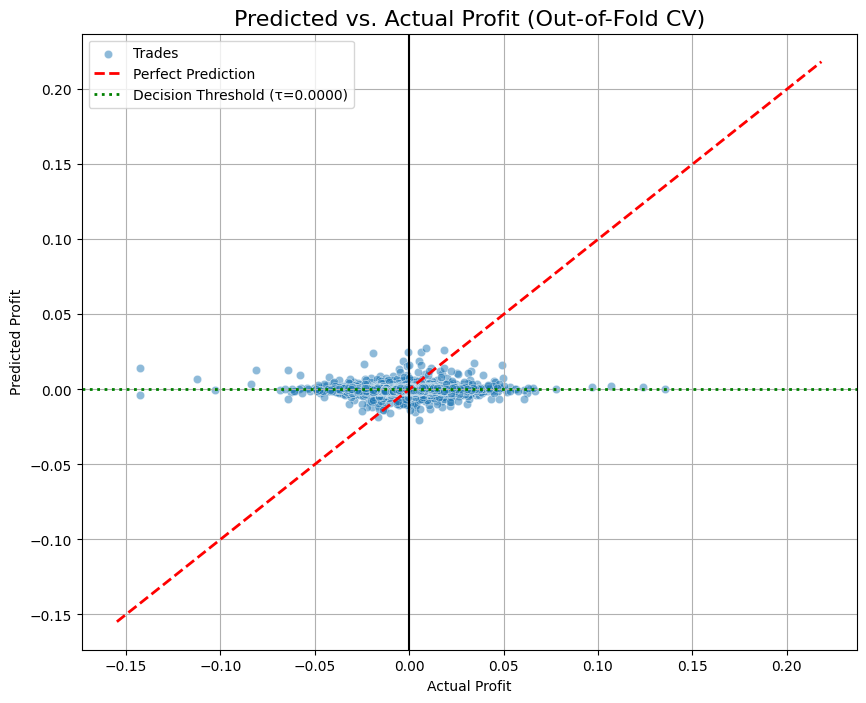

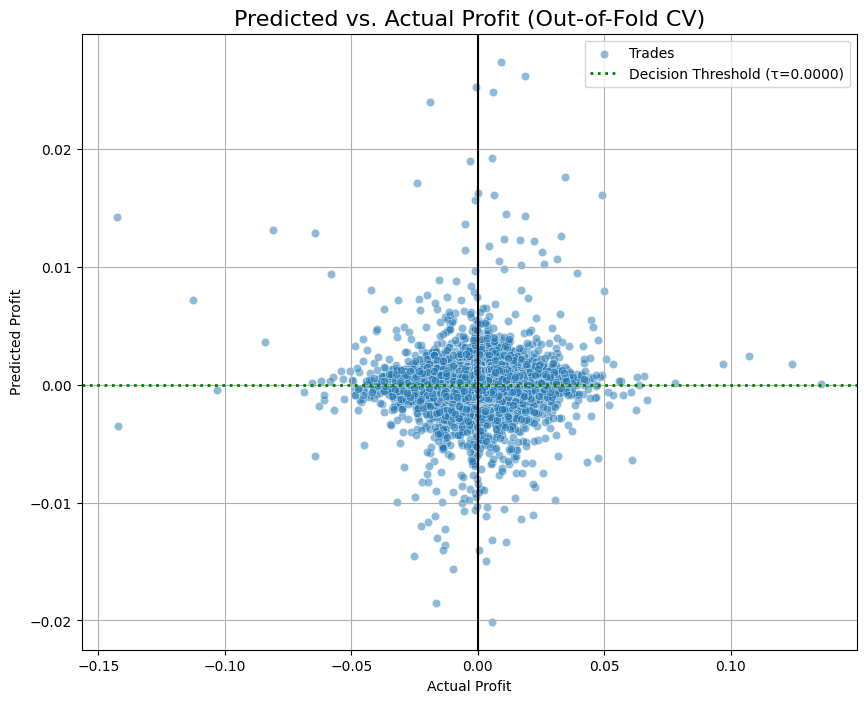

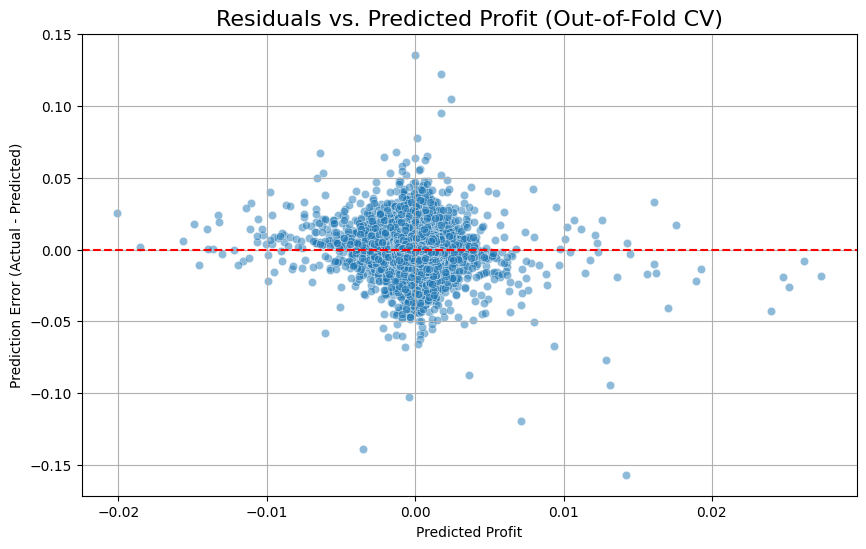

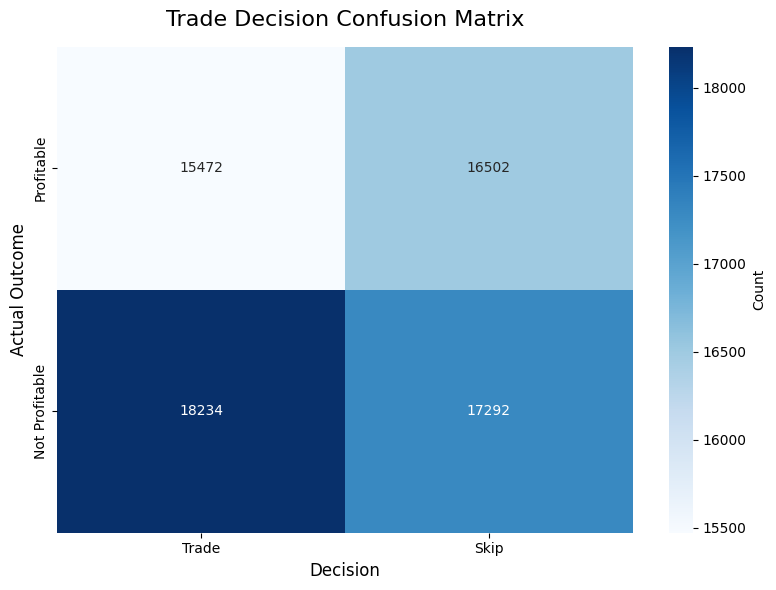

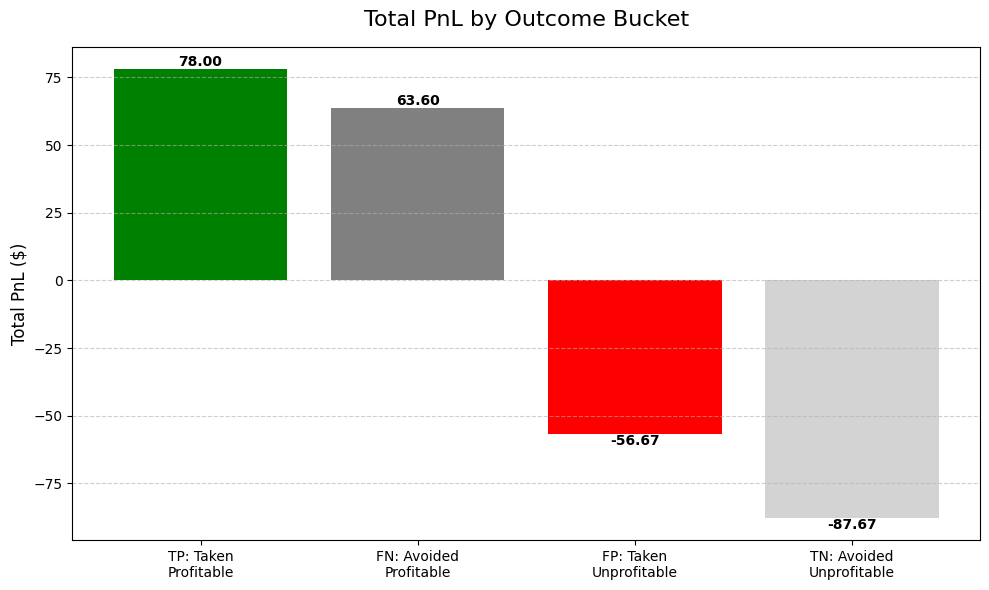

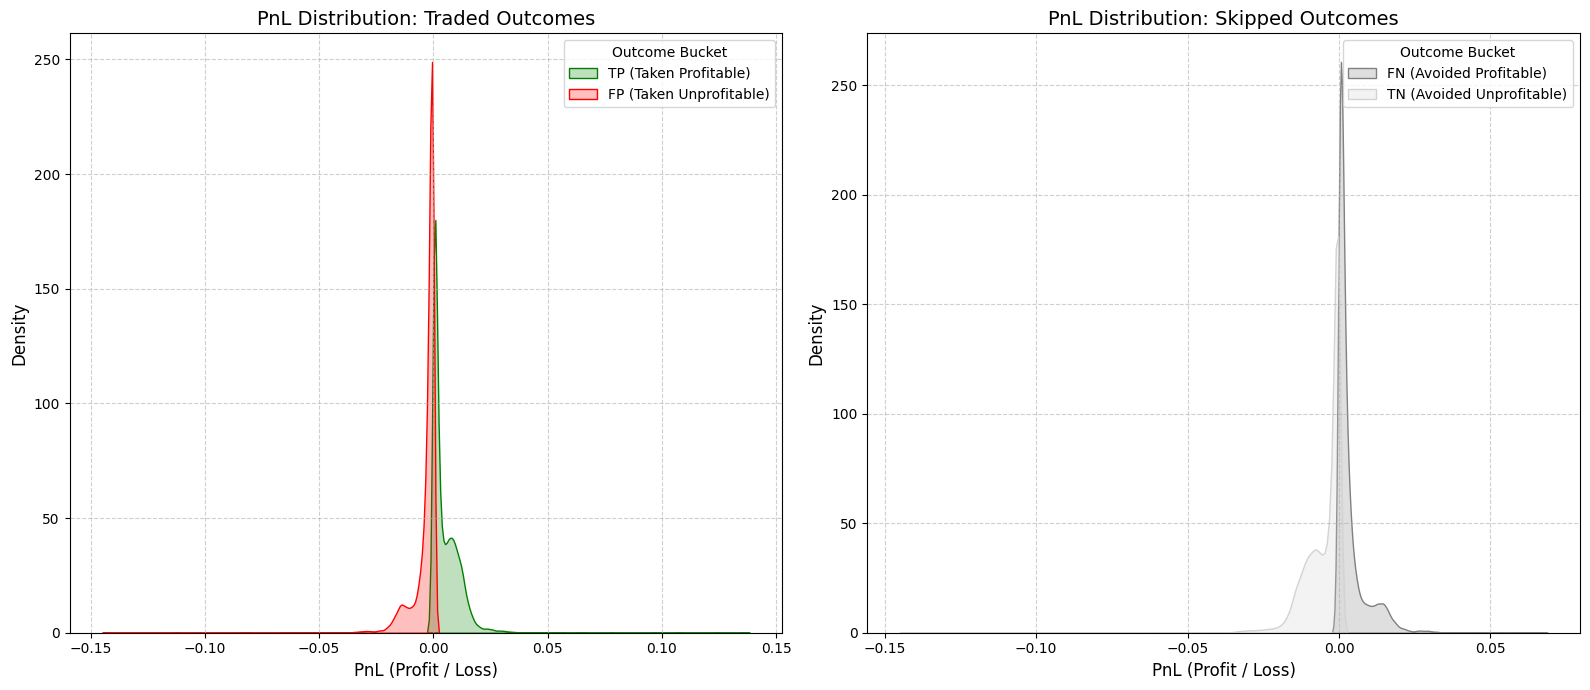

{'N': 67500,
 'Accuracy': 0.4853925925925926,
 'Precision (hit-rate)': 0.483893163195096,
 'Recall (capture profitable)': 0.45902806621966413,
 'F1': 0.47113276492082823,
 'Trade rate': 0.4736888888888889,
 'τ': 0.0,
 'TP': 15472,
 'FP': 16502,
 'FN': 18234,
 'TN': 17292}

In [42]:
y_pred_train_val_tscv = generate_oof_predictions(training_results_subset_features['best_overall_model'], X_train_val, y_train_val, TimeSeriesSplit(n_splits=3))

tau = training_results_subset_features['best_overall_model'].named_steps.get('selector').tau

plot_cumulative_profit(y_train_val, y_pred_train_val_tscv, tau, title=f"Cumulative Profit (Out-of-Fold CV)")
plot_predicted_vs_actual(y_train_val, y_pred_train_val_tscv, tau, title=f"Predicted vs. Actual Profit (Out-of-Fold CV)", show_y_equals_x=True)
plot_predicted_vs_actual(y_train_val, y_pred_train_val_tscv, tau, title=f"Predicted vs. Actual Profit (Out-of-Fold CV)", show_y_equals_x=False)
plot_residuals(y_train_val, y_pred_train_val_tscv, title=f"Residuals vs. Predicted Profit (Out-of-Fold CV)")
plot_trade_decision_quality(y_train_val, y_pred_train_val_tscv, tau)

Note, we have improved the total profit obtained across the validation folds via this feature selection approach!

# PyTorch Framework

Below we show a sketch of how to implement training and validation of a `LSTM` model. 

**To be clear, the code to achieve this can be found within the `pytorch_lightning_pipeline.ipynb` notebook!**

- Please note the above was implemented while the above models were training, and with time many improvements can certainly be made!

### Approach Overview:

- Load $\mathcal{D}_{train,val}$ and only keep the features as determined by our LightGBM model (i.e. top 10 most important features).

- Build the `torch.Dataset` such that sequences of $K=100$ snapshot are utilised for a given sample.

- Define a very simple grid of hyperparameters to tune over for our `LSTM` model. 

- For each combination, we again utilise Walk Forward Cross Validation to train and validate the model.
    - To be clear, the `"PROFIT"` is again used as the metric to select hyperparameters.
    - For each split, we perform backpropagation for 20 epochs, with a batch soize of 64 and a patience of 5. **Notably we define a differentiably proxy of the `"PROFIT"` metric to perform weight updates!** (See: `ProfitMaximizingLoss`)

- Having trained and validated, we generate Out of Fold predictions in a consistent manner to the above, and again visulaise these!

*Note: The model was explicitly trained (and validated) within a Google Colab Notebook using a T4 GPU.*

**Crucially, the Out of Fold total profit obtained is less than that of our `CatBoost` model, and so we leave the `LSTM` model for now.**

- The referenced notebook serves as a platform to deep learning models, however!

# Holdout Test Set Evaluation

Having completed our model training, we select only our best performing model to then evaluate on the holdout test set, $\mathcal{D}_{test}$. 

To be clear, this is the `CatBoost` model with selected hyperparameters: 
```
    {
        'regressor__colsample_bylevel': 0.9, 
        'regressor__depth': 7, 
        'regressor__iterations': 100, 
        'regressor__l2_leaf_reg': 1, 
        'regressor__learning_rate': 0.1, 
        'selector__tau': 0
    }
```

Note that by default `CatBoost` has `subsample=0.8` (due to dataset size and bootstrap type, as outlined here: https://catboost.ai/docs/en/references/training-parameters/common#subsample), which we verify below.

In [49]:
training_results_subset_features['best_overall_model'].named_steps.get('regressor').get_all_params()

{'nan_mode': 'Min',
 'eval_metric': 'RMSE',
 'iterations': 100,
 'sampling_frequency': 'PerTree',
 'leaf_estimation_method': 'Newton',
 'random_score_type': 'NormalWithModelSizeDecrease',
 'grow_policy': 'SymmetricTree',
 'penalties_coefficient': 1,
 'boosting_type': 'Plain',
 'model_shrink_mode': 'Constant',
 'feature_border_type': 'GreedyLogSum',
 'bayesian_matrix_reg': 0.10000000149011612,
 'eval_fraction': 0,
 'force_unit_auto_pair_weights': False,
 'l2_leaf_reg': 1,
 'random_strength': 1,
 'rsm': 0.8999999761581421,
 'boost_from_average': True,
 'model_size_reg': 0.5,
 'pool_metainfo_options': {'tags': {}},
 'subsample': 0.800000011920929,
 'use_best_model': False,
 'random_seed': 42,
 'depth': 7,
 'posterior_sampling': False,
 'border_count': 254,
 'classes_count': 0,
 'auto_class_weights': 'None',
 'sparse_features_conflict_fraction': 0,
 'leaf_estimation_backtracking': 'AnyImprovement',
 'best_model_min_trees': 1,
 'model_shrink_rate': 0,
 'min_data_in_leaf': 1,
 'loss_function

To be clear, we refit our model on the entirety of $\mathcal{D}_{train,val}$.

X_test.shape=(19707, 10)
y_test.shape=(19707,)

Evaluating Best Model on $\mathcal{D}_{test}$


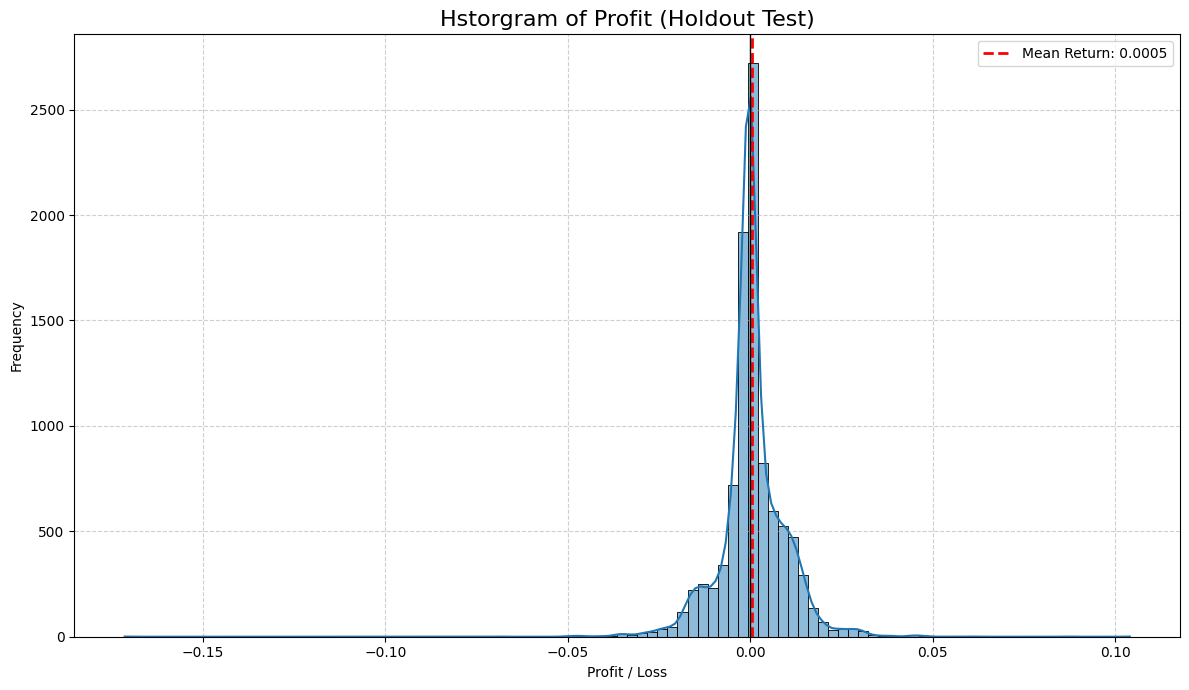

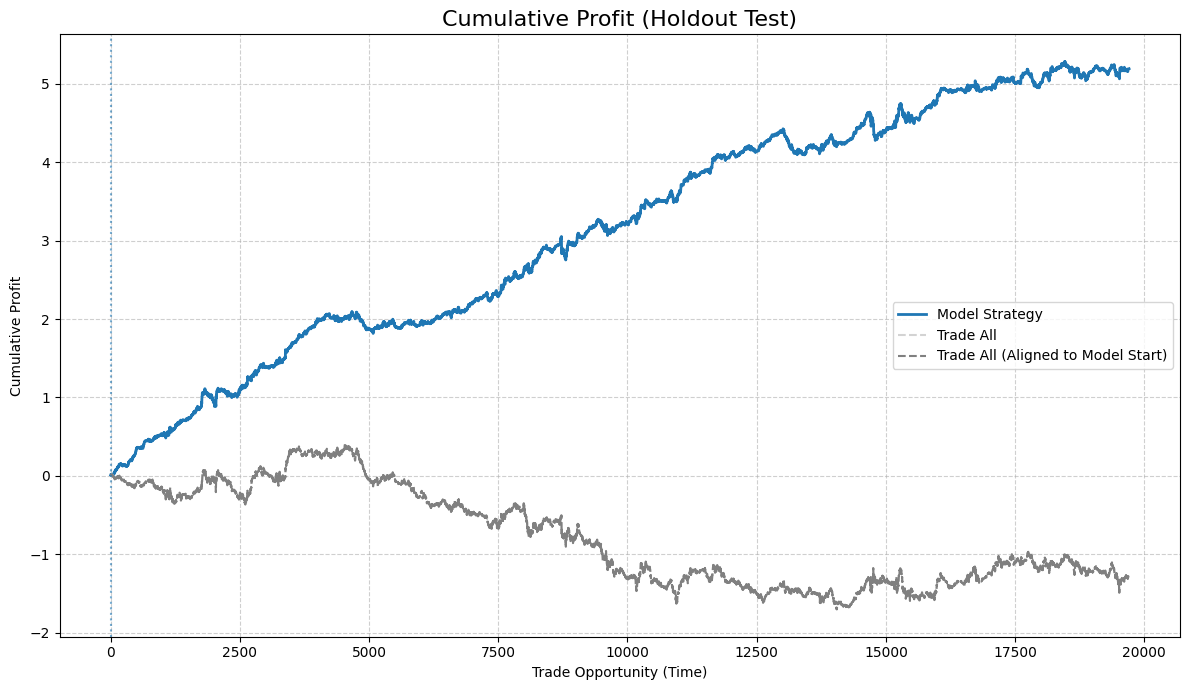

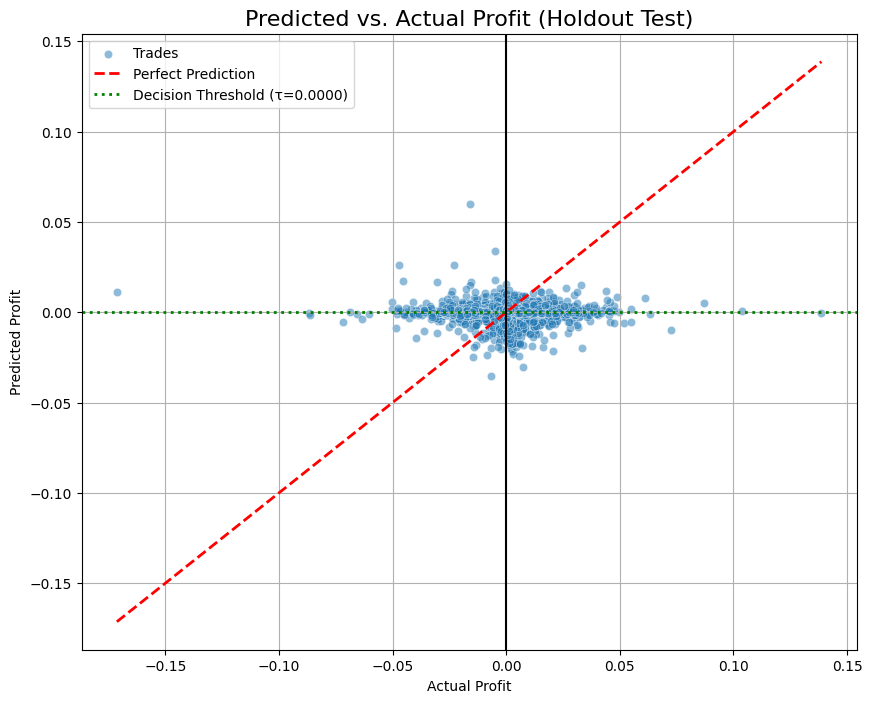

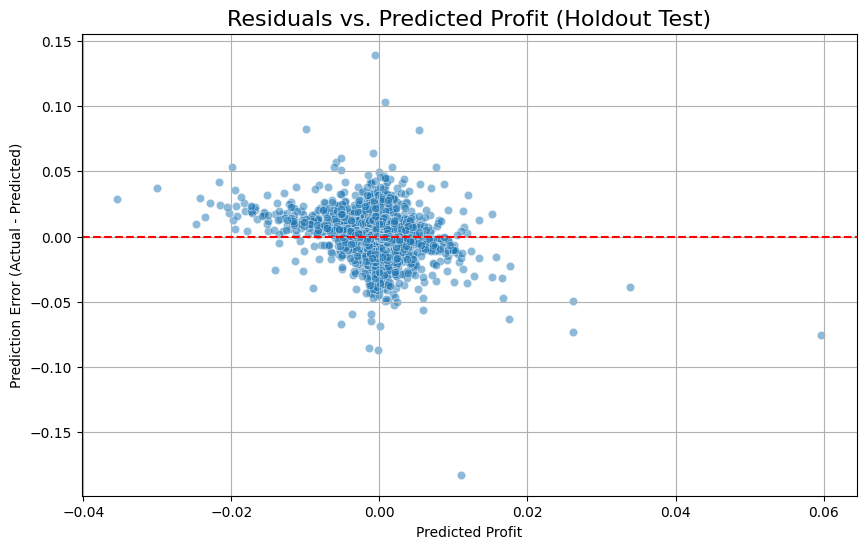

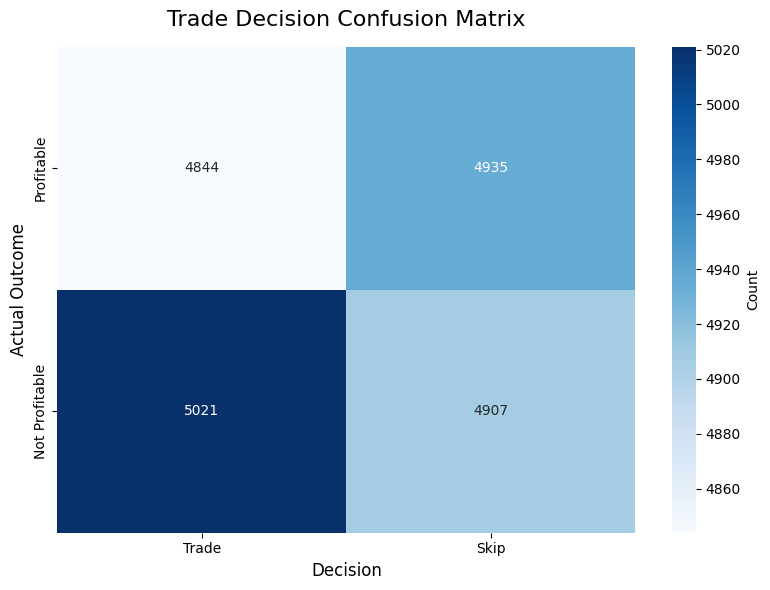

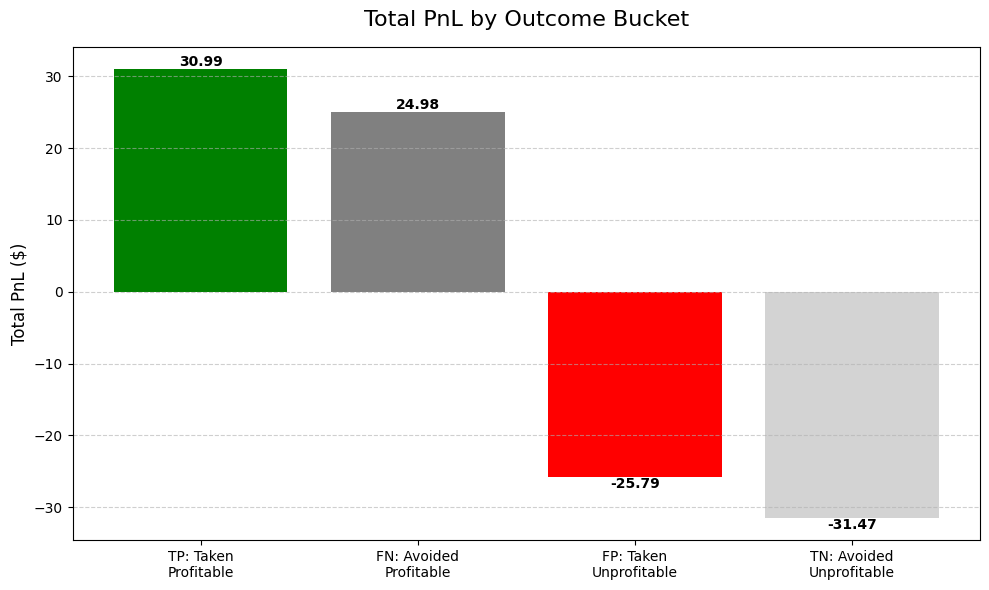

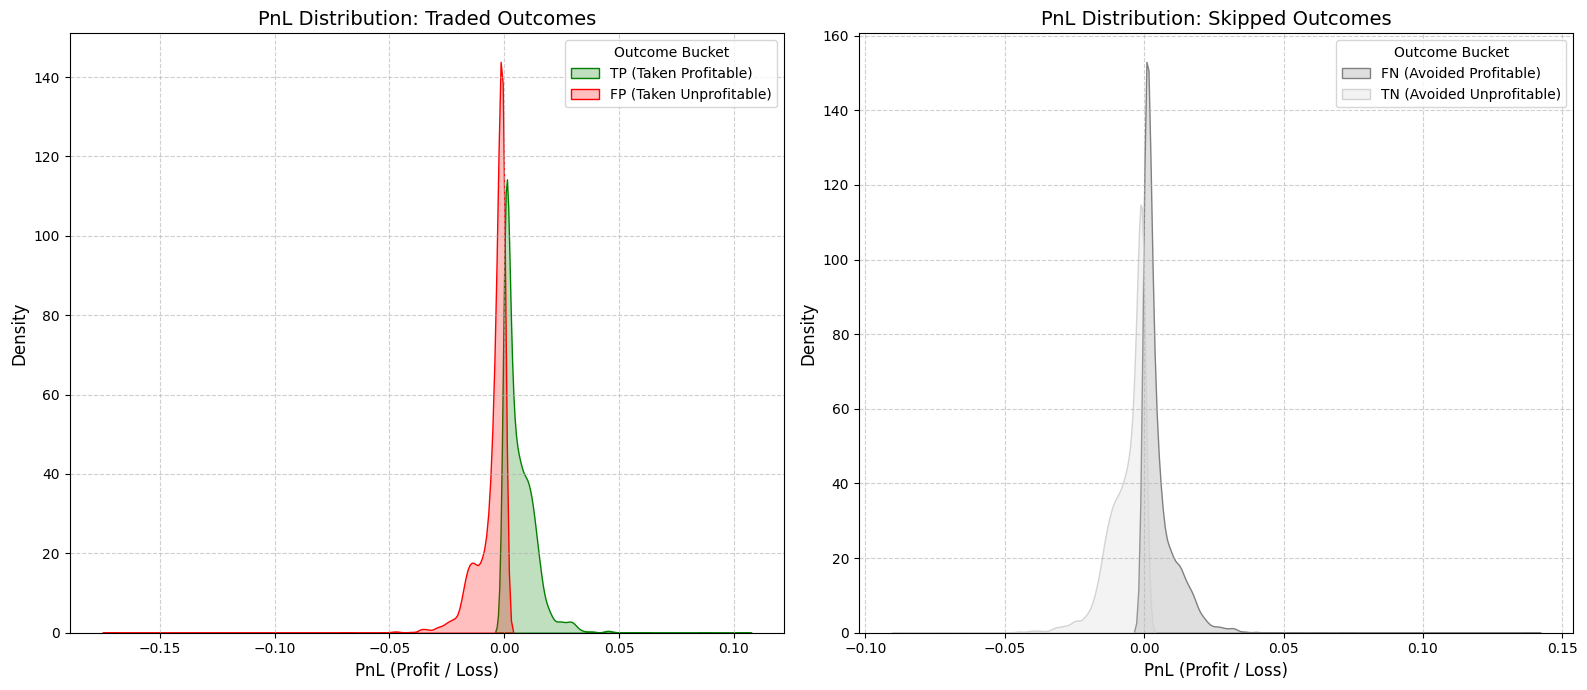

{'N': 19707,
 'Accuracy': 0.4947988024559801,
 'Precision (hit-rate)': 0.49534717251252686,
 'Recall (capture profitable)': 0.4910288900152053,
 'F1': 0.49317857870087556,
 'Trade rate': 0.49621961739483433,
 'τ': 0.0,
 'TP': 4844,
 'FP': 4935,
 'FN': 5021,
 'TN': 4907}

In [44]:
# Load \mathcal{D}_{test}
df_test = pd.read_csv('Project_test.csv', index_col=0)

# Select the correct model to evaluate on \mathcal{D}_{test}
training_results_for_holdout_test = training_results_subset_features

# Ensure columns used match that of trained model
cols_to_use = ['4', '6', '10', '0', '12', '50', '21', '24', '8', '26']

# Get \mathcal{D}_{train,val} to fit model on
X_train_val = df_train_val[cols_to_use].copy().to_numpy()
y_train_val = df_train_val[TARGET_COL].copy().to_numpy()

# Get \mathcal{D}_{test} to evaluate model on
X_test = df_test[cols_to_use].copy().to_numpy()
y_test = df_test[TARGET_COL].copy().to_numpy()

print(f"{X_test.shape=}")
print(f"{y_test.shape=}")

print("\nEvaluating Best Model on $\mathcal{D}_{test}$")

training_results_for_holdout_test['best_overall_model'].fit(X_train_val, y_train_val)

y_pred_test = training_results_for_holdout_test['best_overall_model'].predict(X_test)

tau = training_results_for_holdout_test['best_overall_model'].named_steps.get('selector').tau

plot_return_histogram(y_test, y_pred_test, tau, title=f"Hstorgram of Profit (Holdout Test)")
plot_cumulative_profit(y_test, y_pred_test, tau, title=f"Cumulative Profit (Holdout Test)")
plot_predicted_vs_actual(y_test, y_pred_test, tau, title=f"Predicted vs. Actual Profit (Holdout Test)")
plot_residuals(y_test, y_pred_test, title=f"Residuals vs. Predicted Profit (Holdout Test)")
plot_trade_decision_quality(y_test, y_pred_test, tau)

- We make (30.99 - 25.79) = 5.2 on the holdout test set.

# Assumptions & Limitations

Indeed, a number of assumptions and limitations of the preceeding analysis exist, which we outline at a high level below.

- No knowledge of temporal differences beteen samples.

- No knowledge of how data has been sampled. This pertains to potential subsampling, data feed issues and data augmentation. The lack of knowledge as to what features explitclty mean has consequences related to interetability and limited feature engineering.

- In practise one would expect transaction costs, latency and computation restrictions. These impact how one performs data normalisation and which models are feasible in production. 

- How we assign profit to an individual trade is a significant challenge in practise. Do we account for hedging costs, and if so how are these assigned to trades. How do we map trades to corresponding exit? Is this a first one in first one out, or last one iin first one out etc. Some asset classes, such as FX this is very complicated!

- We crucially assume the target has been aligned with the samples in the correct manner, such that the above approach does not introduce look ahead bias.

- We have not explored exploiting different market regimes, through continuous model refitting, particulalry within $\mathcal{D}_{test}$.

- Potential seasonality has not been explored.


# Findings

Having completed our model selection and evaluation, for the regression model set $\mathcal{R} = \left\{\mathcal{R}_{LGBM}, \mathcal{R}_{XGB}, \mathcal{R}_{Cat}, \mathcal{R}_{LSTM} \right\}$, where we notably leveraged a walk-forward cross validation scheme in each case, with predictions being generated in a manner consistent to that of a production-like environment, we recomend utilising $\mathcal{R}_{Cat}$, that is the `CatBoost` model, under the assumptions outlined above. Indeed, depending on the validity of these assumptions, our reccomendation could well change and thus again note the nuance involved in making such a reccomendation. 

Notably, the $\mathcal{R}_{LGBM}, \mathcal{R}_{XGB}, \mathcal{R}_{Cat}$ models were trained within an `sklearn` framework, whereas the $\mathcal{R}_{LSTM}$ model was trained within a `pytorch_lightning` one. Furthermore, the latter model took in historcial sequences of snapshots as input, whereas the former models simply take in the current snapshot.

To be clear, the model we select is the `CatBoost` model with selected hyperparameters: 
```
    {
        'regressor__colsample_bylevel': 0.9, 
        'regressor__depth': 7, 
        'regressor__iterations': 100, 
        'regressor__l2_leaf_reg': 1, 
        'regressor__learning_rate': 0.1, 
        'selector__tau': 0
    }
```

This model resulted in an observable profit, at some unknown point in time in the future, of +5.20 for $\mathcal{D}_{test}$, which note is 5.20/55.96 $\approx$ 9.30% of the maximum possible profit attainable on $\mathcal{D}_{test}$. Note that for the out of fold splits within $\mathcal{D}_{train,val}$, the maximum total profit that could be attained was $141.60$ (since we do not predict on the first $90,000 / 4 = 22,500$ samples) and since our model achieved $21.33$ within these folds, we a significant dropoff in this potential profit capture, from 15.06% to 9.30%.

As can be observed through plots generated in our evaluation pipeline (see above), despite the Accuracy, Recall and other metrics appearing no better than a coin flip, these crucially do not take into account the magnitude of the wins and losses of the respective trades. To this end, we can understand our model to strugggle to distinguish between winning and losing trades in the aggregate, but those that it does correctly identify are more profitable on average than the ones it does not. This can be explicitly verified by comparing the distributions of the TPs, FPs, TNs and FNs above.

Interestingly, this model only considers a subset of features, as derived via a `LightGBM` model in an earlier training run. We note this is likely due to the curse of dimensionality (i.e. easier to find meaningful splits) and combatting overfitting. Furthermore, we note that the selected $\tau$ is zero, as we would hope for an unbiased model. 

Ideally, we would like to explicitly understand the features and verify the quality of data, since this is an issue we discovered earlier for a subset of features investigated!

# Future Work

- Permutation Feature Importance

- Continuous Model Refitting on $\mathcal{D}_{test}$

- Optuna & MLflow/wandb

- Alternative Data Normalisation Methods (e.g. pinning to last snapshot in sequence etc -> inference consequences)

- Handcrafted Features

- Temporal Information 

- Exploring more (deep learning) Models

- Exploring Classifiction Models

- Alternative Data Streams (e.g. correlated instruments)

- Addressing (potential) Seasonality

# Appendix

The below can be run to verify assumptions of Linear Regression (Please note the following is lifted in parts, and inspired by: https://jeffmacaluso.github.io/post/LinearRegressionAssumptions/)

In [21]:
### Utility Functions ###

def remove_outliers(df: pd.DataFrame, column: str, tolerance: float = 1.5) -> pd.DataFrame:
    """
    Removes outliers from the passed `df` based on the interquartile range (IQR) of 
    the specified `column`.

    Parameters
    ----------
    df: dataframe.DataFrame
        The pandas DataFrame from which we wish to remove outliers from.
    column: str
        The column within `df` that we wish to remove outliers from.
    tolerance: float
        The multiplier applied to the IQR to calculate whether a value is an 
        outlier or not.
    """
    initial_count = len(df)

    # Compute the IQR, as well as the upper and lower quartiles
    quartile1 = df[column].quantile(0.25)
    quartile3 = df[column].quantile(0.75)
    inter_quartile_range = quartile3 - quartile1

    # Compute upper and lower bounds for outlier detection
    lower_bound = quartile1 - (tolerance * inter_quartile_range)
    upper_bound = quartile3 + (tolerance * inter_quartile_range)
    filtered_df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

    # Remove outliers
    final_count = len(filtered_df)
    
    print(f"Removed {initial_count - final_count} rows due to outliers in {column}.")
    return filtered_df

"""
Please note the following is lifted in parts, and inspired by: https://jeffmacaluso.github.io/post/LinearRegressionAssumptions/
"""
def linear_regression_assumptions(features, label, feature_names=None, outlier_threshold: float = 5.0):
    """
    Tests a linear regression on the model to see if assumptions are being met
    """
    from sklearn.linear_model import LinearRegression
    
    if feature_names is None:
        feature_names = ['X'+str(feature+1) for feature in range(features.shape[1])]
    
    print('Fitting linear regression')

    if features.shape[0] < 100000:
        model = LinearRegression(n_jobs=-1)
    else:
        model = LinearRegression()
        
    model.fit(features, label)
    
    r2 = model.score(features, label)
    print()
    print('R^2:', r2, '\n')
    print('Coefficients')
    print('-------------------------------------')
    print('Intercept:', model.intercept_)
    
    for feature in range(len(model.coef_)):
        print('{0}: {1}'.format(feature_names[feature], model.coef_[feature]))

    print('\nPerforming linear regression assumption testing')
    
    predictions = model.predict(features)
    df_results = pd.DataFrame({'Actual': label, 'Predicted': predictions})
    df_results['Residuals'] = abs(df_results['Actual']) - abs(df_results['Predicted'])

    # Identify outliers in residuals - to remove identified outlier!
    std_residuals = df_results['Residuals'].std()
    threshold = outlier_threshold * std_residuals
    outliers = df_results[abs(df_results['Residuals']) > threshold]
    print(f'Removing {len(outliers)} outliers from residuals.')

    # Remove outliers
    df_results_filtered = df_results[abs(df_results['Residuals']) <= threshold]
    non_outliers_features = features[abs(df_results['Residuals']) <= threshold]
    non_outliers_label = label[abs(df_results['Residuals']) <= threshold]

    # Re-fit model without outliers
    model.fit(non_outliers_features, non_outliers_label)
    predictions_filtered = model.predict(non_outliers_features)
    df_results_filtered['Predicted'] = predictions_filtered
    df_results_filtered['Residuals'] = abs(df_results_filtered['Actual']) - abs(df_results_filtered['Predicted'])

    df_results = df_results_filtered

    
    def linear_assumption():
        """
        Linearity: Assumes there is a linear relationship between the predictors and
                   the response variable. If not, either a polynomial term or another
                   algorithm should be used.
        """
        print('\n=======================================================================================')
        print('Assumption 1: Linear Relationship between the Target and the Features')
        
        print('Checking with a scatter plot of actual vs. predicted. Predictions should follow the diagonal line.')
        
        sns.lmplot(x='Actual', y='Predicted', data=df_results, fit_reg=False)
        plt.plot(df_results['Actual'], df_results['Actual'], linestyle=':', color='red', label='y = x')

        
        plt.title('Actual vs. Predicted')
        plt.show()
        print('If non-linearity is apparent, consider adding a polynomial term')
        
        
    def normal_errors_assumption(p_value_thresh=0.05):
        """
        Normality: Assumes that the error terms are normally distributed. If they are not,
        nonlinear transformations of variables may solve this.
               
        This assumption being violated primarily causes issues with the confidence intervals
        """
        from statsmodels.stats.diagnostic import normal_ad
        print('\n=======================================================================================')
        print('Assumption 2: The error terms are normally distributed')
        print()
    
        print('Using the Anderson-Darling test for normal distribution')

        p_value = normal_ad(df_results['Residuals'])[1]
        print('p-value from the test - below 0.05 generally means non-normal:', p_value)
    
        if p_value < p_value_thresh:
            print('Residuals are not normally distributed')
        else:
            print('Residuals are normally distributed')
    
        plt.subplots(figsize=(12, 6))
        plt.title('Distribution of Residuals')
        sns.distplot(df_results['Residuals'])
        plt.show()
    
        print()
        if p_value > p_value_thresh:
            print('Assumption satisfied')
        else:
            print('Assumption not satisfied')
            print()
            print('Confidence intervals will likely be affected')
            print('Try performing nonlinear transformations on variables')
        
        
    def multicollinearity_assumption():
        """
        Multicollinearity: Assumes that predictors are not correlated with each other. If there is
                           correlation among the predictors, then either remove prepdictors with high
                           Variance Inflation Factor (VIF) values or perform dimensionality reduction
                           
                           This assumption being violated causes issues with interpretability of the 
                           coefficients and the standard errors of the coefficients.
        """
        from statsmodels.stats.outliers_influence import variance_inflation_factor
        print('\n=======================================================================================')
        print('Assumption 3: Little to no multicollinearity among predictors')
        
        # Plotting the heatmap
        plt.figure(figsize = (10,8))

        sns.heatmap(pd.DataFrame(features, columns=feature_names).corr(), annot=True, fmt='.2f', linewidths=0.5)
        plt.title('Correlation of Variables')
        plt.show()
        
        print('Variance Inflation Factors (VIF)')
        print('> 10: An indication that multicollinearity may be present')
        print('> 100: Certain multicollinearity among the variables')
        print('-------------------------------------')
       
        VIF = [variance_inflation_factor(features, i) for i in range(features.shape[1])]
        for idx, vif in enumerate(VIF):
            print('{0}: {1}'.format(feature_names[idx], vif))
        
        possible_multicollinearity = sum([1 for vif in VIF if vif > 10])
        definite_multicollinearity = sum([1 for vif in VIF if vif > 100])
        print()
        print('{0} cases of possible multicollinearity'.format(possible_multicollinearity))
        print('{0} cases of definite multicollinearity'.format(definite_multicollinearity))
        print()

        if definite_multicollinearity == 0:
            if possible_multicollinearity == 0:
                print('Assumption satisfied')
            else:
                print('Assumption possibly satisfied')
                print()
                print('Coefficient interpretability may be problematic')
                print('Consider removing variables with a high Variance Inflation Factor (VIF)')
        else:
            print('Assumption not satisfied')
            print()
            print('Coefficient interpretability will be problematic')
            print('Consider removing variables with a high Variance Inflation Factor (VIF)')
        
        
    def autocorrelation_assumption():
        """
        Autocorrelation: Assumes that there is no autocorrelation in the residuals. If there is
                         autocorrelation, then there is a pattern that is not explained due to
                         the current value being dependent on the previous value.
                         This may be resolved by adding a lag variable of either the dependent
                         variable or some of the predictors.
        """
        from statsmodels.stats.stattools import durbin_watson
        print('\n=======================================================================================')
        print('Assumption 4: No Autocorrelation')
        print('\nPerforming Durbin-Watson Test')
        print('Values of 1.5 < d < 2.5 generally show that there is no autocorrelation in the data')
        print('0 to 2< is positive autocorrelation')
        print('>2 to 4 is negative autocorrelation')
        print('-------------------------------------')
        durbinWatson = durbin_watson(df_results['Residuals'])
        print('Durbin-Watson:', durbinWatson)
        if durbinWatson < 1.5:
            print('Signs of positive autocorrelation', '\n')
            print('Assumption not satisfied', '\n')
            print('Consider adding lag variables')
        elif durbinWatson > 2.5:
            print('Signs of negative autocorrelation', '\n')
            print('Assumption not satisfied', '\n')
            print('Consider adding lag variables')
        else:
            print('Little to no autocorrelation', '\n')
            print('Assumption satisfied')

            
    def homoscedasticity_assumption():
        """
        Homoscedasticity: Assumes that the errors exhibit constant variance
        """
        print('\n=======================================================================================')
        print('Assumption 5: Homoscedasticity of Error Terms')
        print('Residuals should have relative constant variance')
        
        plt.subplots(figsize=(12, 6))
        ax = plt.subplot(111)
        plt.scatter(x=df_results.index, y=df_results.Residuals, alpha=0.5)
        plt.plot(np.repeat(0, df_results.index.max()), color='darkorange', linestyle='--')
        ax.spines['right'].set_visible(False) 
        ax.spines['top'].set_visible(False) 
        plt.title('Residuals')
        plt.show() 
        print('If heteroscedasticity is apparent, confidence intervals and predictions will be affected')
        
        
    linear_assumption()
    normal_errors_assumption()
    multicollinearity_assumption()
    autocorrelation_assumption()
    homoscedasticity_assumption()

    return non_outliers_features, non_outliers_label

In [ ]:
X_train_val, y_train_val = linear_regression_assumptions(X_train_val, y_train_val, feature_names=FEATURE_COLS, outlier_threshold=1000000) # Ensure no outliers removed